# CLIMB — figure notebook

**Does unsupervised (MLM) pretraining on SMILES help a chemical language model, or can you skip it?**

Every figure in the paper is produced here, from the collected experiment data in `figure_data/`
(synced from `s3://climb-s3-bucket/experiments/`). §1 fixes fonts, colours and the save routine
once, so every panel is identically formatted; each figure is defined in exactly **one** cell and
exported to `figures_out/` as both PNG and PDF.

### Regime vocabulary (identical in every figure)
| term | meaning |
|---|---|
| **random** | chance model — 0.5 ROC-AUC / predict-the-mean RMSE. A reference *line*, never a bar. |
| **no_pretrain** | random-init ModernBERT, no pretraining, **frozen** features → head trained on the eval task. |
| **unsup_only** | MLM pretraining only, frozen features. |
| **sup_only** | random init → supervised fine-tune, no MLM (one arm per SFT recipe; on-disk dirs are still named `skip_*`). |
| **unsup→sup** | MLM, then supervised fine-tune — the realistic recipe. |

### The eight figures
| ID | Question it answers | Data |
|---|---|---|
| **A1** | Which model performs best across datasets? (tough held-out-scaffold split) | real |
| **A2** | How does pretraining scale in forward passes? | real (+ marked pending region) |
| **B1p1** | Does pretraining help small datasets more, and through which mechanism? | real |
| **E1** | With end-to-end deployment instead of a frozen probe, does pretraining pay off? | real |
| **B2** | If we pretrain on a *garbled* objective, do the benefits survive? | real once E13 lands, else marked placeholder |
| **C1J1** | Which SFT label type helps most, how much lift over `no_pretrain`, and does transfer track chemistry? | real |
| **I1** | Do corpus-similar or novel molecules benefit most from pretraining? | real |
| **H1** | Does SMILES enumeration beat canonical repetition? | real |

**Protocol matching.** Every panel compares arms evaluated the *same* way. A1/A2/B2/C1J1/H1 use the
single DeepChem scaffold hold-out; B1p1 uses the label-efficiency sweep; I1 needs per-molecule
predictions and so uses the 5-fold CV predictions for all of its arms. No panel mixes schemes.

## 1 · Global style — set once, applied to every figure

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from pathlib import Path

STYLE = dict(
    font_family="sans-serif", font_stack=["Arial","Helvetica","DejaVu Sans"],
    serif_stack=["Times New Roman","Nimbus Roman","DejaVu Serif"],
    fs_base=8, fs_axis_label=9, fs_title=9, fs_legend=7.5, fs_annot=7, fs_panel_tag=11,
    col1=3.50, col15=4.75, col2=7.20,
    lw=1.4, lw_thin=0.8, marker_size=5.0, cap_size=2.5, grid_alpha=0.30,
    dpi_screen=120, dpi_save=300, save_formats=("png","pdf"), outdir="figures_out",
)
def _install_rcparams(style=STYLE):
    fam=style["font_family"]; stack=style["font_stack"] if fam=="sans-serif" else style["serif_stack"]
    mpl.rcParams.update({
        "figure.dpi":style["dpi_screen"],"savefig.dpi":style["dpi_save"],
        "figure.facecolor":"white","savefig.facecolor":"white","savefig.bbox":"tight","savefig.pad_inches":0.03,
        "pdf.fonttype":42,"ps.fonttype":42,
        "font.family":fam,("font.sans-serif" if fam=="sans-serif" else "font.serif"):stack,
        "font.size":style["fs_base"],"axes.titlesize":style["fs_title"],"axes.labelsize":style["fs_axis_label"],
        "xtick.labelsize":style["fs_base"],"ytick.labelsize":style["fs_base"],"legend.fontsize":style["fs_legend"],
        "mathtext.default":"regular","axes.spines.top":False,"axes.spines.right":False,
        "axes.linewidth":0.8,"axes.edgecolor":"#333333","axes.labelcolor":"#111111",
        "axes.titlepad":4.0,"axes.titleweight":"bold",
        "xtick.direction":"out","ytick.direction":"out",
        "xtick.major.size":3.0,"ytick.major.size":3.0,"xtick.minor.size":1.6,"ytick.minor.size":1.6,
        "xtick.major.width":0.8,"ytick.major.width":0.8,"xtick.minor.width":0.6,"ytick.minor.width":0.6,
        "xtick.color":"#333333","ytick.color":"#333333","xtick.minor.visible":True,"ytick.minor.visible":True,
        "lines.linewidth":style["lw"],"lines.markersize":style["marker_size"],"lines.markeredgewidth":0.6,
        "axes.grid":True,"grid.color":"#B0B0B0","grid.linewidth":0.5,"grid.alpha":style["grid_alpha"],
        "axes.axisbelow":True,"legend.frameon":False,"legend.handlelength":1.4,
        "legend.columnspacing":1.0,"legend.labelspacing":0.35,
    })
_install_rcparams(); Path(STYLE["outdir"]).mkdir(exist_ok=True)
print("matplotlib",mpl.__version__,"| font ->",
      font_manager.FontProperties(family=mpl.rcParams["font.family"]).get_name(),
      "| out:",STYLE["outdir"])

matplotlib 3.9.4 | font -> Arial | out: figures_out


In [2]:
# ---- palette, regime registry, task registry: the single source of truth for colour + label ----
# Every figure reads colours from here, so a model has the same colour in A1, A2, B1p1 and B2 and
# the legend transfers between panels without the reader re-learning it.
PALETTE = dict(grey="#8A8A8A", grey2="#C4C4C4", black="#1A1A1A", blue="#4477AA", green="#228833",
               orange="#EE7733", red="#CC3311", teal="#009988", purple="#AA3377", cyan="#66CCEE",
               yellow="#CCBB44", sand="#DDCC77")

sup_recipes = ["dense","sparse_all","dense_plus_sparse","minimol_full","mixed"]
_recipe_pretty = {"dense":"dense (MTR)","sparse_all":"sparse_all","dense_plus_sparse":"dense+sparse",
                  "minimol_full":"minimol_full","mixed":"mixed"}
_recipe_color  = {"dense":PALETTE["orange"],"sparse_all":PALETTE["teal"],"dense_plus_sparse":PALETTE["red"],
                  "minimol_full":PALETTE["purple"],"mixed":PALETTE["cyan"]}
_recipe_marker = {"dense":"^","sparse_all":"v","dense_plus_sparse":"P","minimol_full":"X","mixed":"<"}

REGIME = {  # key : (colour, marker, linestyle, label)
    "random"      :(PALETTE["grey2"], None,(0,(1,1)),  "random (chance)"),
    "no_pretrain" :(PALETTE["grey"],  "o", (0,(3,2)),  "no_pretrain (frozen)"),
    "ecfp4"       :(PALETTE["black"], "D", (0,(4,1)),  "Morgan+XGBoost (ECFP4)"),
    "fp_desc"     :(PALETTE["sand"],  "s", (0,(4,1)),  "Morgan+desc+XGBoost"),
    "unsup_only"  :(PALETTE["blue"],  "o", "-",        "unsup_only (MLM)"),
    "unsup2sup"   :(PALETTE["green"], "s", "-",        "unsup→sup (MLM→SFT)"),
}
for r in sup_recipes:
    REGIME[f"sup_only:{r}"]=(_recipe_color[r],_recipe_marker[r],"-",f"sup_only: {_recipe_pretty[r]}")
# unsup->sup is reported PER SFT recipe (A1 splits it, so it is comparable with sup_only's five
# arms instead of averaging five different recipes into one bar). Green family = the regime, so
# the reader still sees "this is unsup->sup" at a glance; the shade tracks the recipe.
_u2s_color={"dense":"#228833","sparse_all":"#88CCAA","dense_plus_sparse":"#117744",
            "minimol_full":"#44BB99","mixed":"#7FB069"}
for r in sup_recipes:
    REGIME[f"unsup2sup:{r}"]=(_u2s_color[r],_recipe_marker[r],"-",f"unsup→sup: {_recipe_pretty[r]}")
# Random-init encoder FINE-TUNED end-to-end on the eval task (E1). Sits next to the frozen
# no_pretrain bar and answers a different question, so it gets its own grey, not a shared one.
REGIME["no_pretrain_e2e"]=("#555555","o",(0,(3,2)),"no_pretrain (end-to-end)")
rc_color=lambda k:REGIME[k][0]; rc_marker=lambda k:REGIME[k][1]
rc_ls   =lambda k:REGIME[k][2]; rc_label =lambda k:REGIME[k][3]

TASKS = {
    # `chance` on regression tasks = predict-the-mean RMSE in NATIVE units (= DeepChem train-split
    # std): ESOL 2.067 log mol/L, QM7 228.66, Lipo 1.211. Since eval_v2 now scores in native units
    # (transformers=[] + per-fold scaler), the old hardcoded 1.0 (normalized) chance line is wrong.
    "ESOL"          :dict(metric="RMSE",   higher_better=False,pretty="ESOL", domain="solubility", chance=2.066724),
    "BBBP"          :dict(metric="ROC-AUC",higher_better=True, pretty="BBBP", domain="ADMET"),
    "BACE"          :dict(metric="ROC-AUC",higher_better=True, pretty="BACE", domain="binding"),
    "Tox21"         :dict(metric="ROC-AUC",higher_better=True, pretty="Tox21",domain="toxicity"),
    "QM7"           :dict(metric="RMSE",   higher_better=False,pretty="QM7",  domain="quantum", chance=228.656034),
    # HIV is scored by NEF1% (top-1% early enrichment) -- the virtual-screening readout. Chance is
    # the active fraction (1443/41120), not 0.5.
    "HIV"           :dict(metric="NEF1%",  higher_better=True, pretty="HIV",  domain="virtual screening",
                          suite_key="HIV_nef1", chance=0.0351),
    "Lipophilicity" :dict(metric="RMSE",   higher_better=False,pretty="Lipo.",domain="ADMET", chance=1.210993),
}
CORE_TASKS=["ESOL","BBBP","BACE","Tox21","QM7","HIV"]
BUDGET_FP={"2M":2e6,"8M":8e6,"24M":24e6,"48M":48e6,"96M":96e6,"50M":50e6,"100M":100e6}
# Which unsupervised corpus a run streamed. The 2M-48M ladder used the 12M-molecule PubChem
# subset, so every budget above 12M FP is REPETITION. unsup_50M / unsup_100M were trained on the
# 124M superset and are the first rungs with genuinely that many UNIQUE molecules -- the whole
# reason they exist, and why A2.b must not cap them at 12M.
UNSUP_CORPUS_12M, UNSUP_CORPUS_124M = 12_000_000, 124_000_000
LARGE_CORPUS_BUDGETS = {"50M", "100M"}
def unsup_corpus_size(budget_label):
    return UNSUP_CORPUS_124M if budget_label in LARGE_CORPUS_BUDGETS else UNSUP_CORPUS_12M
MATCHED_BUDGET="8M"          # largest budget where every arm ran to completion
U2S_SFT_FP=2e6               # unsup->sup spends its MLM base PLUS a 2M-FP SFT stage

def chance_value(task):
    return TASKS[task].get("chance", 0.5 if TASKS[task]["higher_better"] else 1.0)
def mlabel(task):
    m=TASKS[task]; return f'{m["metric"]} {"↑" if m["higher_better"] else "↓"}'
def ttitle(task,oneline=False):
    sep=" " if oneline else "\n"; return f'{TASKS[task]["pretty"]}{sep}({mlabel(task)})'
def lift(value,task,floor):
    """Improvement over the no_pretrain floor; positive = better for BOTH metric directions."""
    if not np.isfinite(floor) or floor==0 or not np.isfinite(value): return np.nan
    return (value-floor)/floor if TASKS[task]["higher_better"] else (floor-value)/floor

# ---- shared drawing helpers ----
def set_fp_axis(ax,budgets):
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(ticker.FixedLocator(list(budgets)))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([f"{int(b/1e6)}M" for b in budgets]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
def label_all_yticks(ax,n=5):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n)); ax.yaxis.set_minor_locator(ticker.NullLocator())
def panel_tag(ax,tag,dx=-0.12,dy=1.02):
    ax.text(dx,dy,tag,transform=ax.transAxes,fontsize=STYLE["fs_panel_tag"],fontweight="bold",va="bottom",ha="right")
def add_chance_line(ax,task):
    ax.axhline(chance_value(task),color="#999999",ls=(0,(1,1.5)),lw=1.0,zorder=5)
def no_data_watermark(ax,need):
    ax.text(0.5,0.5,f"NO DATA\n{need}",transform=ax.transAxes,ha="center",va="center",
            fontsize=STYLE["fs_annot"]+1,color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4",fc="#FCE8E8",ec="#B00020",lw=0.8),zorder=5)
    for s in ax.spines.values(): s.set_linestyle((0,(3,3)))
# Figure "chrome" = the on-figure suptitle and the gray caption/note blocks. For the paper these
# belong in the LaTeX \caption, not baked into the PNG, so they are OFF by default. Every suptitle
# and caption in the notebook is routed through these two helpers, so this one flag turns them on
# or off EVERYWHERE (flip to True for a self-contained draft).
SHOW_FIG_CHROME=False
def _suptitle(fig,*a,**k):
    if SHOW_FIG_CHROME: fig.suptitle(*a,**k)
def _caption(fig,*a,**k):
    if SHOW_FIG_CHROME: fig.text(*a,**k)
def save_fig(fig,name):
    # bbox_inches="tight": with the chrome off, crop the freed top/bottom band instead of leaving a
    # blank margin, and match the inline (already-tight) render.
    for ext in STYLE["save_formats"]: fig.savefig(f'{STYLE["outdir"]}/{name}.{ext}',bbox_inches="tight")
    print("saved",name)

import numpy as np
print("registry ready:",len(REGIME),"regimes,",len(TASKS),"tasks")

registry ready: 17 regimes, 7 tasks


## 2 · Load the experiment data

One tidy table per evaluation scheme. **Completion is derived**, never assumed: a run enters the
figures only if `verified.json` exists or its achieved forward passes reach ≥98 % of budget.
Missing evidence is reported as `unknown` and printed loudly rather than treated as fine — a
hand-maintained blocklist cannot catch a *newly* truncated run, which is exactly how half-trained
models reached plots before.

In [3]:
import json, re, glob, os
import numpy as np, pandas as pd
DATA_ROOT=Path("figure_data")

def _achieved_fp(run_dir):
    """Last forward_passes_seen in metrics.jsonl; None if unavailable."""
    m=run_dir/"metrics.jsonl"
    if not m.exists(): return None
    last=""
    try:
        with m.open() as fh:
            for line in fh:
                if line.strip(): last=line
    except OSError: return None
    try: return float(json.loads(last).get("forward_passes_seen",0) or 0)
    except Exception: return None

def _achieved_tokens(run_dir):
    """Last tokens_seen in metrics.jsonl (trainer's own non-padding token count); nan if absent.
    The honest scaling x-axis: real tokens processed per run, not FP x a guessed constant -- and
    that ratio genuinely varies (12M corpus ~42.9 tok/seq, RDKit-canonical 124M ~40.4, sparse
    SFT ~40.0)."""
    m=run_dir/"metrics.jsonl"
    if not m.exists(): return np.nan
    last=""
    try:
        with m.open() as fh:
            for line in fh:
                if line.strip(): last=line
    except OSError: return np.nan
    try: return float(json.loads(last).get("tokens_seen", np.nan))
    except Exception: return np.nan

def run_completion(run_dir,budget_fp,tol=0.98):
    """-> (status, achieved_fp); status in {complete, truncated, unknown, n/a}."""
    if (run_dir/"verified.json").exists(): return "complete",budget_fp
    # Anchors and random baselines have no forward-pass budget, so nothing could be truncated.
    # Flagging them would train the reader to ignore the warning, defeating its purpose.
    if not np.isfinite(budget_fp) or not budget_fp: return "n/a",np.nan
    fp=_achieved_fp(run_dir)
    if fp is None: return "unknown",np.nan
    return ("complete" if fp>=tol*budget_fp else "truncated"),fp

_UNKNOWN_RUNS=set()

def load_suite(run_dir,sub="moleculenet"):
    p=run_dir/sub/"suite_summary.json"
    if not p.exists(): return None
    d=json.loads(p.read_text()); out={}
    for k,v in d.items():
        if k.endswith("_MEAN"): out[(k[:-5],"mean")]=v
        elif k.endswith("_STD"): out[(k[:-4],"std")]=v
    return out

def _eval_mtime(run_dir,sub):
    """When this run's summary was written. Re-scoring the SAME encoder with the current eval_v2
    moves metrics by up to ~0.03 (head-seed noise plus code drift), so a panel that mixes an old
    summary with a fresh one is comparing two protocols. Carrying the timestamp makes that
    detectable instead of invisible."""
    p=run_dir/sub/"suite_summary.json"
    return pd.Timestamp(p.stat().st_mtime,unit="s") if p.exists() else pd.NaT

def parse_run(name):
    """Directory name -> regime/recipe/budget/seed, or None if it is not a plottable run."""
    # Pretraining-seed replicates are "<base>_s1"/"_s2". Parse the base and carry the seed, so
    # replicates aggregate instead of being silently dropped.
    m=re.match(r"(.+)_s(\d+)$",name)
    if m:
        base=parse_run(m.group(1))
        return {**base,"seed":int(m.group(2))} if base else None
    if name=="ecfp4_anchor":   return dict(seed=0,regime="ecfp4",  recipe=None,budget_label=None,budget_fp=np.nan)
    if name=="fp_desc_anchor": return dict(seed=0,regime="fp_desc",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("random_baseline"):
        return dict(seed=0,regime="no_pretrain",recipe=None,budget_label=None,budget_fp=np.nan)
    # Random-init encoder fine-tuned END-TO-END on the eval task (E1), scored by the A1 protocol.
    # No pretraining budget, so nothing here can be truncated.
    if name.startswith("e2e_random"):
        return dict(seed=0,regime="no_pretrain_e2e",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("corrupt_"):
        m=re.match(r"corrupt_(mlm|mtr)_(\d+M)$",name)
        if m: return dict(seed=0,regime=f"corrupt_{m[1]}",recipe=None,budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
        return None
    m=re.match(r"unsup_(\d+M)$",name)
    if m: return dict(seed=0,regime="unsup_only",recipe=None,budget_label=m[1],budget_fp=BUDGET_FP[m[1]])
    m=re.match(r"skip_(.+)_(\d+M)$",name)      # dir names still 'skip_*'; the regime is sup_only
    if m: return dict(seed=0,regime="sup_only",recipe=m[1],budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
    # unsup->sup: MLM base of <budget> FP, then a 2M-FP SFT stage. budget_label keys off the BASE
    # so it lines up with the same-budget arms; budget_fp is the TRUE total, so the compute axis
    # in A2 is not flattering to this arm.
    m=re.match(r"u2s_(.+)_from(\d+M)$",name)
    if m: return dict(seed=0,regime="unsup2sup",recipe=m[1],budget_label=m[2],
                      budget_fp=BUDGET_FP[m[2]]+U2S_SFT_FP)
    return None

def build_table(sub):
    rows=[]
    for wave in ["climb_v2_phase2","climb_v2_headline"]:
        for rd in sorted((DATA_ROOT/wave).glob("*/")):
            meta=parse_run(rd.name)
            if meta is None: continue
            suite=load_suite(rd,sub=sub)
            if not suite: continue
            st,fp=run_completion(rd,meta["budget_fp"])
            if st=="unknown": _UNKNOWN_RUNS.add(rd.name)
            for task in TASKS:
                sk=TASKS[task].get("suite_key",task)
                if (sk,"mean") in suite:
                    rows.append(dict(wave=wave,run=rd.name,task=task,value=suite[(sk,"mean")],
                                     std=suite.get((sk,"std"),np.nan),truncated=(st=="truncated"),
                                     evaluated_at=_eval_mtime(rd,sub),
                                     achieved_fp=(fp if np.isfinite(fp) else meta["budget_fp"]),
                                     tokens_seen=_achieved_tokens(rd),**meta))
    return pd.DataFrame(rows)

# DEFAULT for every bar/ladder figure: the single DeepChem scaffold hold-out. It puts the RAREST
# scaffolds in test and therefore actually discriminates; the balanced 5-fold CV saturates (a
# random encoder reaches 0.937 on BBBP vs ~0.70 published) and compresses regime gaps 2-3x.
DF    = build_table("moleculenet")
DF_CV = build_table("moleculenet_cv")     # used only where per-fold predictions are needed (I1)

print(f"single-split: {len(DF):5d} rows / {DF.run.nunique()} runs")
print(f"5-fold CV   : {len(DF_CV):5d} rows / {DF_CV.run.nunique()} runs")
trunc=sorted(DF[DF.truncated].run.unique())
if trunc:
    print(f"\nTRUNCATED, excluded from every figure ({len(trunc)}) - derived from achieved FP:")
    for r in trunc:
        row=DF[DF.run==r].iloc[0]
        print(f"   {r:32s} {row.achieved_fp/1e6:5.1f}M / {row.budget_fp/1e6:.0f}M "
              f"({100*row.achieved_fp/row.budget_fp:.0f}%)")
if _UNKNOWN_RUNS:
    print(f"\n⚠ UNKNOWN COMPLETENESS ({len(_UNKNOWN_RUNS)} runs): no verified.json and no metrics.jsonl.")
    print("  Plotted on trust. 'No evidence' is not 'fine'. Sync evidence with:")
    print("    aws s3 sync s3://climb-s3-bucket/experiments/<wave> figure_data/<wave> \\")
    print("      --exclude '*' --include '*/verified.json' --include '*/metrics.jsonl'")
    for r in sorted(_UNKNOWN_RUNS)[:10]: print(f"    - {r}")

# ---- evaluation-protocol audit ------------------------------------------------------------
# Every arm inside one panel must have been scored by the same eval code. Runs scored more than a
# few days apart may not have been.
for _name,_d in (("single-split",DF),("5-fold CV",DF_CV)):
    _t=_d.dropna(subset=["evaluated_at"]).evaluated_at
    if len(_t):
        _span=(_t.max()-_t.min()).days
        _flag="  <-- MIXED: re-scoring in progress, figures are PROVISIONAL" if _span>2 else ""
        print(f"{_name:<12} evaluated {_t.min():%Y-%m-%d} .. {_t.max():%Y-%m-%d} "
              f"(span {_span}d){_flag}")

# ---- HIV coverage audit -------------------------------------------------------------------
# HIV was added to the eval suite after most runs were scored, so it is the one task that can be
# missing for an arm that is otherwise complete. Print it rather than letting bars quietly vanish.
_hiv=set(DF[DF.task=="HIV"].run); _all=set(DF.run)
if _all-_hiv:
    print(f"\nHIV (NEF1%) not yet scored for {len(_all-_hiv)}/{len(_all)} single-split runs; their HIV "
          f"bars are drawn as 'pending', never as zero:")
    print("   "+", ".join(sorted(_all-_hiv)[:12])+(" ..." if len(_all-_hiv)>12 else ""))

single-split:   570 rows / 79 runs
5-fold CV   :   515 rows / 79 runs
single-split evaluated 2026-07-15 .. 2026-08-05 (span 21d)  <-- MIXED: re-scoring in progress, figures are PROVISIONAL
5-fold CV    evaluated 2026-08-05 .. 2026-08-05 (span 0d)


In [4]:
# ---- helpers every figure shares: the no_pretrain floor and arm selection -------------------
def npt_floor(df,task,wave="climb_v2_phase2"):
    """Mean of the three random-init encoders — the 'neither pretraining nor labels' reference."""
    s=df[(df.wave==wave)&(df.regime=="no_pretrain")&(df.task==task)]
    return s.value.mean() if len(s) else np.nan

def arm_rows(df,task,key,budget=None,wave="climb_v2_phase2"):
    """All rows (across pretraining seeds) for one arm at one budget. Truncated runs excluded."""
    budget=budget or MATCHED_BUDGET
    b=(df.wave==wave)&(df.task==task)
    if key=="no_pretrain":        return df[b&(df.regime=="no_pretrain")]
    if key in ("ecfp4","fp_desc"):return df[b&(df.regime==key)]
    if key=="unsup_only":         return df[b&(df.regime=="unsup_only")&(df.budget_label==budget)&(~df.truncated)]
    if key=="no_pretrain_e2e":    return df[b&(df.regime=="no_pretrain_e2e")]
    if key=="unsup2sup":          return df[b&(df.regime=="unsup2sup")&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("unsup2sup:"):   # one recipe, not the mean of all five
        return df[b&(df.regime=="unsup2sup")&(df.recipe==key.split(":")[1])&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("sup_only:"):
        return df[b&(df.regime=="sup_only")&(df.recipe==key.split(":")[1])&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("corrupt_"):return df[b&(df.regime==key)&(df.budget_label==budget)&(~df.truncated)]
    return df.iloc[0:0]

def arm_value(df,task,key,budget=None):
    s=arm_rows(df,task,key,budget); return s.value.mean() if len(s) else np.nan

def arm_err(df,task,key,budget=None):
    """Prefer PRETRAINING-SEED spread where replicates exist: it is the dominant noise source and
    what a reader assumes an error bar means. Head-seed std alone understates it. Arms with one
    pretraining seed fall back to head-seed std -- so the bars are NOT the same quantity across
    arms, which the caption states rather than hides."""
    s=arm_rows(df,task,key,budget)
    if not len(s): return np.nan
    if s.seed.nunique()>1:
        return float(np.nanstd(s.groupby("seed").value.mean().values,ddof=1))
    return float(np.nanmean(s["std"].values))

def n_seeds(df,task,key,budget=None):
    s=arm_rows(df,task,key,budget); return int(s.seed.nunique()) if len(s) else 0

# ---- how many UNIQUE molecules an arm actually sees -------------------------------------------
# Forward passes are not molecules. Within one epoch they coincide; past it the stream repeats.
# The unsupervised corpus is ~12M (README 6.1) and each SFT recipe is capped per family
# (config_v2.SUPERVISED_FAMILY_CAPS x README 6.3 sizes), so the sparse recipes exhaust their pool
# after ~0.5M molecules and every further forward pass is pure repetition. A2.b makes that visible;
# Table A1 quotes the same numbers, from here, so the two can never disagree.
UNSUP_CORPUS=UNSUP_CORPUS_12M          # default; 50M/100M override via unsup_corpus_size()
_FAM_AVAIL=dict(PCBA=1_517_000,L1000_MCF7=11_718,L1000_VCAP=7_800,PCQM=3_810_323,WONG=34_652)
_FAM_CAP  =dict(PCBA=500_000,L1000_MCF7=100_000,L1000_VCAP=100_000,PCQM=200_000,WONG=100_000)
_GROUP    =dict(sparse_all=["PCBA","L1000_MCF7","L1000_VCAP"],
                minimol_full=["PCBA","L1000_MCF7","L1000_VCAP","PCQM","WONG"])
ASSAY_POOL={g:sum(min(_FAM_AVAIL[f],_FAM_CAP[f]) for f in fams) for g,fams in _GROUP.items()}
# recipe -> (mtr weight, supervised weight, assay group). `dense` is MTR on the PubChem corpus with
# COMPUTED descriptor labels, so its labelled molecules come from the unsupervised corpus.
SFT_STREAMS={"dense":(1.0,0.0,None),"sparse_all":(0.0,1.0,"sparse_all"),
             "dense_plus_sparse":(0.5,0.5,"sparse_all"),"minimol_full":(0.0,1.0,"minimol_full"),
             "mixed":(0.5,0.5,"minimol_full")}

def sft_molecules(recipe,sft_fp):
    """(descriptor-labelled, assay-labelled) unique molecules an SFT stage of `sft_fp` FP touches."""
    w_mtr,w_sup,group=SFT_STREAMS[recipe]
    return (min(w_mtr*sft_fp,UNSUP_CORPUS) if w_mtr else 0,
            min(w_sup*sft_fp,ASSAY_POOL[group]) if w_sup else 0)

def unique_molecules(key,budget_fp,budget_label=None):
    """Total unique molecules behind an arm at one budget. `budget_fp` is the DF value, i.e. for
    unsup->sup it already includes the 2M-FP SFT stage."""
    if not np.isfinite(budget_fp): return np.nan
    _corpus=unsup_corpus_size(budget_label)   # 124M for the 50M/100M rungs, 12M otherwise
    if key=="unsup_only":        return min(budget_fp,_corpus)
    if key.startswith("sup_only:"):
        return sum(sft_molecules(key.split(":")[1],budget_fp))
    if key.startswith("unsup2sup:"):
        base=budget_fp-U2S_SFT_FP
        return min(base,_corpus)+sum(sft_molecules(key.split(":")[1],U2S_SFT_FP))
    return np.nan

_MOLCOUNT={}
def n_molecules(task,sub="moleculenet_cv",wave="climb_v2_phase2"):
    """How many molecules this task actually scores under one evaluation scheme.

    Derived from the per-molecule prediction dumps, never hard-coded: the suite has gained tasks
    (Lipophilicity, HIV) and been re-split during the project, and a stale constant in a panel
    title is a claim the reader cannot check. `moleculenet_cv` predicts EVERY molecule
    out-of-fold, so its count is the dataset size; `moleculenet` counts the single hold-out's
    test split only. Returns NaN if no run has scored the task yet."""
    key=(task,sub,wave)
    if key not in _MOLCOUNT:
        n=np.nan
        for rd in sorted((DATA_ROOT/wave).glob("*/")):
            p=rd/sub/"test_predictions.csv"
            if not p.exists(): continue
            d=pd.read_csv(p,usecols=["dataset","mol_index"])
            d=d[d.dataset==task]
            if len(d): n=int(d.mol_index.nunique()); break
        _MOLCOUNT[key]=n
    return _MOLCOUNT[key]

def best_sup_recipe(df,budget=None,tasks=None):
    """The sup_only recipe with the highest MEAN lift over no_pretrain. Resolved from the data so
    it cannot go stale as runs land."""
    tasks=tasks or CORE_TASKS; best,best_v=None,-np.inf
    for r in sup_recipes:
        vals=[lift(arm_value(df,t,f"sup_only:{r}",budget),t,npt_floor(df,t)) for t in tasks]
        vals=[v for v in vals if np.isfinite(v)]
        if vals and np.mean(vals)>best_v: best,best_v=r,float(np.mean(vals))
    return best or "dense", best_v

BEST_SUP,_bv = best_sup_recipe(DF)
print(f"best sup_only recipe at {MATCHED_BUDGET} = {BEST_SUP!r} (mean lift {100*_bv:+.1f}% over no_pretrain)")
print("PRIMARY set for A2/B1p1: no_pretrain, unsup_only, sup_only:"+BEST_SUP+", unsup→sup")

best sup_only recipe at 8M = 'mixed' (mean lift +12.5% over no_pretrain)
PRIMARY set for A2/B1p1: no_pretrain, unsup_only, sup_only:mixed, unsup→sup


## A1 · Which model performs best across datasets?

Bars = one model per arm at a compute-matched **8 M forward-pass** budget. The same arms, order and
colours are drawn twice, on the two evaluation schemes, because they resolve the question very
differently:

- **A1.a — single DeepChem scaffold hold-out** (rarest scaffolds in test). This is the tough,
  realistic split, but its test set is only **113 / 152 / 204 molecules** on ESOL / BACE / BBBP, so
  it has almost no power to separate arms (see Table A1.a: most tasks end in a 6–13-way tie).
- **A1.b — pooled 5-fold scaffold cross-validation.** Every molecule is predicted out-of-fold, which
  is 10–35× the test molecules and is the protocol README §8.1 already names as the test of record.
  This is the panel the paper's claims should rest on.

The dotted line is chance. `no_pretrain` is a real ~41 M-parameter random-init encoder with a trained
head, so it sits well above chance — the question is whether any pretraining recipe beats **it**, not
whether it beats chance. `no_pretrain (end-to-end)` is the same random-init encoder *fine-tuned* on
the downstream task, i.e. the from-scratch baseline a practitioner would actually try first.

The bars show three SFT recipes (`dense`, `sparse_all`, `dense+sparse`) for each of `sup_only` and
`unsup→sup`; `minimol_full` and `mixed` are omitted from the plot for legibility and reported in
Table A1 instead. Error bars: ±1 sd over **pretraining seeds** where replicates exist, else over head
seeds (A1.a) or folds (A1.b). The two are different quantities; the caption says which arms have which.

saved figA1a_best_model_headline_holdout


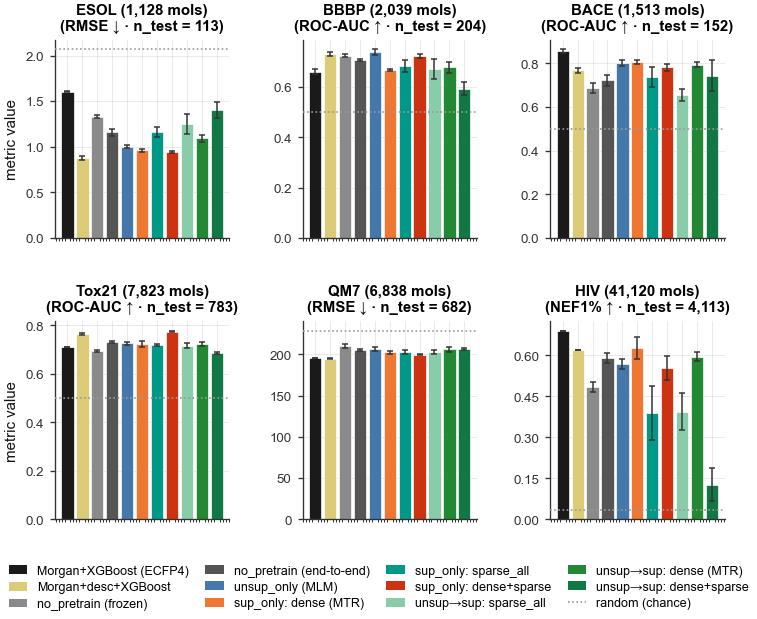


A1.a mean lift over no_pretrain at 8M (tasks scored / 6):
   Morgan+XGBoost (ECFP4)           +7.9%   (n=6)
   Morgan+desc+XGBoost             +15.3%   (n=6)
   no_pretrain (frozen)             +0.0%   (n=6)
   no_pretrain (end-to-end)         +7.6%   (n=6)
   unsup_only (MLM)                +11.2%   (n=6)
   sup_only: dense (MTR)           +12.3%   (n=6)
   sup_only: sparse_all             +0.3%   (n=6)
   sup_only: dense+sparse          +12.3%   (n=6)
   unsup→sup: sparse_all            -2.9%   (n=6)
   unsup→sup: dense (MTR)           +9.4%   (n=6)
   unsup→sup: dense+sparse         -14.8%   (n=6)


saved figA1b_best_model_headline_cv


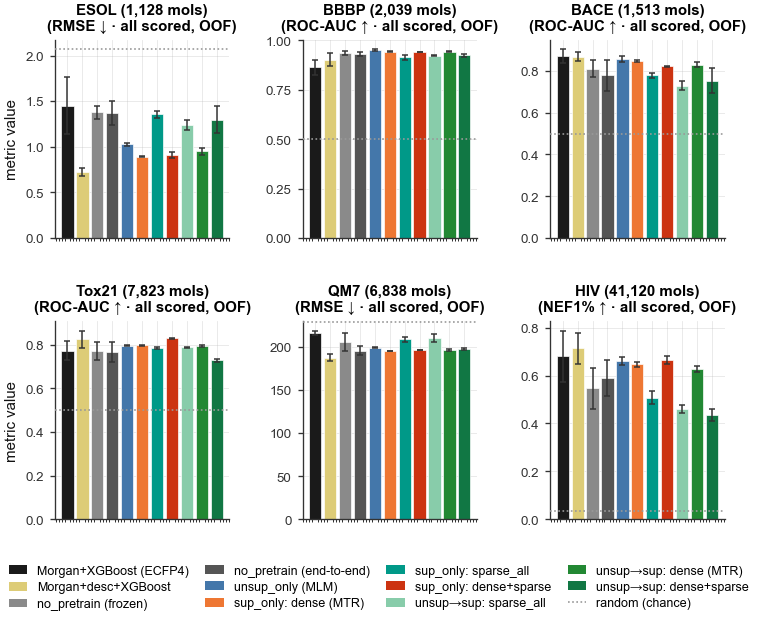


A1.b mean lift over no_pretrain at 8M (tasks scored / 6):
   Morgan+XGBoost (ECFP4)           +2.3%   (n=6)
   Morgan+desc+XGBoost             +16.2%   (n=6)
   no_pretrain (frozen)             +0.0%   (n=6)
   no_pretrain (end-to-end)         +1.4%   (n=6)
   unsup_only (MLM)                +10.1%   (n=6)
   sup_only: dense (MTR)           +11.2%   (n=6)
   sup_only: sparse_all             -1.9%   (n=6)
   sup_only: dense+sparse          +11.6%   (n=6)
   unsup→sup: sparse_all            -2.8%   (n=6)
   unsup→sup: dense (MTR)           +9.5%   (n=6)
   unsup→sup: dense+sparse          -4.0%   (n=6)


In [5]:
# ---------- A1 · headline bars at the matched budget, drawn on BOTH evaluation schemes ----------
# A1.a = single DeepChem scaffold hold-out (rarest scaffolds in test, 113-204 molecules on the
#        small tasks). A1.b = pooled 5-fold scaffold CV (README §8.1's protocol of record;
#        10-35x the test molecules, so it is the one that can actually separate arms).
# Same arms, same order, same colours in both panels so they are read side by side.
import textwrap as _tw          # module scope: later figures (E1) reuse this alias
A1_ORDER = ["ecfp4", "fp_desc", "no_pretrain", "no_pretrain_e2e", "unsup_only",
            "sup_only:dense", "sup_only:sparse_all", "sup_only:dense_plus_sparse",
            "unsup2sup:sparse_all", "unsup2sup:dense", "unsup2sup:dense_plus_sparse"]
# `minimol_full` and `mixed` are deliberately absent from the BARS (11 is already crowded); both
# recipes are still reported for both regimes in Table A1 below, which covers all five.

def a1_title(task, sub):
    """`ESOL (1,128 mols)` over `(RMSE ↓ · n_test = 113)` -- the second number is the whole point
    of splitting A1 into a/b, so it belongs in the panel, not only in the caption."""
    tot, n = n_molecules(task, "moleculenet_cv"), n_molecules(task, sub)
    head = f'{TASKS[task]["pretty"]} ({tot:,} mols)' if np.isfinite(tot) else TASKS[task]["pretty"]
    if not np.isfinite(n):        tail = mlabel(task)
    elif n == tot:                tail = f'{mlabel(task)} · all scored, OOF'   # CV: no held-out remainder
    else:                         tail = f'{mlabel(task)} · n_test = {n:,}'
    return f"{head}\n({tail})"

def draw_A1(df, sub, tag, scheme_note, err_note, fname):
    ncol = 3; nrow = int(np.ceil(len(CORE_TASKS) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(STYLE["col2"], 2.35 * nrow)); axes = axes.ravel()
    for ax, task in zip(axes, CORE_TASKS):
        vals = [arm_value(df, task, k) for k in A1_ORDER]
        errs = [arm_err(df, task, k)   for k in A1_ORDER]
        x = np.arange(len(A1_ORDER))
        for xi, k, v, e in zip(x, A1_ORDER, vals, errs):
            if not np.isfinite(v): continue
            ax.bar(xi, v, color=rc_color(k), edgecolor="white", lw=0.4, width=0.82,
                   yerr=(e if np.isfinite(e) else None),
                   error_kw=dict(ecolor="#333333", elinewidth=0.9, capsize=2, capthick=0.9))
        # A missing bar simply vanishes, which a reader cannot tell from a zero-height bar. Name them.
        pending = [rc_label(k) for k, v in zip(A1_ORDER, vals) if not np.isfinite(v)]
        if pending:
            ax.set_ylim(top=ax.get_ylim()[1] * (1.10 + 0.09 * int(np.ceil(len(pending) / 2))))
            ax.text(0.02, 0.985, "pending:\n" + "\n".join(pending), transform=ax.transAxes,
                    ha="left", va="top", fontsize=STYLE["fs_annot"] - 1.5, color="#B00020",
                    linespacing=1.25, bbox=dict(fc="white", ec="none", alpha=0.85, pad=1.0))
        add_chance_line(ax, task)
        ax.set_title(a1_title(task, sub), pad=6); ax.set_xticks(x); ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0); ax.margins(x=0.04); label_all_yticks(ax)
    for ax in axes[len(CORE_TASKS):]: ax.axis("off")
    for i in range(0, len(CORE_TASKS), ncol): axes[i].set_ylabel("metric value")

    handles = [mpl.patches.Patch(facecolor=rc_color(k), label=rc_label(k)) for k in A1_ORDER]
    handles += [plt.Line2D([], [], color="#999999", ls=(0, (1, 1.5)), lw=1.0, label="random (chance)")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.05), ncol=4,
               fontsize=STYLE["fs_legend"], handlelength=1.5, columnspacing=1.3)

    # replication note; the count of replicated arms is read from the data so it cannot go stale
    _multi = sum(1 for k in A1_ORDER if n_seeds(df, "ESOL", k) > 1)
    _note = (f"{scheme_note}  ·  {err_note}"
             + (f" ({_multi} arms have pretraining-seed replicates)" if _multi else "")
             + "  ·  classical anchors: 3 XGBoost seeds  ·  no_pretrain (frozen) = random-init "
               "encoder, features frozen; no_pretrain (end-to-end) = same encoder fine-tuned on the task")
    _suptitle(fig, f"Fig {tag} - which model performs best? (matched at {MATCHED_BUDGET} forward passes)",
                 fontsize=STYLE["fs_title"], y=1.10)
    _caption(fig, 0.5, 0.995, "\n".join(_tw.wrap(_note, 125)), ha="center", va="top",
             fontsize=STYLE["fs_annot"] - 0.5, color="#666")
    fig.subplots_adjust(top=0.96, bottom=0.11, hspace=0.42, wspace=0.42)
    save_fig(fig, fname); plt.show()

    print(f"\n{tag} mean lift over no_pretrain at {MATCHED_BUDGET} (tasks scored / {len(CORE_TASKS)}):")
    for k in A1_ORDER:
        ls = [lift(arm_value(df, t, k), t, npt_floor(df, t)) for t in CORE_TASKS]
        ls = [v for v in ls if np.isfinite(v)]
        if ls: print(f"   {rc_label(k):<30} {100*np.mean(ls):+6.1f}%   (n={len(ls)})")

draw_A1(DF,    "moleculenet",    "A1.a", "single DeepChem scaffold hold-out (rarest scaffolds in test; 113-204 "
                        "test molecules on ESOL/BACE/BBBP)",
        "error bars = ±1 sd over pretraining seeds where replicates exist, else over head seeds",
        "figA1a_best_model_headline_holdout")
draw_A1(DF_CV, "moleculenet_cv", "A1.b", "pooled 5-fold scaffold cross-validation (README §8.1 protocol of record)",
        "error bars = ±1 sd across the 5 scaffold folds",
        "figA1b_best_model_headline_cv")

### Table A1 · who wins, how often, and at what data cost

A per-arm summary of Fig A1, for the paper's LaTeX table. **"Best" on a task** = the arm with the
leading point estimate, *plus* every arm that is not **statistically distinguishable** from it under
the §8.1 test of record (molecule-paired Wilcoxon on squared error for RMSE tasks, DeLong paired-AUC
for classification and for HIV). A task can therefore have several co-winners; a task where nothing
separates gives everyone a win, which is itself the finding.

Two versions are printed, because they answer the question at very different resolutions:

| version | evaluation | why |
|---|---|---|
| **A1.a — single scaffold hold-out** | exactly the numbers Fig A1.a plots | matches the figure — but the test split is only **113–204 molecules** on ESOL/BACE/BBBP, so almost nothing is significant and 10–13 of 14 arms tie on most tasks |
| **A1.b — pooled 5-fold scaffold-CV OOF** | §8.1's test of record, every molecule predicted out-of-fold | ~10–35× the test molecules → it actually resolves the arms. **Use this one for the paper table.** |

Two more columns beyond the raw win count:
- **CLIMB-only** — the same win count recomputed with both XGBoost anchors removed, i.e. which
  *encoder* is best if the classical baselines are not in the room. `no_pretrain` stays in: it is a
  real ~41 M ModernBERT, not a classical baseline.
- **beats `no_pretrain`** — how often the arm is *significantly better* (same test, p < 0.05, and in
  the right direction) than the random-init frozen encoder. This is the "did any pretraining buy
  anything at all?" column.

Caveats stated in the output rather than hidden: arms with pretraining-seed replicates are *ranked*
by their seed-mean (the Fig A1 bar height) but *tested* with the seed-0 run's predictions, since the
paired test needs one prediction vector; and `n` differs per arm where a task has not been scored yet.

Unlike the bars, the table carries **every** arm: all five SFT recipes for both `sup_only` and
`unsup→sup`, plus both XGBoost anchors and both `no_pretrain` variants. (Before this rewrite Fig A1
drew a *single* `unsup→sup` bar that silently averaged all five recipes while `sup_only` got five
separate bars — the two regimes are now compared like for like.)

The `no_pretrain (end-to-end)` row reads `n.d.` until the E1 re-run lands in
`figure_data/climb_v2_phase2/e2e_random_0*`; it then populates automatically, no hand-editing.

In [6]:
# ---------- Table A1 · win counts + data cost (plain text; copy the numbers by hand) ----------
# ONE significance test throughout (README §8.1): a scaffold cluster-bootstrap of the paired metric
# difference, BH-FDR-corrected across the comparison family, PRECOMPUTED by
# scripts/best_model_bootstrap.py -> analysis/rigor/best_model_bootstrap.csv (too slow to run inline:
# HIV=41k molecules x ~15 arms x 2 schemes x 1,000 resamples). Definitions:
#   * A1.b (CV, test of record): an arm is "not distinguishable from the leader" when the
#     leader-minus-arm difference is NOT significant at BH-FDR q>=0.05 (leader trivially included);
#     "beats no_pretrain" = q<0.05 in the arm's favour.
#   * A1.a (hold-out): the rarest-scaffold split (113-4,112 test molecules, few scaffolds) is
#     underpowered and is NOT used to rank models -- each arm is reported as its point estimate with
#     a cluster-bootstrap 95% CI. The old 1-sigma hold-out rule is dropped (permissiveness hack).
#   * matrix (6 headline models): same test, FDR within that pre-specified set, on BOTH schemes.
# Unlike the bars, this table keeps ALL FIVE SFT recipes for both sup_only and unsup->sup.
# Corpus sizes, family caps and the unique-molecule arithmetic live in the shared helpers cell so
# this table and Fig A2.b quote the same numbers by construction.

# ---- the arms: every model, in the A1 bar order, then the two recipes the bars omit -----------
_B = BUDGET_FP[MATCHED_BUDGET]
ARMS = {"ecfp4":           dict(label="Morgan+XGBoost (ECFP4)", runs=["ecfp4_anchor"],
                                unsup=0, dense=0, assay=0),
        "fp_desc":         dict(label="Morgan+desc+XGBoost", runs=["fp_desc_anchor"],
                                unsup=0, dense=0, assay=0),
        "no_pretrain":     dict(label="no_pretrain (frozen)", unsup=0, dense=0, assay=0,
                                runs=["random_baseline_00", "random_baseline_01", "random_baseline_02"]),
        # E1 re-run under the A1 protocol; the dirs appear once those jobs land, and every number
        # in this row switches from n.d. to real on the next notebook run. No hand-editing.
        "no_pretrain_e2e": dict(label="no_pretrain (end-to-end)", unsup=0, dense=0, assay=0,
                                runs=["e2e_random_00", "e2e_random_01", "e2e_random_02"]),
        "unsup_only":      dict(label="unsup_only (MLM)", unsup=unique_molecules("unsup_only", _B, MATCHED_BUDGET), dense=0, assay=0,
                                runs=["unsup_8M", "unsup_8M_s1", "unsup_8M_s2"])}
for _r in sup_recipes:
    _d, _a = sft_molecules(_r, _B)
    ARMS[f"sup_only:{_r}"] = dict(label=f"sup_only: {_recipe_pretty[_r]}", unsup=0, dense=_d, assay=_a,
                                  runs=[f"skip_{_r}_8M", f"skip_{_r}_8M_s1", f"skip_{_r}_8M_s2"])
for _r in sup_recipes:
    _d, _a = sft_molecules(_r, U2S_SFT_FP)
    ARMS[f"unsup2sup:{_r}"] = dict(label=f"unsup→sup: {_recipe_pretty[_r]}",
                                   unsup=unique_molecules("unsup_only", _B, MATCHED_BUDGET), dense=_d, assay=_a,
                                   runs=[f"u2s_{_r}_from{MATCHED_BUDGET}",
                                         f"u2s_{_r}_from{MATCHED_BUDGET}_s1",
                                         f"u2s_{_r}_from{MATCHED_BUDGET}_s2"])
for _k, _v in ARMS.items():
    _v["runs"] = [r for r in _v["runs"] if (DATA_ROOT / "climb_v2_phase2" / r).exists()]

# ---- data access + the paired tests ---------------------------------------------------------
_TBL_CACHE = {}
def _tbl_suite(run, task, sub):
    p = DATA_ROOT / "climb_v2_phase2" / run / sub / "suite_summary.json"
    if not p.exists(): return np.nan
    return json.loads(p.read_text()).get(TASKS[task].get("suite_key", task) + "_MEAN", np.nan)

def _tbl_point(arm, task, sub):
    """Ranking value = mean over pretraining seeds, i.e. the Fig A1 bar height."""
    v = [x for x in (_tbl_suite(r, task, sub) for r in ARMS[arm]["runs"]) if np.isfinite(x)]
    return float(np.mean(v)) if v else np.nan

def _tbl_preds(arm, task, sub):
    """Per-molecule predictions of the PRIMARY (seed-0) run -- the paired test needs one vector."""
    if not ARMS[arm]["runs"]: return None
    key = (ARMS[arm]["runs"][0], task, sub)
    if key not in _TBL_CACHE:
        p = DATA_ROOT / "climb_v2_phase2" / key[0] / sub / "test_predictions.csv"
        if not p.exists():
            _TBL_CACHE[key] = None
        else:
            d = pd.read_csv(p)
            d = d[d.dataset == task].drop_duplicates(["mol_index", "output_index"])
            _TBL_CACHE[key] = d if len(d) else None
    return _TBL_CACHE[key]

def _scored(arm, task, sub):
    """An arm 'ran' on (task, sub) if it has a suite mean -- cheap coverage check for the data-cost rows."""
    return np.isfinite(_tbl_point(arm, task, sub))

# ---- 'best' = scaffold cluster-bootstrap + BH-FDR, read from the precomputed analysis --------
# (scripts/best_model_bootstrap.py). One test everywhere; co-best = leader-minus-arm NOT significant
# at BH-FDR q>=0.05. The hold-out is NOT ranked (underpowered) -> point estimate + CI instead.
_BMB = pd.read_csv("analysis/rigor/best_model_bootstrap.csv")
def _bmb(family, scheme, task):
    return _BMB[(_BMB.family == family) & (_BMB.scheme == scheme) & (_BMB.task == task)]
def _cobest(task, family="full", scheme="cv"):
    """(set of arms not distinguishable from the leader at FDR, leader arm key) for one task."""
    d = _bmb(family, scheme, task)
    lead = d.loc[d.is_leader, "arm"].iloc[0] if d.is_leader.any() else None
    return set(d.loc[d.cobest.fillna(False), "arm"]), lead
def _beats(task, arm, col):     # col in {"beats_frozen", "beats_e2e"}
    r = _bmb("full", "cv", task); r = r[r.arm == arm]
    return bool(r[col].iloc[0]) if len(r) and pd.notna(r[col].iloc[0]) else False
def _hold_est(task, arm):       # (point, ci_lo, ci_hi): hold-out estimate + cluster-bootstrap 95% CI
    r = _bmb("full", "holdout", task); r = r[r.arm == arm]
    if not len(r): return (np.nan, np.nan, np.nan)
    return (float(r.point.iloc[0]), float(r.ci_lo.iloc[0]), float(r.ci_hi.iloc[0]))

# ---- assemble ------------------------------------------------------------------------------
def _fmt_mol(n):
    if n is None or n == 0: return "0"
    return f"{n/1e6:.2f} M" if n >= 1e6 else f"{n/1e3:.1f} k"

def a1_summary_cv():
    """A1.b (CV) ranking table. 'co-best' = not distinguishable from the per-task leader at BH-FDR
    q>=0.05 (cluster bootstrap); 'beats no_pretrain' = q<0.05 in the arm's favour. All from the CSV."""
    active = [a for a in ARMS if any(_scored(a, t, "moleculenet_cv") for t in CORE_TASKS)]
    climb  = [a for a in active if a not in ("ecfp4", "fp_desc")]   # drop only the XGBoost anchors
    scored_tasks = [t for t in CORE_TASKS if all(_scored(a, t, "moleculenet_cv") for a in active)]
    BEATS = {"beats no_pretrain (frozen)": ("no_pretrain", "beats_frozen"),
             "beats no_pretrain (e2e)":    ("no_pretrain_e2e", "beats_e2e")}
    win = {a: 0 for a in active}; cwin = {a: 0 for a in climb}
    bnp = {lab: {a: 0 for a in active} for lab in BEATS}
    per_task, missing = [], []
    for t in CORE_TASKS:
        wa, la = _cobest(t, "full", "cv")
        wc, lc = _cobest(t, "climb", "cv")
        per_task.append(dict(task=t, leader=ARMS[la]["label"] if la in ARMS else "n.d.", n_cobest=len(wa),
                             climb_leader=ARMS[lc]["label"] if lc in ARMS else "n.d.",
                             arms_scored=f"{len([a for a in active if _scored(a, t, 'moleculenet_cv')])}/{len(active)}",
                             counted="yes" if t in scored_tasks else "NO - incomplete"))
        missing += [(ARMS[a]["label"], t) for a in active if not _scored(a, t, "moleculenet_cv")]
        if t not in scored_tasks: continue
        for a in active:
            win[a] += int(a in wa)
            if a in cwin: cwin[a] += int(a in wc)
            for _lab, (_base, _col) in BEATS.items():
                if a == _base or _base not in active: continue
                bnp[_lab][a] += int(_beats(t, a, _col))
    N = len(scored_tasks)
    def cell(x, a, pool):
        return f"{x[a]}/{N}" if a in pool else "n.d."
    rows = []
    for a, v in ARMS.items():
        row = {"model": v["label"], "unsup mols": _fmt_mol(v["unsup"]),
               "sup mols (desc)": _fmt_mol(v["dense"]), "sup mols (assay)": _fmt_mol(v["assay"]),
               "co-best x/n": cell(win, a, active),
               "CLIMB-only x/n": (cell(cwin, a, climb) if a in climb else
                                  ("n/a" if a in active else "n.d."))}
        for _lab, (_base, _col) in BEATS.items():
            row[_lab] = ("--" if a == _base else
                         (cell(bnp[_lab], a, active) if _base in active else "n.d."))
        rows.append(row)
    return pd.DataFrame(rows), pd.DataFrame(per_task), missing, scored_tasks

def a1_a_estimates():
    """A1.a (hold-out): NOT ranked -- point estimate with a 95% scaffold cluster-bootstrap CI per
    arm x task (the adversarial rarest-scaffold split is underpowered; the CV carries the rankings)."""
    rows = []
    for a, v in ARMS.items():
        row = {"model": v["label"]}
        for t in CORE_TASKS:
            pt, lo, hi = _hold_est(t, a)
            row[t] = f"{pt:.3g} [{lo:.3g}, {hi:.3g}]" if np.isfinite(pt) else "n.d."
        rows.append(row)
    return pd.DataFrame(rows)

# ---- A1.b (CV) = the ranking table of record; A1.a (hold-out) = estimates + CI, NOT ranked --------
_cv_summary, _cv_pt, _cv_missing, _cv_st = a1_summary_cv()
print("=" * 112)
print("Table A1.b -- pooled 5-fold scaffold-CV OOF -- test of record  <<< USE THIS ONE for rankings")
print("=" * 112)
print("molecules scored / dataset size per task:",
      ", ".join(f"{t}={n_molecules(t,'moleculenet_cv'):,}/{n_molecules(t):,}" for t in CORE_TASKS))
print(_cv_pt.to_string(index=False))
print(f"\nco-best counts over the {len(_cv_st)} task(s) with complete arm coverage: {', '.join(_cv_st)}"
      + (f"   |  EXCLUDED: {', '.join(t for t in CORE_TASKS if t not in _cv_st)}"
         if len(_cv_st) < len(CORE_TASKS) else ""))
print(); print(_cv_summary.to_string(index=False)); print()
if _cv_missing:
    print(f"unscored arm x task cells ({len(_cv_missing)}): "
          + ", ".join(f"{a}/{t}" for a, t in _cv_missing[:12]) + (" ..." if len(_cv_missing) > 12 else ""))

print("\n" + "=" * 112)
print("Table A1.a -- single scaffold hold-out -- point estimate [95% cluster-bootstrap CI], NOT ranked")
print("=" * 112)
print(a1_a_estimates().to_string(index=False)); print()

print("-" * 112)
print("ONE test throughout (scripts/best_model_bootstrap.py, scaffold cluster-bootstrap, n_boot=1000,\n"
      "BH-FDR across the arm x task family). 'co-best x/n' = tasks where the arm is NOT distinguishable\n"
      "from the per-task leader at q>=0.05 (leader included). 'beats no_pretrain' = q<0.05 in the arm's\n"
      "favour vs the frozen / end-to-end random baseline. 'CLIMB-only x/n' = the same, judged among the\n"
      "CLIMB arms only (anchors dropped). A1.a (hold-out) is NOT ranked: the rarest-scaffold split\n"
      "(113-4,112 test molecules, few scaffolds) is underpowered, so each arm is a point estimate with a\n"
      "95% cluster-bootstrap CI. HIV metric = NEF1%. Tox21 = mean over its 12 label columns.\n"
      "'sup mols (desc)' = PubChem molecules with computed RDKit-descriptor (MTR) labels; 'sup mols\n"
      "(assay)' capped by config_v2.SUPERVISED_FAMILY_CAPS (8M-FP sparse arms ~15 epochs over ~0.5M mols).")
print("-" * 112)

# ---- best-model matrix (6 headline models): same test, FDR within this pre-specified set, both schemes ----
MATRIX_MODELS = [("fp_desc", "Morgan+desc+XGBoost"), ("ecfp4", "Morgan+XGBoost (ECFP4)"),
                 ("unsup_only", "unsup_only (MLM)"), ("sup_only:dense_plus_sparse", "sup_only: dense+sparse"),
                 ("sup_only:mixed", "sup_only: mixed"), ("no_pretrain_e2e", "no_pretrain (end-to-end)")]
_cvb = {t: _cobest(t, "matrix", "cv")[0] for t in CORE_TASKS}
_hob = {t: _cobest(t, "matrix", "holdout")[0] for t in CORE_TASKS}
print("\nBest-model matrix (cluster-bootstrap + FDR within the 6-model set). cell = [CV][hold-out], "
      "# = co-best, . = distinguishable:")
print("model".ljust(26) + "".join(f"{t:>9}" for t in CORE_TASKS))
for _k, _lab in MATRIX_MODELS:
    _row = "".join(f"{('#' if _k in _cvb[t] else '.')+('#' if _k in _hob[t] else '.'):>9}" for t in CORE_TASKS)
    print(_lab.ljust(26) + _row)

if len(_cv_st) == len(CORE_TASKS):
    print(f"\nTable A1.b: COMPLETE -- all {len(CORE_TASKS)} tasks have every arm scored.")
else:
    print(f"\nTable A1.b: INCOMPLETE -- only {len(_cv_st)}/{len(CORE_TASKS)} tasks fully scored "
          f"({', '.join(_cv_st) or 'none'}); re-run once the scoring pass lands.")

Table A1.b -- pooled 5-fold scaffold-CV OOF -- test of record  <<< USE THIS ONE for rankings
molecules scored / dataset size per task: ESOL=1,128/1,128, BBBP=2,039/2,039, BACE=1,513/1,513, Tox21=7,823/7,823, QM7=6,838/6,838, HIV=41,120/41,120
 task                 leader  n_cobest           climb_leader arms_scored counted
 ESOL    Morgan+desc+XGBoost         1        sup_only: mixed       15/15     yes
 BBBP       unsup_only (MLM)         2       unsup_only (MLM)       15/15     yes
 BACE Morgan+XGBoost (ECFP4)         3       unsup_only (MLM)       15/15     yes
Tox21 sup_only: dense+sparse         2 sup_only: dense+sparse       15/15     yes
  QM7    Morgan+desc+XGBoost         1  sup_only: dense (MTR)       15/15     yes
  HIV    Morgan+desc+XGBoost         6 sup_only: dense+sparse       15/15     yes

co-best counts over the 6 task(s) with complete arm coverage: ESOL, BBBP, BACE, Tox21, QM7, HIV

                   model unsup mols sup mols (desc) sup mols (assay) co-best x/n CLIM

## A2 · How does pretraining scale in forward passes?

Ladders for the primary regimes against the `no_pretrain` floor. `unsup→sup` is drawn at its
**true** total compute (MLM base + 2 M-FP SFT stage), so the arm is not flattered by hiding its
extra spend.

The shaded band on the right marks the **larger unsupervised runs still to come** (96 M FP, and a
corpus scaled toward ~100 M unique molecules). It contains no data — it is there so the reader can
see where the ladder is about to be extended rather than assuming it ends at 48 M.

saved figA2a_scaling_tokens


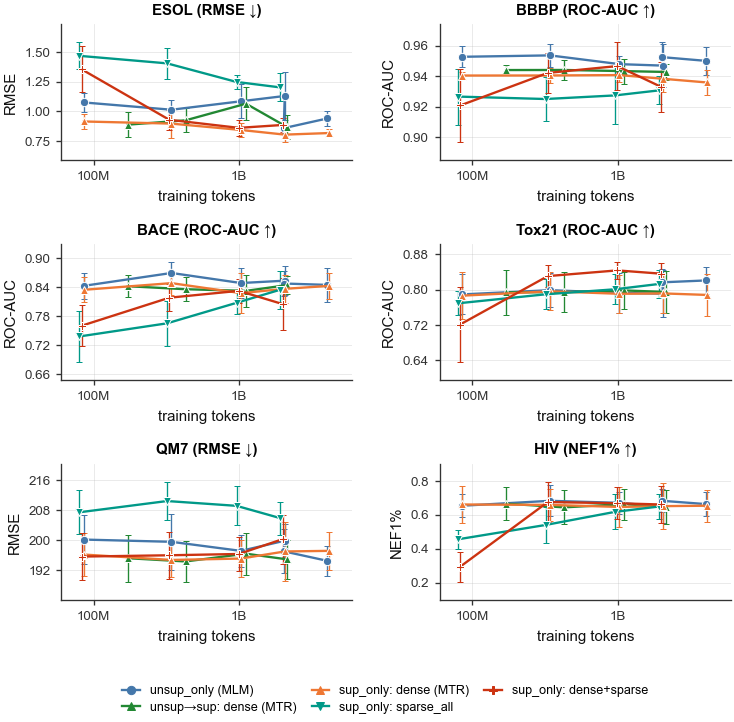

saved figA2b_scaling_unique_molecules


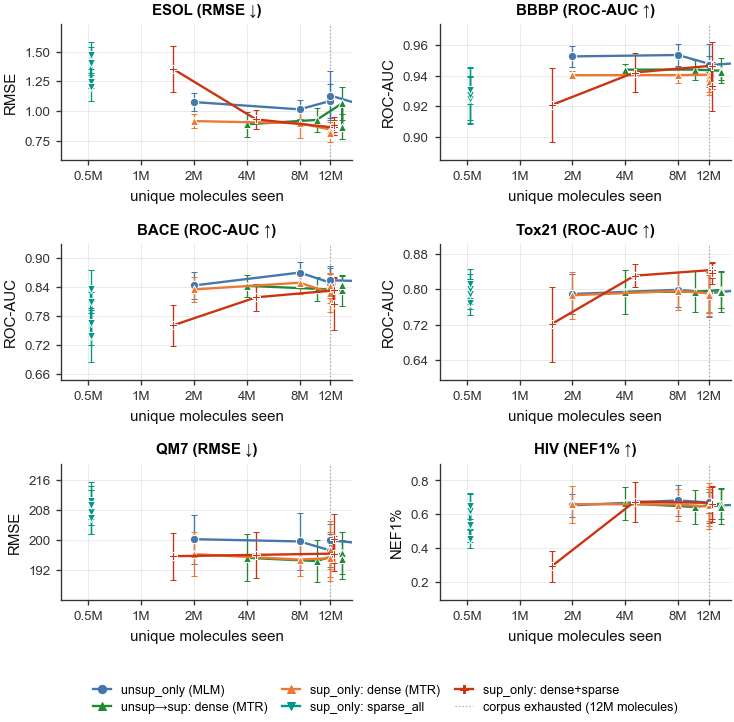


A2 change from the smallest to the largest CV-scored rung (per arm, mean over tasks):


   unsup_only (MLM)                 +3.5%   (n=6 tasks)
   unsup→sup: dense (MTR)           -0.0%   (n=6 tasks)
   sup_only: dense (MTR)            +1.6%   (n=6 tasks)
   sup_only: sparse_all            +13.4%   (n=6 tasks)
   sup_only: dense+sparse          +30.0%   (n=6 tasks)

unique molecules behind each rung (why A2.b differs from A2.a):
   unsup_only (MLM)               2M FP→2.00M mol  8M FP→8.00M mol  24M FP→12.00M mol  48M FP→12.00M mol  50M FP→50.00M mol  100M FP→100.00M mol
   unsup→sup: dense (MTR)         4M FP→4.00M mol  10M FP→10.00M mol  26M FP→14.00M mol  50M FP→14.00M mol
   sup_only: dense (MTR)          2M FP→2.00M mol  8M FP→8.00M mol  24M FP→12.00M mol  48M FP→12.00M mol  96M FP→12.00M mol
   sup_only: sparse_all           2M FP→0.52M mol  8M FP→0.52M mol  24M FP→0.52M mol  48M FP→0.52M mol
   sup_only: dense+sparse         2M FP→1.52M mol  8M FP→4.52M mol  24M FP→12.52M mol  48M FP→12.52M mol


In [7]:
# ---------- A2 · scaling ladders, on the 5-fold CV only, on BOTH scaling axes ----------
# A2.a x = forward passes (compute). A2.b x = UNIQUE MOLECULES actually seen. They are the same
# runs and the same y-values; only the x-coordinate changes -- and the two tell different stories,
# because past one epoch of a stream extra forward passes buy no new molecules. The sparse SFT
# recipes exhaust their capped pool at ~0.52M molecules, so in A2.b their ladders go VERTICAL:
# every rung above 2M FP is pure repetition. That is invisible on the compute axis.
#
# EVERY error bar here is the SAME quantity: the spread across the 5 scaffold folds. The single
# hold-out is not used and pretraining-seed replicates are deliberately ignored, because those
# replicates exist only at the 8M rung -- mixing them in would make the 8M interval mean something
# different from every other point on the same line.
A2_KEYS = ["unsup_only", "unsup2sup:dense",
           "sup_only:dense", "sup_only:sparse_all", "sup_only:dense_plus_sparse"]
# No horizontal reference lines at all. This panel carried up to four of them (two XGBoost
# anchors plus two no_pretrain references); with five coloured ladders on top the greys stopped
# functioning as reference and became clutter. The classical baselines are bars in A1.a/A1.b,
# where they can be read against every arm at once, which is what they are for.

def ladder_cv(task, key):
    """CV mean + across-fold sd per budget, seed-0 runs only. Empty frame if nothing is scored."""
    d = DF_CV[(DF_CV.wave == "climb_v2_phase2") & (DF_CV.task == task) & (DF_CV.seed == 0)]
    if key == "unsup_only":            s = d[d.regime == "unsup_only"]
    elif key.startswith("unsup2sup:"): s = d[(d.regime == "unsup2sup") & (d.recipe == key.split(":")[1])]
    else:                              s = d[(d.regime == "sup_only") & (d.recipe == key.split(":")[1])]
    s = s[~s.truncated]
    if not len(s): return s
    g = (s.groupby(["budget_fp", "budget_label"])
           .agg(value=("value", "mean"), err=("std", "mean"), tok=("tokens_seen", "mean"))
           .reset_index().sort_values("budget_fp"))
    g["mols"] = [unique_molecules(key, b, l) for b, l in zip(g.budget_fp, g.budget_label)]
    # unsup->sup is a warm-start: its metrics.jsonl logs only the SFT stage, so add the MLM base's
    # tokens (same logic as its FP budget, base_FP + 2M SFT). Base label is the "from{B}" budget.
    if key.startswith("unsup2sup:"):
        base_tok = {r.budget_label: r.tokens_seen for r in
                    DF_CV[(DF_CV.regime == "unsup_only") & (DF_CV.seed == 0)]
                    .drop_duplicates("budget_label").itertuples()}
        g["tok"] = [t + base_tok.get(l, 0.0) for t, l in zip(g.tok, g.budget_label)]
    return g

def anchor_cv(task, key):
    """(mean, across-fold sd) for a compute-independent reference, or (nan, nan)."""
    s = DF_CV[(DF_CV.wave == "climb_v2_phase2") & (DF_CV.task == task) & (DF_CV.regime == key)]
    return (float(s.value.mean()), float(s["std"].mean())) if len(s) else (np.nan, np.nan)

# Rungs that exist in the CV eval. 96M was scored on the hold-out only, and unsup->sup has no 48M
# CV run, so both are absent here rather than silently interpolated. Stated in the caption.
# 50M/100M appear only once those runs land; listing them early would draw empty tick labels.
BUDG = [2e6, 8e6, 24e6, 48e6] + [b for b in (50e6, 100e6)
        if len(DF_CV[(DF_CV.regime == "unsup_only") & (DF_CV.budget_fp == b)])]
N_RUNGS = len(BUDG)
# Y-axis: each panel is zoomed TIGHT to its OWN data, with a consistent fractional margin
# (A2_YMARGIN) on each side; AUC panels are hard-capped at 1.0 because values above it are
# meaningless. One shared HEIGHT per metric family was tried first, but a near-ceiling,
# low-variance task (BBBP, range ~0.065) then took a window ~3x its data that spilled past
# AUC=1.0 and read as mostly-empty. Per-panel zoom keeps every task legible; the trade is that a
# given vertical rise no longer means the same delta across tasks, so slopes are compared WITHIN a
# panel, not between panels (the caption says so).
A2_YMARGIN = 0.18

def draw_A2(xcol, tag, xlabel, extra_note, fname):
    ncol = 2; nrow = int(np.ceil(len(CORE_TASKS) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(STYLE["col2"], 2.05 * nrow)); axes = axes.ravel()
    # --- data range per task (value +/- fold sd); each panel is zoomed to its own range below ---
    _rng = {}
    for task in CORE_TASKS:
        vs = []
        for key in A2_KEYS:
            gg = ladder_cv(task, key)
            if len(gg):
                e = gg.err.fillna(0.0)
                vs += list(gg.value - e) + list(gg.value + e)
        if vs: _rng[task] = (min(vs), max(vs))
    for i, (ax, task) in enumerate(zip(axes, CORE_TASKS)):
        drew = False; gaps = []
        for key in A2_KEYS:
            g = ladder_cv(task, key)
            if not len(g):
                gaps.append(f"{rc_label(key)}: no CV data"); continue
            drew = True
            ax.errorbar(g[xcol], g.value, yerr=g.err, color=rc_color(key), ls=rc_ls(key),
                        lw=STYLE["lw"], marker=rc_marker(key), ms=STYLE["marker_size"], mec="white",
                        capsize=2, elinewidth=0.8, zorder=3)
        if xcol == "tok":
            ax.set_xscale("log")
            ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=12))
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(
                lambda v, _: f"{v/1e9:g}B" if v >= 1e9 else f"{v/1e6:g}M"))
            ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x", which="minor", bottom=False)
            ax.set_xlim(6e7, 6e9)
        elif xcol == "budget_fp":
            set_fp_axis(ax, BUDG); ax.set_xlim(1.6e6, 6.0e7)
        else:
            ax.set_xscale("log"); ax.set_xlim(3.5e5, 1.6e7)
            ax.xaxis.set_major_locator(ticker.FixedLocator([5e5, 1e6, 2e6, 4e6, 8e6, 12e6]))
            ax.xaxis.set_major_formatter(ticker.FixedFormatter(
                ["0.5M", "1M", "2M", "4M", "8M", "12M"]))
            ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x", which="minor", bottom=False)
            # the corpus is only ~12M molecules, so this is where the unsupervised axis simply stops
            ax.axvline(UNSUP_CORPUS, color="#999", ls=(0, (1, 2)), lw=0.7, zorder=1)
        ax.set_title(ttitle(task, oneline=True), pad=6); ax.set_xlabel(xlabel)
        ax.set_ylabel(re.sub(r"\s*[↑↓]\s*$", "", mlabel(task)))   # arrow lives in the title
        if task in _rng:                       # tight per-panel zoom, consistent fractional margin
            lo, hi = _rng[task]; pad = A2_YMARGIN * max(hi - lo, 1e-6)
            y0, y1 = lo - pad, hi + pad
            if "AUC" in TASKS[task]["metric"]: y1 = min(y1, 1.0)   # AUC ceiling; nothing above it
            ax.set_ylim(y0, y1)
        label_all_yticks(ax)
        if not drew: no_data_watermark(ax, "no CV-scored runs")
    for ax in axes[len(CORE_TASKS):]: ax.axis("off")

    handles = [plt.Line2D([], [], color=rc_color(k), marker=rc_marker(k), ls=rc_ls(k), label=rc_label(k))
               for k in A2_KEYS]
    if xcol == "mols":
        handles += [plt.Line2D([], [], color="#999", ls=(0, (1, 2)), lw=0.7,
                               label="corpus exhausted (12M molecules)")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=3,
               fontsize=STYLE["fs_legend"], columnspacing=1.2)
    _suptitle(fig, f"Fig {tag} - scaling of the primary regimes in {xlabel}",
                 fontsize=STYLE["fs_title"], y=1.075)
    note = ("pooled 5-fold scaffold CV  ·  error bars = ±1 sd across the 5 folds (no head-seed, no "
            "pretraining-seed spread), so every interval means the same thing  ·  each panel is "
            "zoomed to its own y-range (AUC capped at 1.0), so compare slopes WITHIN a panel, not "
            "between panels  ·  the classical anchors and no_pretrain baselines are omitted for "
            "legibility — they are bars in A1.a/A1.b  ·  "
            + extra_note)
    _caption(fig, 0.5, 0.995, "\n".join(_tw.wrap(note, 120)), ha="center", va="top",
             fontsize=STYLE["fs_annot"] - 0.5, color="#666")
    fig.subplots_adjust(top=0.88, bottom=0.10, hspace=0.62, wspace=0.30)
    save_fig(fig, fname); plt.show()

draw_A2("tok", "A2.a", "training tokens",
        "x = tokens actually processed (trainer's own non-padding count from metrics.jsonl, per "
        "run — NOT forward passes × a constant; that ratio varies 40.0–42.9 tok/seq across "
        "corpora)  ·  unsup→sup = MLM-base tokens + SFT tokens",
        "figA2a_scaling_tokens")
draw_A2("mols", "A2.b", "unique molecules seen",
        "x = unique molecules, so a ladder that runs VERTICAL is spending compute on repetition, "
        "not on new chemistry; the sparse SFT pool caps at ~0.52M and the unsupervised corpus at 12M",
        "figA2b_scaling_unique_molecules")

print(f"\nA2 change from the smallest to the largest CV-scored rung (per arm, mean over tasks):")
for key in A2_KEYS:
    spans = [100 * lift(g.value.iloc[-1], t, g.value.iloc[0])
             for t in CORE_TASKS for g in [ladder_cv(t, key)] if len(g) >= 2]
    if spans: print(f"   {rc_label(key):<30} {np.mean(spans):+6.1f}%   (n={len(spans)} tasks)")

print("\nunique molecules behind each rung (why A2.b differs from A2.a):")
for key in A2_KEYS:
    g = ladder_cv("ESOL", key)
    if len(g):
        print(f"   {rc_label(key):<30} " +
              "  ".join(f"{b/1e6:.0f}M FP→{m/1e6:.2f}M mol" for b, m in zip(g.budget_fp, g.mols)))

## B1p1 · Does pretraining help small datasets more — and through which mechanism?

Frozen probes on the 8 M encoders, plus the end-to-end arm (random init, encoder re-fine-tuned at
each budget), trained on per-task **fractions** of each task's own hold-out train split — 5, 10, 25,
50, 100 % — rather than a shared absolute budget, which capped the small tasks (e.g. ESOL 1 k / 3 k /
full were the same 902 molecules). Frozen points are 3 subsample draws × 3 head seeds; end-to-end
points are 3 fine-tune seeds × 3 subsample draws. Regression is in native units (matching A1/A2).

- **Solid = test, dashed = train, same colour per regime.** Test alone cannot tell "the head cannot
  *fit* this many labels" from "it fits and fails to *generalize*"; the train–test gap can.
- A large gap at small *N* → data-limited (fits, does not generalize). Both curves low → the frozen
  representation is capacity-limited.

Train and test must be the *same* metric to be comparable, so HIV is scored by ROC-AUC here rather
than by the NEF1% used elsewhere (there is no NEF1%-on-train).


saved figB1p1_label_efficiency_train_test


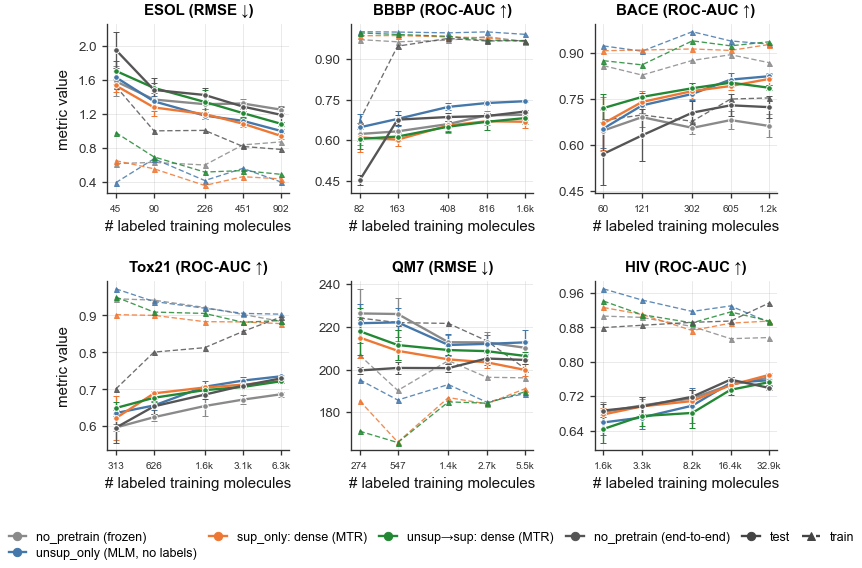


B1p1 mean |train - test| gap, smallest vs full budget:
                                  classification ROC-AUC        regression RMSE (native)
   no_pretrain (frozen)            0.282 ->  0.191             10.213 ->   7.208
   unsup_only (MLM, no labels)     0.317 ->  0.163             13.809 ->  12.237
   sup_only: dense (MTR)           0.285 ->  0.172             15.187 ->   4.641
   unsup→sup: dense (MTR)          0.285 ->  0.185             23.698 ->   8.679
   no_pretrain (end-to-end)        0.157 ->  0.163             12.454 ->   2.219


In [8]:
# ---------- B1p1 · label-efficiency, train vs test (per-task FRACTION sweep) ----------
LE_SUM="analysis/rigor/label_efficiency_fractions_all_summary.csv"
# Label-efficiency at per-task FRACTIONS of each task's own hold-out train split {5,10,25,50,100%}.
# Four frozen-probe arms + the end-to-end arm, all from one combined file (frozen arms REGENERATED
# on the GPU box so their n_train matches the e2e arm exactly at every (task,pct) -- an earlier
# local RDKit had dropped 5-6 HIV/Tox21 molecules; HIV full is now 32901, Tox21 full 6264, matching
# Table A1). This REPLACES the earlier shared-absolute-budget sweep {100,300,1k,3k,full}, which
# CAPPED on small tasks -- ESOL n=1000/3000/full were the identical 902 molecules, BACE/BBBP
# n=3000==full -- so the old figure plotted the same result 2-3x (reviewer-flagged). The x-axis is
# now n_train, which is per-task, so points sit at different x per task: that is the fix, not a bug.
# Regression is NATIVE units, matching the A1/A2 native-units fix (old label-eff RMSEs were in
# normalized units, ~2x smaller); classification (roc_auc/nef1) is unchanged. The e2e regression
# arm scales targets like the frozen arms do -- without that, QM7's ~-1531 mean is unreachable by an
# MSE head and it predicted ~0 (RMSE ~1500, 6x worse than chance); fixed, QM7 e2e is now ~200.
# Arm keys mirror the A1/A2 encoders (scripts/label_eff_fractions.py, bit-identical to the
# eval_v2.evaluate single-hold-out path -- same _subsample_train rng, zscore standardizer fit on the
# subsample, target scaler, MLP head, native-unit unscale):
#   random    -> climb_v2_phase2/random_baseline_00   (random init, frozen)
#   unsup     -> climb_v2_phase2/unsup_8M             (MLM only -- no supervised labels at all)
#   sup       -> climb_v2_phase2/skip_dense_8M        (random init -> MTR on descriptors)
#   unsup2sup -> climb_v2_phase2/u2s_dense_from8M     (MLM 8M -> MTR on descriptors)
LE_REGIMES=[("random","no_pretrain (frozen)",rc_color("no_pretrain")),
            ("unsup","unsup_only (MLM, no labels)",rc_color("unsup_only")),
            ("sup","sup_only: dense (MTR)",rc_color("sup_only:dense")),
            ("unsup2sup","unsup→sup: dense (MTR)",rc_color("unsup2sup:dense")),
            # Unlike the four frozen probes above, this arm re-FINE-TUNES the whole encoder (random
            # init) at each budget rather than re-fitting a frozen head, so it is the true
            # end-to-end baseline. Run at the SAME 5 per-task fractions; error bar is over 3
            # fine-tune seeds x 3 subsample draws (vs head x subsample for the frozen arms).
            ("e2e","no_pretrain (end-to-end)",rc_color("no_pretrain_e2e"))]

_led=pd.read_csv(LE_SUM) if os.path.exists(LE_SUM) else pd.DataFrame(
    columns=["arm","task","task_type","metric","split","n_train","mean","std"])
def _lemetric(task):        # this panel uses ONE shared train+test metric per task
    tt=_led[_led.task==task]
    return "rmse" if (len(tt) and tt.task_type.iloc[0]=="regression") else "roc_auc"
def le(reg,task,kind="test"):
    m=_lemetric(task)
    s=_led[(_led.arm==reg)&(_led.task==task)&(_led.split==kind)&(_led.metric==m)].sort_values("n_train")
    return s.n_train.to_numpy(), s["mean"].to_numpy(), s["std"].to_numpy()
def _kfmt(v):
    return (f"{v/1000:.1f}k".replace(".0k","k")) if v>=1000 else f"{int(round(v))}"

ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.4*nrow)); axes=axes.ravel()
_le_missing=set()
for ax,task in zip(axes,CORE_TASKS):
    drew=False; xticks=None
    for reg,_lab,c in LE_REGIMES:
        xs,te,ee=le(reg,task,"test")
        if not len(xs): _le_missing.add(_lab); continue
        _,tr,_=le(reg,task,"train")
        drew=True; xticks=xs
        ax.errorbar(xs,te,yerr=ee,color=c,marker="o",ms=3.4,lw=STYLE["lw"],mec="white",
                    capsize=2,elinewidth=0.8,zorder=3)
        if len(tr)==len(xs):
            ax.plot(xs,tr,color=c,marker="^",ms=3.0,lw=STYLE["lw_thin"],ls=(0,(4,2)),alpha=0.85,zorder=2)
    # Every classification panel (incl. HIV) uses ROC-AUC here: this is the train-vs-test-gap
    # (fit/generalize) panel, so a shared train/test metric is required and NEF1% has no train-set
    # counterpart. NEF1% is the HIV headline in the screening figures (A1/A2).
    _t=("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True))
    ax.set_title(_t,pad=6); ax.set_xlabel("# labeled training molecules")
    if xticks is not None:
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(ticker.FixedLocator(list(xticks)))
        ax.xaxis.set_major_formatter(ticker.FixedFormatter([_kfmt(v) for v in xticks]))
        ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
        ax.tick_params(axis="x",labelsize=STYLE["fs_annot"]-1.0)
    label_all_yticks(ax)
    if not drew: no_data_watermark(ax,"label-efficiency sweep missing")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
if _le_missing:                     # a legend entry with no line is a claim; say it is missing
    axes[0].text(0.02,0.02,"not run:\n"+"\n".join(sorted(_le_missing)),transform=axes[0].transAxes,
                 ha="left",va="bottom",fontsize=STYLE["fs_annot"]-1.5,color="#B00020",
                 linespacing=1.25,bbox=dict(fc="white",ec="none",alpha=0.85,pad=1.0))
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")

reg_h=[plt.Line2D([],[],color=c,marker="o",
                  label=lab+(" - NOT RUN" if lab in _le_missing else "")) for _,lab,c in LE_REGIMES]
sty_h=[plt.Line2D([],[],color="#444",marker="o",ls="-",label="test"),
       plt.Line2D([],[],color="#444",marker="^",ls=(0,(4,2)),label="train")]
fig.legend(handles=reg_h+sty_h,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=6,
           fontsize=STYLE["fs_legend"])
_suptitle(fig, "Fig B1p1 - label-efficiency and mechanism: does the frozen probe fit, or generalize?",
             fontsize=STYLE["fs_title"],y=1.075)
_b1note=("frozen probe re-fit at each label budget on the 8M encoders, single scaffold hold-out  ·  "
         "budgets are 5/10/25/50/100% of EACH task's own train split (x = # labeled training "
         "molecules, per-task -- this replaces the old shared absolute budget that capped small "
         "tasks)  ·  both SFT arms are the SAME `dense` (RDKit-MTR) recipe, so sup_only vs unsup→sup "
         "differs only in the MLM stage -- neither is an average over recipes  ·  3 subsample × 3 head "
         "seeds per point (100% = 3 head seeds; subsampling is a no-op at full)  ·  regression RMSE is "
         "in NATIVE units  ·  Tox21 'labels' = molecules (each carries up to 12 assay columns; AUC "
         "averaged over columns with both classes present)  ·  HIV keeps ROC-AUC here because this is "
         "the train-vs-test-gap panel and NEF1% has no train-set counterpart; NEF1% is the HIV "
         "headline in A1/A2")
_caption(fig, 0.5,0.995,"\n".join(_tw.wrap(_b1note,120)),
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.86,bottom=0.12,hspace=0.52,wspace=0.34)
save_fig(fig,"figB1p1_label_efficiency_train_test"); plt.show()

# mean |train - test| gap, split by task type so native-unit RMSE (QM7 ~10^2) is not averaged
# together with unitless ROC-AUC. Both should shrink as labels grow (over-fit closes).
_CLS=[t for t in CORE_TASKS if _lemetric(t)=="roc_auc"]
_REG=[t for t in CORE_TASKS if _lemetric(t)=="rmse"]
def _gap(reg,tasks,which):
    g=[]
    for t in tasks:
        xs,te,_=le(reg,t,"test"); _,tr,_=le(reg,t,"train")
        if not len(xs) or len(tr)!=len(xs): continue
        j=(0 if which=="min" else len(xs)-1)
        if np.isfinite(te[j]) and np.isfinite(tr[j]): g.append(abs(tr[j]-te[j]))
    return np.mean(g) if g else np.nan
print("\nB1p1 mean |train - test| gap, smallest vs full budget:")
print(f"   {'':30} classification ROC-AUC        regression RMSE (native)")
for reg,lab,_ in LE_REGIMES:
    c0,c1=_gap(reg,_CLS,'min'),_gap(reg,_CLS,'max')
    r0,r1=_gap(reg,_REG,'min'),_gap(reg,_REG,'max')
    print(f"   {lab:<30} {c0:6.3f} -> {c1:6.3f}            {r0:7.3f} -> {r1:7.3f}")


## E1 · H5 — is the `sup_only` / `unsup_only` ordering a frozen-probe artifact?

Every other figure scores a **frozen** encoder. Two things could be artifacts of that probe:

- the pretraining ladder looks **flat** — maybe the head is too weak to exploit a better encoder;
- `sup_only` and `unsup_only` sit in a particular **order** — maybe unfreezing reverses it.

The second is H5, and it needs *both* regimes in *both* conditions: a single frozen line and a
single fine-tuned line have nothing to flip against. So each task carries four series —
`unsup_only` and `sup_only` (`dense`, the best recipe by mean lift in A1), each frozen and
fine-tuned end-to-end, at matched 2M/8M/24M budgets.

- **(a)** the ladders. Open marker + dashed = frozen, filled + solid = fine-tuned.
- **(b)** the ordering test at the matched 8M budget: one segment per regime, frozen → fine-tuned.
  The two regimes are plotted side by side on a shared y-axis, so **a crossing between the
  segments is an ordering flip** and is impossible to miss.

Two cautions the panels carry in their caption. HIV is scored by ROC-AUC here, not the NEF1% used
elsewhere, because that is what the fine-tuning harness computes — train and test must be the same
metric on both sides of the comparison. And the two error bars are *not* the same quantity: a
frozen probe's only randomness is the head (the encoder is fixed, so its features are
deterministic), while a fine-tuning seed re-randomises the head **and** the whole encoder
optimisation.

saved figE1_H5_eval_ceiling


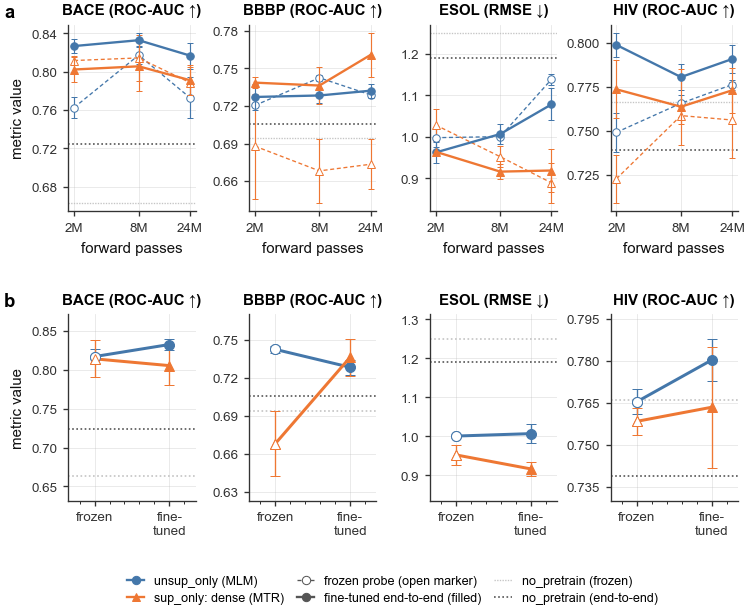


E1 (a) ladder shape - spread across the pretrained ladder vs the head-seed noise it must clear:
   unsup_only (MLM)       BACE  frozen=0.0546 (3.9x head-seed sd) finetuned=0.0160  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       BBBP  frozen=0.0220 (11.6x head-seed sd) finetuned=0.0050  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       ESOL  frozen=0.1404 (11.6x head-seed sd) finetuned=0.1158  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       HIV   frozen=0.0271 (4.4x head-seed sd) finetuned=0.0183  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   sup_only: dense (MTR)  BACE  frozen=0.0257 (1.7x head-seed sd) finetuned=0.0144  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   sup_only: dense (MTR)  BBBP  frozen=0.0198 (0.7x head-seed sd) finetuned=0.0244  -> fine-tuning SEPARATES them: the probe may be the ceiling
   sup_only: dense (MTR)  ESOL  froze

In [9]:
# ---------- E1 · H5: regime-split eval ceiling ----------
# The first version of this figure plotted ONE frozen and ONE fine-tuned line, both from the
# unsup_only ladder. That answers a ladder-SHAPE question; it cannot answer H5, which is about the
# ORDERING of two regimes. sup_only is fine-tuned by scripts/run_e1_sup_gpu.sh into a separate
# output dir, merged here, so the 48 unsup fine-tunes are not redone.
CEIL     = DATA_ROOT/"_eval_ceiling"/"eval_ceiling.csv"
CEIL_SUP = DATA_ROOT/"_eval_ceiling_sup"/"eval_ceiling.csv"
E1_SUP_RECIPE = "dense"          # best sup_only recipe by mean lift in A1

def _regime_of(run_id):
    if run_id.startswith("random_baseline"): return "no_pretrain"
    if run_id.startswith("unsup_"):          return "unsup_only"
    m=re.match(r"skip_(.+)_\d+M$",run_id)
    return f"sup_only:{m[1]}" if m else None

_parts=[pd.read_csv(q) for q in (CEIL,CEIL_SUP) if q.exists()]
C = pd.concat(_parts,ignore_index=True) if _parts else pd.DataFrame()
if len(C):
    if "seed" not in C.columns: C["seed"]=0
    C["regime"]=C.run_id.map(_regime_of)

E1_REGIMES=[k for k in ("unsup_only",f"sup_only:{E1_SUP_RECIPE}")
            if len(C) and k in set(C.regime)]
_E1_PENDING=[k for k in ("unsup_only",f"sup_only:{E1_SUP_RECIPE}") if k not in E1_REGIMES]

if not len(C):
    fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6))
    no_data_watermark(ax,"run scripts/run_e1_gpu.sh")
    _suptitle(fig, "Fig E1 (H5) [NO DATA]",fontsize=STYLE["fs_title"])
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()
else:
    nseed=C.seed.nunique()
    e1_tasks=[t for t in ("BACE","BBBP","ESOL","HIV") if t in set(C.task)]

    # Frozen values come from the run summaries PER HEAD SEED, not from the cached CSV: the CSV
    # collapsed them to a single MEAN and copied it onto every seed row, so its spread was zero.
    # Reading the summaries also keeps E1 on the same scorer as A1/A2.
    def _frozen_seeds(run_id,task):
        f=DATA_ROOT/"climb_v2_phase2"/run_id/"moleculenet"/"moleculenet_summary.csv"
        if not f.exists(): return np.array([])
        d=pd.read_csv(f)
        d=d[(d.dataset==task)&(d.main_metric.isin(["roc_auc","rmse"]))     # not _train, not nef1
            &(~d.head_seed.astype(str).isin(["MEAN","STD"]))]
        return d.main_value.values.astype(float)

    def e1_points(regime,task):
        """-> tidy frame: one row per budget with frozen/fine-tuned mean and sd."""
        s=C[(C.regime==regime)&(C.task==task)&(C.budget>0)]
        rows=[]
        for (rid,b),g in s.groupby(["run_id","budget"]):
            fz=_frozen_seeds(rid,task)
            rows.append(dict(run_id=rid,budget=b,
                             fz=(np.mean(fz) if len(fz) else np.nan),
                             fz_sd=(np.std(fz,ddof=1) if len(fz)>1 else np.nan),
                             ft=g.finetune.mean(),
                             ft_sd=(g.finetune.std() if len(g)>1 else np.nan)))
        return pd.DataFrame(rows).sort_values("budget") if rows else pd.DataFrame()

    def e1_random(task,col):
        s=C[(C.regime=="no_pretrain")&(C.task==task)]
        v=s[col].mean() if len(s) else np.nan
        if col=="frozen" and not np.isfinite(v):
            # The eval-ceiling CSV carries no frozen value for the random-init runs on HIV, so the
            # no_pretrain FROZEN reference vanished there. Recover it from the SAME frozen-probe
            # summaries the pretrained ladder is read from (identical scorer), so HIV gets its line.
            fz=[x for rid in ("random_baseline_00","random_baseline_01","random_baseline_02")
                  for x in _frozen_seeds(rid,task)]
            v=float(np.mean(fz)) if fz else np.nan
        return v

    E1_STYLE={k:dict(c=rc_color(k),m=rc_marker(k) or "o") for k in E1_REGIMES}
    ncol=len(e1_tasks)
    fig,axes=plt.subplots(2,ncol,figsize=(STYLE["col2"],6.2),
                          gridspec_kw=dict(height_ratios=[1,1],hspace=0.55,wspace=0.42))
    axes=np.atleast_2d(axes)

    # ---------- (a) the ladders: 2 regimes x {frozen, fine-tuned} ----------
    for j,task in enumerate(e1_tasks):
        ax=axes[0,j]
        for k in E1_REGIMES:
            d=e1_points(k,task)
            if d.empty: continue
            st=E1_STYLE[k]
            ax.errorbar(d.budget,d.fz,yerr=d.fz_sd.fillna(0),color=st["c"],marker=st["m"],
                        ls=(0,(3,2)),lw=STYLE["lw_thin"],mfc="white",ms=4.5,
                        capsize=2,elinewidth=0.7,zorder=3)
            ax.errorbar(d.budget,d.ft,yerr=d.ft_sd.fillna(0),color=st["c"],marker=st["m"],
                        ls="-",lw=STYLE["lw"],ms=4.5,capsize=2,elinewidth=0.7,zorder=4)
        # Both random-init references. The end-to-end one sat unused in the same CSV -- without it
        # the panel shows what pretraining buys over a FROZEN random encoder, which is the easy
        # comparison; the fine-tuned random encoder is the one a practitioner would actually use.
        _rf=e1_random(task,"frozen")
        if np.isfinite(_rf):
            ax.axhline(_rf,ls=(0,(1,1)),color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
        _re=e1_random(task,"finetune")
        if np.isfinite(_re):
            ax.axhline(_re,ls=(0,(1,1.5)),color=rc_color("no_pretrain_e2e"),lw=1.0,zorder=1)
        _bud=sorted(C[(C.task==task)&(C.budget>0)].budget.unique())
        if _bud: set_fp_axis(ax,_bud)
        ax.set_xlabel("forward passes")
        ax.set_title(("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True)),pad=6)
        label_all_yticks(ax)
    axes[0,0].set_ylabel("metric value")
    panel_tag(axes[0,0],"a",dx=-0.42)

    # ---------- (b) the H5 ordering test at the matched budget ----------
    _flips=[]
    for j,task in enumerate(e1_tasks):
        ax=axes[1,j]
        hb=TASKS[task]["higher_better"] if task!="HIV" else True   # ROC-AUC here, so higher=better
        vals={}
        for k in E1_REGIMES:
            d=e1_points(k,task)
            if d.empty: continue
            r=d.iloc[(d.budget-BUDGET_FP[MATCHED_BUDGET]).abs().argsort().iloc[0]]
            st=E1_STYLE[k]
            ax.errorbar([0,1],[r.fz,r.ft],
                        yerr=[0 if not np.isfinite(r.fz_sd) else r.fz_sd,
                              0 if not np.isfinite(r.ft_sd) else r.ft_sd],
                        color=st["c"],marker=st["m"],ms=6,lw=STYLE["lw"]+0.4,
                        capsize=3,elinewidth=0.8,zorder=3)
            ax.plot([0],[r.fz],marker=st["m"],ms=6,color=st["c"],mfc="white",zorder=4)  # open=frozen
            vals[k]=(r.fz,r.ft)
        for _c,_v in ((PALETTE["grey2"],e1_random(task,"frozen")),
                      (rc_color("no_pretrain_e2e"),e1_random(task,"finetune"))):
            if np.isfinite(_v):
                ax.axhline(_v,ls=(0,(1,1.5)),color=_c,lw=1.0,zorder=1)
        ax.set_xlim(-0.35,1.35); ax.set_xticks([0,1])
        ax.set_xticklabels(["frozen","fine-\ntuned"])
        ax.set_title(("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True)),pad=6)
        label_all_yticks(ax)
        # Deliberately NOT sharing y with the ladder above: on the ladder's range the two segments
        # sit almost on top of each other and a crossing is invisible, which is the one thing this
        # panel exists to show. It is zoomed to its own data; the caption says so.
        ax.margins(y=0.18)
        # Does the ordering survive? Compare the sign of (unsup - sup) in each condition.
        if len(vals)==2:
            u,s_=vals["unsup_only"],vals[f"sup_only:{E1_SUP_RECIPE}"]
            better=lambda a,b:(a>b) if hb else (a<b)
            fz_u_wins,ft_u_wins=better(u[0],s_[0]),better(u[1],s_[1])
            flip = fz_u_wins!=ft_u_wins
            # The flip verdict is still computed and PRINTED below the figure, but no longer
            # stamped on the panel: a bold red "ORDERING FLIPS" reads as a conclusion when the
            # error bars here routinely overlap, and it is one word doing work the reader should
            # do by looking at the two segments.
            _flips.append((task,fz_u_wins,ft_u_wins,flip))
    axes[1,0].set_ylabel("metric value")
    panel_tag(axes[1,0],"b",dx=-0.42)

    handles=[plt.Line2D([],[],color=E1_STYLE[k]["c"],marker=E1_STYLE[k]["m"],ls="-",
                        label=rc_label(k)) for k in E1_REGIMES]
    handles+=[plt.Line2D([],[],color="#555",marker="o",mfc="white",ls=(0,(3,2)),
                         lw=STYLE["lw_thin"],label="frozen probe (open marker)"),
              plt.Line2D([],[],color="#555",marker="o",ls="-",label="fine-tuned end-to-end (filled)"),
              plt.Line2D([],[],color=PALETTE["grey2"],ls=(0,(1,1)),lw=STYLE["lw_thin"],
                         label="no_pretrain (frozen)"),
              plt.Line2D([],[],color=rc_color("no_pretrain_e2e"),ls=(0,(1,1.5)),lw=1.0,
                         label="no_pretrain (end-to-end)")]
    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.155),ncol=3,
               fontsize=STYLE["fs_legend"])
    _suptitle(fig, "Fig E1 (H5) - is the sup_only / unsup_only ordering a frozen-probe artifact?",
                 fontsize=STYLE["fs_title"],y=0.99)
    # One figure-level pending note: per-panel boxes landed on the data in all four panels, and
    # the missing arm is missing everywhere, so saying it four times bought nothing.
    if _E1_PENDING:
        fig.text(0.5,0.955,"PENDING - "+", ".join(rc_label(k) for k in _E1_PENDING)
                 +" not fine-tuned yet, so (b) cannot test the ordering",
                 ha="center",va="top",fontsize=STYLE["fs_annot"],color="#B00020",fontweight="bold")
    _fzn=max([len(_frozen_seeds(r,e1_tasks[0])) for r in C.run_id.unique()]+[0])
    _note=(f"(b) is the matched {MATCHED_BUDGET} rung of (a), zoomed to its own range so a "
           f"crossing is visible. Error bars: dashed/open = ±1 sd over "
           f"{_fzn} head seeds - a frozen probe has no other randomness, the encoder is fixed; "
           f"solid/filled = ±1 sd over {nseed} fine-tuning seeds, which re-randomise the head AND "
           f"the encoder optimisation, so the two are not the same quantity. Single scaffold "
           f"hold-out (not the 5-fold CV of A1/A2). HIV is reported as ROC-AUC here, deliberately: "
           f"this figure tests whether end-to-end fine-tuning changes the frozen-probe ORDERING, for "
           f"which ROC-AUC is the right endpoint; the virtual-screening endpoint (NEF1%) is the "
           f"headline in A1/A2. (NEF1% is also unavailable here -- the fine-tuning harness saved "
           f"no predictions.) "
           f"The no_pretrain FROZEN reference on HIV is recovered from the random-init runs' "
           f"frozen-probe summaries (the eval-ceiling CSV lacks a frozen HIV value); elsewhere it "
           f"comes from that CSV. Both no_pretrain references are present on all four tasks.")
    fig.subplots_adjust(top=0.88,bottom=0.24)
    _caption(fig, 0.5,0.085,"\n".join(_tw.wrap(_note,132)),ha="center",va="top",
             fontsize=STYLE["fs_annot"]-0.5,color="#666")
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()

    # ---------- printed readouts ----------
    if _E1_PENDING:
        print("E1: STILL PENDING -> "+", ".join(rc_label(k) for k in _E1_PENDING)
              +"  (run scripts/run_e1_sup_gpu.sh)")
    print(f"\nE1 (a) ladder shape - spread across the pretrained ladder vs the head-seed noise "
          f"it must clear:")
    for k in E1_REGIMES:
        for task in e1_tasks:
            d=e1_points(k,task)
            if len(d)<2: continue
            noise=np.nanmean(d.fz_sd.values)
            dz,dt=d.fz.max()-d.fz.min(),d.ft.max()-d.ft.min()
            verdict=("fine-tuning COMPRESSES it: the probe was NOT the ceiling" if dt<dz
                     else "fine-tuning SEPARATES them: the probe may be the ceiling")
            print(f"   {rc_label(k):<22} {task:<5} frozen={dz:.4f} ({dz/noise:.1f}x head-seed sd) "
                  f"finetuned={dt:.4f}  -> {verdict}")
    if _flips:
        print(f"\nE1 (b) H5 ordering at {MATCHED_BUDGET} (does unsup_only beat sup_only?):")
        for task,fz_u,ft_u,flip in _flips:
            print(f"   {task:<5} frozen: {'unsup' if fz_u else 'sup'} ahead   "
                  f"fine-tuned: {'unsup' if ft_u else 'sup'} ahead   "
                  f"-> {'FLIPS' if flip else 'holds'}")
        nf=sum(f for _,_,_,f in _flips)
        print(f"   {nf}/{len(_flips)} tasks flip. "
              +("The frozen ordering is NOT preserved under fine-tuning." if nf>len(_flips)/2
                else "The frozen ordering largely survives fine-tuning, so it is not a probe artifact."))

## B2 · If we pretrain on a *garbled* objective, do the benefits survive?

The E13 control holds objective, data volume, compute, schedule and model fixed and removes only
the **chemical content**:

- `corrupt_mlm` — token order permuted inside each sequence (SMILES grammar destroyed, token
  distribution and mask rate preserved).
- `corrupt_mtr` — descriptor targets permuted across the batch (molecule→descriptor mapping
  destroyed, target distribution untouched).

How to read it: *corrupted ≈ no_pretrain, real > both* ⇒ pretraining adds **information**.
*corrupted ≈ real* ⇒ the gain comes from the objective's structure (initialization / regularization),
not from chemistry.

saved figB2_corrupted_control


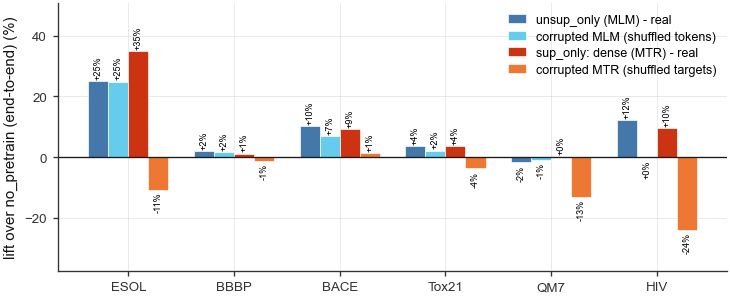

B2 mean lift over no_pretrain (end-to-end) across the core tasks (pooled 5-fold scaffold CV):
   unsup_only (MLM) - real                    +8.6%  (n=6)
   corrupted MLM (shuffled tokens)            +5.8%  (n=6)
   sup_only: dense (MTR) - real               +9.8%  (n=6)
   corrupted MTR (shuffled targets)           -8.6%  (n=6)

per-task lift (%), to expose any single task driving the mean:
       unsup_only (MLM) - real  corrupted MLM (shuffled tokens)  sup_only: dense (MTR) - real  corrupted MTR (shuffled targets)
ESOL                      25.2                             24.9                          35.0                             -10.8
BBBP                       1.9                              1.6                           1.2                              -1.2
BACE                      10.3                              6.9                           9.1                               1.4
Tox21                      3.7                              2.2                           3.8 

In [10]:
# ---------- B2 · corrupted-pretraining control ----------
# Colour encodes the PAIR, lightness encodes real-vs-corrupted: dark blue / light blue for the MLM
# pair, dark red / light orange for the MTR pair. All four come from the shared PALETTE, so the
# figure still reads as part of the same set even though the pairing is B2-specific.
B2_SERIES=[("unsup_only",     "unsup_only (MLM) - real",          PALETTE["blue"]),
           ("corrupt_mlm",    "corrupted MLM (shuffled tokens)",  PALETTE["cyan"]),
           ("sup_only:dense", "sup_only: dense (MTR) - real",     PALETTE["red"]),
           ("corrupt_mtr",    "corrupted MTR (shuffled targets)", PALETTE["orange"])]

# PREFER the 5-fold CV: on the single hold-out this panel is scored on 113-204 molecules per task
# and HIV's NEF1% comes off the top 1% of ~4.1k molecules (~41 molecules), which is why the HIV
# bars swing wildly there. The corrupted encoders have not been CV-scored yet, so the figure falls
# back to the hold-out and says so on its face rather than quietly using the weak split.
_b2_have_cv=all(len(arm_rows(DF_CV,"ESOL",k)) for k,_,_ in B2_SERIES)
B2_DF   = DF_CV if _b2_have_cv else DF
B2_SCHEME=("pooled 5-fold scaffold CV" if _b2_have_cv else
           "single scaffold hold-out (113-204 test molecules) - CV PENDING for the corrupted arms")
_have_b2=any(len(arm_rows(B2_DF,"ESOL",k)) for k,_,_ in B2_SERIES if k.startswith("corrupt"))

# FLOOR: no_pretrain END-TO-END, matching I1 and C1J1. Zero on this axis is therefore "as good as
# just fine-tuning a random encoder", which is the decision a practitioner faces. Previously the
# zero line was the FROZEN no_pretrain while the end-to-end arm was drawn as a separate reference
# -- internally consistent, but it meant three figures in the same paper measured lift against two
# different baselines, and the reference line invited exactly the reading that it should sit at 0.
# Now it does sit at 0 (it IS the axis) and is not drawn; the frozen floor becomes the reference.
def b2_floor(task):
    v=arm_value(B2_DF,task,"no_pretrain_e2e")
    return v if np.isfinite(v) else npt_floor(B2_DF,task)
B2_FLOOR_LABEL=("no_pretrain (end-to-end)"
                if np.isfinite(arm_value(B2_DF,"ESOL","no_pretrain_e2e")) else "no_pretrain (frozen)")

fig,ax=plt.subplots(figsize=(STYLE["col2"],2.9))
x=np.arange(len(CORE_TASKS)); w=0.19
for i,(key,lab,c) in enumerate(B2_SERIES):
    ys=[100*lift(arm_value(B2_DF,t,key),t,b2_floor(t)) for t in CORE_TASKS]
    ax.bar(x+(i-1.5)*w,ys,width=w,color=c,edgecolor="white",lw=0.4,label=lab)
    # Value on every bar. Four bars per task at this width are hard to read off the axis, and the
    # interesting comparisons are between ADJACENT bars (real vs corrupted), where a couple of
    # points either way changes the conclusion.
    # Vertical (90 deg), centred on the bar, rather than 45 deg: at 45 deg the text extends up and
    # to the RIGHT, so a tall label ran across its neighbour -- ESOL's +27% bled onto the +35% bar
    # next to it. Vertical text has zero horizontal extent, so no label can ever reach a
    # neighbouring bar whatever the numbers turn out to be. Fixing the geometry rather than nudging
    # the one label that collided today, since the collision moves when the data does.
    for _xi,_v in zip(x+(i-1.5)*w,ys):
        if not np.isfinite(_v): continue
        _lbl=f"{0.0 if abs(_v)<0.5 else _v:+.0f}%"          # avoid a stray "-0%"
        ax.text(_xi,_v+(0.7 if _v>=0 else -0.7),_lbl,rotation=90,ha="center",
                va="bottom" if _v>=0 else "top",
                fontsize=STYLE["fs_annot"]-1.5,color="black",clip_on=False)
ax.axhline(0,color=PALETTE["black"],lw=0.8)
# "Skip pretraining and just fine-tune" is the reference that makes the corrupted/real contrast
# actionable: a corrupted arm that clears no_pretrain but not this one has bought nothing real.
ax.set_xticks(x); ax.set_xticklabels([TASKS[t]["pretty"] for t in CORE_TASKS])
# The global style turns minor ticks on, which is right for a continuous axis and wrong here: this
# x-axis is six categories, so the minor ticks mark positions that do not exist.
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.tick_params(axis="x", which="minor", bottom=False)
ax.set_ylabel(f"lift over {B2_FLOOR_LABEL} (%)"); label_all_yticks(ax)
# Headroom for the rotated labels at both extremes, or the tallest/deepest ones are clipped.
_lo,_hi=ax.get_ylim(); _sp=_hi-_lo
ax.set_ylim(_lo-0.16*_sp,_hi+0.20*_sp)   # vertical labels are taller than rotated ones
if not _have_b2:
    ax.text(0.5,1.02,"CORRUPTED ARMS NOT YET AVAILABLE — corrupt_mlm_8M / corrupt_mtr_8M still training",
            transform=ax.transAxes,ha="center",va="bottom",fontsize=STYLE["fs_annot"],
            color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",fc="#FCE8E8",ec="#B00020",lw=0.8))
elif not _b2_have_cv:
    ax.text(0.5,1.02,"SCHEME FALLBACK — corrupted arms have no 5-fold CV eval yet, so this panel is "
            "on the small single hold-out; HIV especially is unreliable here",
            transform=ax.transAxes,ha="center",va="bottom",fontsize=STYLE["fs_annot"]-1,
            color="#B00020",bbox=dict(boxstyle="round,pad=0.3",fc="#FCE8E8",ec="#B00020",lw=0.8))
# Legend INSIDE, upper-right: the tall bars are ESOL on the left and HIV on the right is small, so
# the top-right corner is empty. This removes the wasted band under the figure and, by dropping the
# reserved bottom margin, re-centres the axes so the long y-label stops overflowing the top on export.
# Natural order keeps each real/corrupted pair adjacent (MLM pair, then MTR pair).
ax.legend(loc="upper right",ncol=1,fontsize=STYLE["fs_legend"],framealpha=0.9,borderaxespad=0.5)
_suptitle(fig, "Fig B2 - does content-free pretraining help just as much?",
             fontsize=STYLE["fs_title"],y=1.18)
_b2note=(f"zero = {B2_FLOOR_LABEL}, i.e. skipping pretraining and just fine-tuning a random "
         f"encoder  ·  {B2_SCHEME}. Each corrupted arm is matched to its real counterpart in "
         f"objective, data volume, compute and schedule; only chemical content is destroyed.")
_caption(fig, 0.5,1.06,"\n".join(_tw.wrap(_b2note,112)),
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
save_fig(fig,"figB2_corrupted_control"+("" if _have_b2 else "_PLACEHOLDER")); plt.show()

if _have_b2:
    print(f"B2 mean lift over {B2_FLOOR_LABEL} across the core tasks ({B2_SCHEME}):")
    for key,lab,_ in B2_SERIES:
        ls=[lift(arm_value(B2_DF,t,key),t,b2_floor(t)) for t in CORE_TASKS]
        ls=[v for v in ls if np.isfinite(v)]
        if ls: print(f"   {lab:<40} {100*np.mean(ls):+6.1f}%  (n={len(ls)})")
    print("\nper-task lift (%), to expose any single task driving the mean:")
    print(pd.DataFrame({lab:[100*lift(arm_value(B2_DF,t,key),t,b2_floor(t)) for t in CORE_TASKS]
                        for key,lab,_ in B2_SERIES},index=CORE_TASKS).round(1).to_string())
else:
    print("B2: no corrupted-control data yet. Expected runs: corrupt_mlm_8M, corrupt_mtr_8M "
          "(8M FP each, matched to unsup_8M / skip_dense_8M).")

## C1J1 · Which supervised pretraining data helps, how much, and does it track chemistry?

One figure, three panels, because the three questions share the same runs and plotting them apart
duplicated the same numbers twice:

- **(a)** Average lift over `no_pretrain` per arm — *which SFT label type is most beneficial?*
- **(b)** The same lift resolved per evaluation task — *where does each family transfer to?*
- **(c)** The **H10 test**: does that transfer track chemical similarity between the SFT family and
  the evaluation task? Each point is one arm × task cell from (b). x is mean max ECFP4 **Tanimoto
  similarity** — further right means the eval molecules are *more* similar to what the arm trained
  on. A positive slope would support content-similarity-driven transfer.

All arms are `unsup→sup` from one shared MLM base, evaluated identically. This is the **deduped**
wave: the SFT blocklist drops 34 301 eval molecules, so no arm trains on eval-test molecules and
(c) measures genuine near-neighbour chemistry rather than memorization.

   frozen floors agree across both waves on all 6 tasks -> safe to lift every arm against phase2's no_pretrain (end-to-end) floor


saved figC1J1_sft_family_transfer


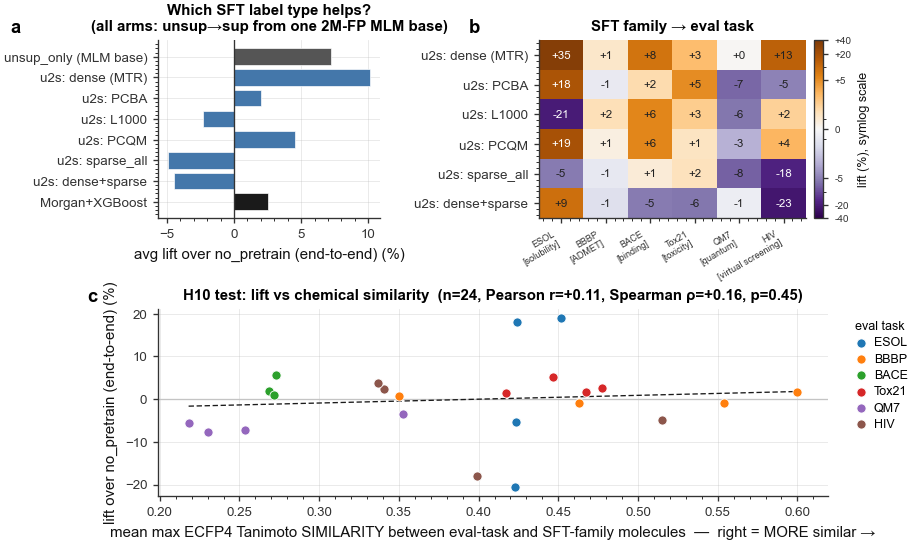

C1J1 (a) mean lift over no_pretrain (end-to-end):
   unsup_only (MLM base)      +7.2%
   u2s: dense (MTR)          +10.2%
   u2s: PCBA                  +2.0%
   u2s: L1000                 -2.3%
   u2s: PCQM                  +4.5%
   u2s: sparse_all            -4.9%
   u2s: dense+sparse          -4.4%
   Morgan+XGBoost             +2.5%

NOTE - C1J1 vs A1 are different models despite the shared recipe names:
   C1J1 'u2s: dense+sparse' = climb_v2_ablation_dedup/seq_dense_plus_sparse (unsup→sup from a 2M MLM base, single hold-out)
   A1   'sup_only: dense+sparse' = climb_v2_phase2/skip_dense_plus_sparse_8M (random init, 8M SFT, A1.b uses 5-fold CV)
   Different regime, budget, wave AND eval scheme -- their rankings need not agree.

C1J1 (c) H10: n=24 arm x task cells, Pearson r=+0.107, Spearman rho=+0.162 (p=0.450), similarity range 0.22-0.60
   within ESOL  : rho=+1.00 (n=4)
   within BBBP  : rho=+0.20 (n=4)
   within BACE  : rho=+0.80 (n=4)
   within Tox21 : rho=+0.40 (n=4)
   within Q

In [11]:
# ---------- C1J1 · SFT-family ablation + transfer matrix + the H10 similarity test ----------
ABL="climb_v2_ablation_dedup"
ABL_ARMS=["seq_mtr","seq_pcba","seq_l1000","seq_pcqm","seq_sparse_all","seq_dense_plus_sparse"]
# Every arm here is unsup->sup warm-started from ONE 2M-FP MLM base, in the ablation wave, scored
# on the single scaffold hold-out. The bare recipe names ("dense+sparse") are also A1/A2 arm names
# for a DIFFERENT model -- sup_only, random init, 8M budget, phase-2 wave -- so they are prefixed
# here. Without the prefix the two figures look like they contradict each other when they are
# simply reporting different models.
ABL_LABEL={"seq_mtr":"u2s: dense (MTR)","seq_pcba":"u2s: PCBA","seq_l1000":"u2s: L1000",
           "seq_pcqm":"u2s: PCQM","seq_sparse_all":"u2s: sparse_all",
           "seq_dense_plus_sparse":"u2s: dense+sparse"}
# The ablation arms warm-start from climb_v2_phase2/unsup_2M, so THAT is the MLM base to show as
# the reference row -- not the round-1 unsup_only run the earlier version of this figure used.
BASE_RUN=(DATA_ROOT/"climb_v2_phase2"/"unsup_2M")
# Prefer the 5-fold CV as soon as the whole wave has it. This panel was stuck on the single
# hold-out (113-204 test molecules on the small tasks) because the ablation wave had never been
# CV-scored. It needs the WHOLE wave -- every seq_* arm AND the three random_baseline_* that form
# the floor AND the anchor -- because each arm is lifted against the floor scored in its own wave;
# a CV floor with hold-out arms would silently produce wrong lifts. All-or-nothing, checked here.
_abl_dirs=sorted((DATA_ROOT/ABL).glob("*/"))
C1J1_SUB=("moleculenet_cv"
          if _abl_dirs and all((d/"moleculenet_cv"/"suite_summary.json").exists() for d in _abl_dirs)
             and (BASE_RUN/"moleculenet_cv"/"suite_summary.json").exists()
          else "moleculenet")
C1J1_SCHEME=("pooled 5-fold scaffold CV" if C1J1_SUB=="moleculenet_cv" else
             "single scaffold hold-out (113-204 test molecules) - CV PENDING for this wave")

def _wave_floor(wave,task):
    """Mean of the three random-init encoders AS SCORED IN THAT WAVE."""
    v=[]
    for rb in sorted((DATA_ROOT/wave).glob("random_baseline*/")):
        d=load_suite(rb,sub=C1J1_SUB); sk=TASKS[task].get("suite_key",task)
        if d and (sk,"mean") in d: v.append(d[(sk,"mean")])
    return float(np.mean(v)) if v else np.nan
abl_floor=lambda task:_wave_floor(ABL,task)

# FLOOR CHOICE -- same change as I1. Lift over the FROZEN random encoder is the easy comparison:
# a frozen random encoder cannot adapt to the task at all, so nearly anything clears it. The
# honest floor is the random encoder FINE-TUNED end-to-end, which is what a practitioner would do
# INSTEAD of pretraining.
# Those runs live in climb_v2_phase2, not this wave, and this figure otherwise refuses cross-wave
# comparisons. It is safe here only because the two waves' FROZEN floors are numerically identical
# on all six tasks (both CV-scored, same random-init encoders, same folds) -- checked in the
# printout below, so the day that stops being true it is visible rather than silent.
C1J1_FLOOR_LABEL="no_pretrain (end-to-end)"
def c1j1_floor(task):
    v=arm_value(DF_CV if C1J1_SUB=="moleculenet_cv" else DF,task,"no_pretrain_e2e")
    return v if np.isfinite(v) else _wave_floor(ABL,task)   # frozen floor if e2e is not scored

# The two waves run the SAME three random-init encoders, but they were scored in separate eval
# runs, and re-scoring shifts a metric by up to ~0.03. So each arm is lifted against the floor
# from ITS OWN wave -- comparing lifts, each internally consistent -- rather than against one
# borrowed floor. The divergence is printed so the size of the effect is visible, not assumed away.
_drift=[(t,a,b) for t in CORE_TASKS
         for a,b in [(abl_floor(t),npt_floor(DF_CV if C1J1_SUB=="moleculenet_cv" else DF,t))]
         if np.isfinite(a) and np.isfinite(b) and abs(a-b)>5e-3]
if _drift:
    print("   WARNING - the two waves' frozen floors have drifted apart, so borrowing phase2's "
          "end-to-end floor for this wave is no longer safe:")
    for _t,_a,_b in _drift:
        print(f"      {_t}: ablation={_a:.4f} vs phase2={_b:.4f} ({100*abs(_a-_b)/_b:.1f}%)")
else:
    print(f"   frozen floors agree across both waves on all {len(CORE_TASKS)} tasks "
          f"-> safe to lift every arm against phase2's {C1J1_FLOOR_LABEL} floor")

rows=[]
_srcs=[("unsup_only (MLM base)",BASE_RUN,"climb_v2_phase2")]+\
      [(ABL_LABEL[a],DATA_ROOT/ABL/a,ABL) for a in ABL_ARMS]+\
      [("Morgan+XGBoost",DATA_ROOT/ABL/"ecfp4_anchor",ABL)]
for disp,rd,wv in _srcs:
    d=load_suite(rd,sub=C1J1_SUB)
    if not d: continue
    for task in CORE_TASKS:
        sk=TASKS[task].get("suite_key",task)
        if (sk,"mean") in d:
            rows.append(dict(arm=disp,task=task,lift=lift(d[(sk,"mean")],task,c1j1_floor(task))))
AB=pd.DataFrame(rows)
ARM_ORDER=[a for a in ["unsup_only (MLM base)"]+[ABL_LABEL[a] for a in ABL_ARMS]+["Morgan+XGBoost"]
           if a in set(AB.arm)]

fig=plt.figure(figsize=(STYLE["col2"],5.2))
gs=fig.add_gridspec(2,2,width_ratios=[1,1.30],height_ratios=[1,1.05],hspace=0.50,wspace=0.62)
axA=fig.add_subplot(gs[0,0]); axB=fig.add_subplot(gs[0,1]); axC=fig.add_subplot(gs[1,:])

# --- (a) mean lift per arm ---
avg=AB.groupby("arm").lift.mean().reindex(ARM_ORDER)*100
cols=["#555555" if a.startswith("unsup_only") else
      (PALETTE["black"] if a=="Morgan+XGBoost" else PALETTE["blue"]) for a in ARM_ORDER]
axA.barh(range(len(ARM_ORDER)),avg.values,color=cols,edgecolor="white",lw=0.4)
axA.axvline(0,color="#333",lw=0.8)
axA.set_yticks(range(len(ARM_ORDER))); axA.set_yticklabels(ARM_ORDER); axA.invert_yaxis()
axA.set_xlabel(f"avg lift over {C1J1_FLOOR_LABEL} (%)")
axA.set_title("Which SFT label type helps?\n(all arms: unsup→sup from one 2M-FP MLM base)",
              pad=6); panel_tag(axA,"a",dx=-0.62)

# --- (b) per-task transfer matrix (SFT families only; the base/anchor rows live in (a)) ---
MAT_ROWS=[ABL_LABEL[a] for a in ABL_ARMS if ABL_LABEL[a] in set(AB.arm)]
H=AB.pivot(index="arm",columns="task",values="lift").reindex(index=MAT_ROWS,columns=CORE_TASKS)*100
# HIV lift runs to -79%, so a linear +/-15 scale painted the whole HIV column one flat colour
# and hid a 60-point spread. A symmetric-log norm keeps the small +/-5% structure readable while
# still ranking the large negatives honestly.
_vmax=float(np.nanmax(np.abs(H.values))); _vmax=max(20.0,np.ceil(_vmax/10)*10)
_norm=mpl.colors.SymLogNorm(linthresh=5,linscale=1.0,vmin=-_vmax,vmax=_vmax,base=10)
im=axB.imshow(H.values,cmap="PuOr_r",norm=_norm,aspect="auto")
axB.set_xticks(range(len(CORE_TASKS)))
axB.set_xticklabels([f'{TASKS[t]["pretty"]}\n[{TASKS[t]["domain"]}]' for t in CORE_TASKS],
                    fontsize=STYLE["fs_annot"]-1.5,rotation=30,ha="right")
axB.set_yticks(range(len(MAT_ROWS))); axB.set_yticklabels(MAT_ROWS)
axB.grid(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v=H.values[i,j]
        if np.isfinite(v):
            axB.text(j,i,f"{v:+.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],
                     color="white" if abs(v)>14 else "#222")
_cbt=[t for t in (-_vmax,-20,-5,0,5,20,_vmax) if abs(t)<=_vmax]
cb=fig.colorbar(im,ax=axB,fraction=0.046,pad=0.03,ticks=_cbt)
# SymLogNorm's default colorbar formatter drops every tick but 0; set the labels explicitly.
cb.ax.yaxis.set_major_formatter(ticker.FixedFormatter([f"{t:+.0f}".replace("+0","0") for t in _cbt]))
cb.set_label("lift (%), symlog scale",fontsize=STYLE["fs_legend"])
cb.ax.tick_params(labelsize=STYLE["fs_annot"]-1)
axB.set_title("SFT family → eval task",pad=6); panel_tag(axB,"b",dx=-0.22)

# --- (c) H10: does lift track chemical similarity? ---
SIMP=DATA_ROOT/"_tanimoto"/"family_task_similarity.csv"
# seq_mtr and seq_dense_plus_sparse are absent: descriptor regression has no family molecule set
# to measure similarity against, so they have no x-coordinate. They remain in (a) and (b).
ARM2FAM={"seq_pcba":["PCBA"],"seq_l1000":["L1000_MCF7","L1000_VCAP"],"seq_pcqm":["PCQM"],
         "seq_sparse_all":["PCBA","L1000_MCF7","L1000_VCAP"]}
pts=[]
if SIMP.exists():
    SIM=pd.read_csv(SIMP)
    for arm,fams in ARM2FAM.items():
        d=load_suite(DATA_ROOT/ABL/arm,sub=C1J1_SUB)
        if not d: continue
        for t in CORE_TASKS:
            sk=TASKS[t].get("suite_key",t)
            if (sk,"mean") not in d: continue
            l=lift(d[(sk,"mean")],t,c1j1_floor(t))
            m=SIM[(SIM.task==t)&(SIM.family.isin(fams))].mean_max_tanimoto.mean()
            if np.isfinite(l) and np.isfinite(m): pts.append((m,100*l,t,ABL_LABEL[arm]))
if len(pts)>=4:
    X=np.array([p[0] for p in pts]); Y=np.array([p[1] for p in pts]); TK=[p[2] for p in pts]
    cmap=plt.get_cmap("tab10"); tcol={t:cmap(i%10) for i,t in enumerate(CORE_TASKS)}
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        m=[k==t for k in TK]
        axC.scatter(X[m],Y[m],s=30,color=tcol[t],edgecolor="white",lw=0.5,zorder=3,
                    label=TASKS[t]["pretty"])
    b,a=np.polyfit(X,Y,1); xs=np.linspace(X.min(),X.max(),50)
    axC.plot(xs,a+b*xs,color=PALETTE["black"],lw=STYLE["lw_thin"],ls=(0,(4,2)),zorder=2)
    axC.axhline(0,color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
    from scipy import stats as _st
    r=float(np.corrcoef(X,Y)[0,1]); rho,p=_st.spearmanr(X,Y)
    axC.set_xlabel("mean max ECFP4 Tanimoto SIMILARITY between eval-task and SFT-family molecules"
                   "  —  right = MORE similar →")
    axC.set_ylabel(f"lift over {C1J1_FLOOR_LABEL} (%)")
    axC.set_title(f"H10 test: lift vs chemical similarity  (n={len(pts)}, "
                  f"Pearson r={r:+.2f}, Spearman ρ={rho:+.2f}, p={p:.2f})",pad=6)
    # legend OUTSIDE the axes: inside, the swatches read as extra data points
    axC.legend(title="eval task",loc="upper left",bbox_to_anchor=(1.02,1.0),frameon=False,
               fontsize=STYLE["fs_legend"],title_fontsize=STYLE["fs_legend"],handletextpad=0.3)
    label_all_yticks(axC)
else:
    no_data_watermark(axC,"run scripts/compute_family_task_similarity.py")
    axC.set_xlabel("family–task Tanimoto similarity  —  right = MORE similar →")
    axC.set_ylabel(f"lift over {C1J1_FLOOR_LABEL} (%)")
panel_tag(axC,"c",dx=-0.09)

_suptitle(fig, "Fig C1J1 - supervised pretraining data: which type helps, how much, and does it "
             "follow chemistry?",fontsize=STYLE["fs_title"],y=1.03)
_c1note=(f"deduped wave: the SFT blocklist drops 34,301 eval molecules, so no arm trains on "
         f"eval-test molecules. Arms are unsup→sup from one shared 2M-FP MLM base, all lifted "
         f"against {C1J1_FLOOR_LABEL} -- the random encoder FINE-TUNED on the task, not the frozen "
         f"one, since clearing a frozen random encoder is close to automatic. SCHEME: {C1J1_SCHEME}. "
         f"(c) omits dense (MTR) and dense+sparse: descriptor regression has no family molecule set "
         f"to measure similarity against. Families are sampled, so similarities are lower bounds.")
_caption(fig, 0.5,0.035,"\n".join(_tw.wrap(_c1note,150)),
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.87,bottom=0.14)
save_fig(fig,"figC1J1_sft_family_transfer"); plt.show()

print(f"C1J1 (a) mean lift over {C1J1_FLOOR_LABEL}:")
for a in ARM_ORDER: print(f"   {a:<24} {avg[a]:+6.1f}%")
# Reconciliation, printed rather than assumed: an arm named "dense+sparse" exists in BOTH figures
# and means two different models. Anyone reading A1 and C1J1 together will otherwise see a
# contradiction that is not there.
print("\nNOTE - C1J1 vs A1 are different models despite the shared recipe names:")
print(f"   C1J1 'u2s: dense+sparse' = {ABL}/seq_dense_plus_sparse "
      f"(unsup→sup from a 2M MLM base, single hold-out)")
print(f"   A1   'sup_only: dense+sparse' = climb_v2_phase2/skip_dense_plus_sparse_8M "
      f"(random init, 8M SFT, A1.b uses 5-fold CV)")
print("   Different regime, budget, wave AND eval scheme -- their rankings need not agree.")
if len(pts)>=4:
    print(f"\nC1J1 (c) H10: n={len(pts)} arm x task cells, Pearson r={r:+.3f}, "
          f"Spearman rho={rho:+.3f} (p={p:.3f}), similarity range {X.min():.2f}-{X.max():.2f}")
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        m=[k==t for k in TK]
        if sum(m)>=3:
            print(f"   within {t:<6}: rho={_st.spearmanr(X[m],Y[m]).statistic:+.2f} (n={sum(m)})")

## I1 · Do corpus-similar or novel molecules benefit most from pretraining?

If the MLM gain came from **memorizing** the pretraining corpus, it should concentrate on eval
molecules close to that corpus and decay toward novel ones. If it came from a **representation**,
it should be roughly flat.

Per-molecule squared errors of `unsup_only` vs the random-init baselines, binned by each molecule's
max ECFP4 Tanimoto to the pretraining corpus. Regression tasks only — this needs a per-molecule
error, which ROC-AUC does not provide. Error bars are percentile bootstraps over molecules.

saved figI1_memorization_vs_representation


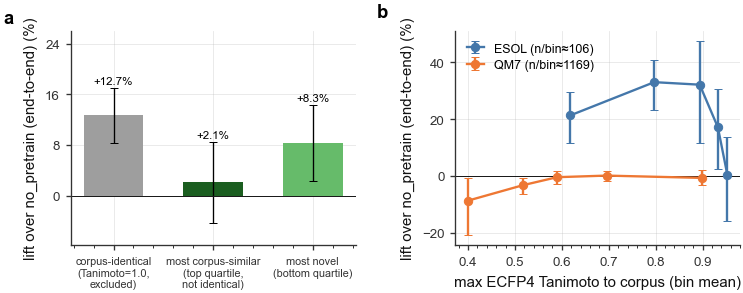

I1 ESOL (vs no_pretrain (end-to-end), excl. corpus-identical): most-similar +5.2% [-9.2,+16.0]   most-novel +23.7% [+15.0,+32.3]  (95% bootstrap CI)
I1 QM7 (vs no_pretrain (end-to-end), excl. corpus-identical): most-similar -1.0% [-3.1,+1.4]   most-novel -7.1% [-18.1,-1.5]  (95% bootstrap CI)
   ESOL corpus-identical group (Tani=1.0, excluded): +25.3% [+16.7,+33.5]  (n=383)
   QM7 corpus-identical group (Tani=1.0, excluded): +0.0% [-2.0,+2.2]  (n=1075)
Once corpus-identical molecules are removed, no task shows the lift concentrating on corpus-similar molecules (CIs overlap; if anything the novel quartile benefits more). The apparent top-bin advantage -- most visible for ESOL -- is carried by the corpus-identical group in (a): memorization of in-corpus structures, not genuine interpolation.



   contrast - the SAME comparison against the frozen baseline (why we switched):


   ESOL: most-similar +11.4%   most-novel +22.9%  (vs no_pretrain frozen)


   QM7: most-similar +2.2%   most-novel +4.8%  (vs no_pretrain frozen)


In [12]:
# ---------- I1 · memorization vs representation ----------
# Reviewer point (Note C): the top-Tanimoto bin could mix interpolation with outright memorization,
# because molecules IDENTICAL to a corpus molecule sit in that bin by construction. This is real and
# material for ESOL -- 41.9% of ESOL eval molecules are ECFP4-identical (Tanimoto=1.0) to a corpus
# molecule (QM7 only 15.7%; its median max-Tanimoto is 0.63, so QM7 is the clean control). The number
# that matters is fingerprint-identity, NOT the literal exact-match rate (1.3% ESOL / 1.9% QM7): Fig I1
# BINS on ECFP4 Tanimoto, so what saturates the top bin is fingerprint identity, not SMILES identity.
# We defuse the circularity two ways:
#   (1) similarity is the TRUE max ECFP4 Tanimoto to the FULL 12M corpus (full_corpus_similarity_i1.csv),
#       not the old 500k-subsample lower bound; and
#   (2) corpus-IDENTICAL molecules (ECFP4 Tanimoto = 1.0, or a literal isomeric-canonical match) are
#       REMOVED from the similarity bins and reported as their own bar. Near-duplicates (0.95<=T<1.0 --
#       salt/tautomer/stereo variants) are DISTINCT inputs to the model, so they stay in the trend as
#       the genuine interpolation regime; excluding them too does not change the conclusion.
# The salt-stripped "73%" overlap is an artifact (toluene/pyridine as the largest fragment of unrelated
# PubChem mixtures) and is deliberately NOT used.
DEDUP=Path("analysis/dedup_i1")
TANI=DEDUP/"full_corpus_similarity_i1.csv"        # true max Tanimoto to the full 12M corpus
EXACT=DEDUP/"exact_match_per_molecule.csv"        # literal isomeric-canonical corpus match
IDENTICAL_THR=0.99999                             # ECFP4 Tanimoto = 1.0 => corpus-identical (the circularity)
I1_MODEL=f"unsup_{MATCHED_BUDGET}"
# BASELINE CHOICE IS THE WHOLE POINT OF THIS PANEL.
# Lift over the FROZEN random encoder is close to trivial: that baseline cannot adapt to the task
# at all, so almost any pretraining clears it and the resulting "+34% on ESOL" says more about the
# baseline than about pretraining. The honest comparator is the random-init encoder FINE-TUNED
# end-to-end -- what a practitioner would actually do INSTEAD of pretraining. Lift over that is
# what decides whether the MLM stage buys anything, and it may well be ~0.
I1_BASELINES={"no_pretrain_e2e":["e2e_random_00","e2e_random_01","e2e_random_02"],
              "no_pretrain"    :["random_baseline_00","random_baseline_01","random_baseline_02"]}
I1_BASE_KEY="no_pretrain_e2e"          # primary; the frozen one is printed only as contrast
I1_TASKS=[t for t in ("ESOL","QM7") if t in TASKS]

def _preds(run):
    # per-molecule predictions exist only for the CV evaluation, so BOTH the model and its
    # baselines are read from CV here -- same scheme on both sides of the comparison.
    p=DATA_ROOT/"climb_v2_phase2"/run/"moleculenet_cv"/"test_predictions.csv"
    if not p.exists(): return None
    d=pd.read_csv(p)
    return (d.groupby(["dataset","raw_smiles"],as_index=False)
              .agg(y_true=("y_true","first"),y_pred=("y_pred","mean")))

def _base_preds(base_key):
    """Mean prediction across the baseline's replicates, or None if none are scored yet."""
    bs=[b for b in (_preds(r) for r in I1_BASELINES[base_key]) if b is not None]
    if not bs: return None
    return (pd.concat(bs).groupby(["dataset","raw_smiles"],as_index=False)
              .agg(y_true=("y_true","first"),y_pred=("y_pred","mean")))

def _simframe():
    """Full-corpus similarity + a `memorized` flag (exact match OR fingerprint near-dup >= 0.95)."""
    if not TANI.exists(): return None
    s=pd.read_csv(TANI).rename(columns={"max_tanimoto_to_corpus_full":"max_tanimoto_to_corpus"})
    if EXACT.exists():
        e=pd.read_csv(EXACT)[["raw_smiles","dataset","exact_nosalt"]]
        s=s.merge(e,on=["raw_smiles","dataset"],how="left")
    s["exact_nosalt"]=s.get("exact_nosalt",0)
    s["exact_nosalt"]=s.exact_nosalt.fillna(0).astype(int)
    # "memorized" here == corpus-IDENTICAL (ECFP4 Tanimoto = 1.0, or a literal match). Near-dups
    # (0.95<=T<1.0) are deliberately NOT flagged -- they are distinct inputs and stay in the trend.
    s["memorized"]=(s.exact_nosalt==1)|(s.max_tanimoto_to_corpus>=IDENTICAL_THR)
    return s
_SIM=_simframe()

def _lift_rmse(se_m,se_b):
    rm,rb=np.sqrt(np.mean(se_m)),np.sqrt(np.mean(se_b))
    return np.nan if (not np.isfinite(rb) or rb==0) else 100*(rb-rm)/rb

def _merged(task,base_key):
    """model + baseline + full-corpus similarity, with squared errors and the memorized flag."""
    if _SIM is None: return None
    mod=_preds(I1_MODEL); base=_base_preds(base_key)
    if mod is None or base is None: return None
    m=mod[mod.dataset==task].merge(base[base.dataset==task],on=["dataset","raw_smiles"],
                                   suffixes=("_m","_b"))
    m=m.merge(_SIM[_SIM.dataset==task][["raw_smiles","max_tanimoto_to_corpus","memorized"]],
              on="raw_smiles",how="inner")
    if len(m)<50: return None
    m["se_m"]=(m.y_pred_m-m.y_true_m)**2; m["se_b"]=(m.y_pred_b-m.y_true_b)**2
    return m

def _boot_ci(se_m,se_b,nboot,seed):
    pt=_lift_rmse(se_m,se_b)
    if not np.isfinite(pt): return None
    rng=np.random.default_rng(seed)
    idx=rng.integers(0,len(se_m),size=(nboot,len(se_m)))
    boot=np.array([_lift_rmse(se_m[i],se_b[i]) for i in idx]); boot=boot[np.isfinite(boot)]
    lo,hi=(np.percentile(boot,[2.5,97.5]) if len(boot) else (np.nan,np.nan))
    return pt,lo,hi

def binned_lift(task,base_key=None,nbins=5,nboot=400,seed=0):
    """-> (centres, lift%, lo, hi, n_per_bin) over the NON-memorized (not-in-corpus) molecules."""
    base_key=base_key or I1_BASE_KEY
    m=_merged(task,base_key)
    if m is None: return (None,)*5
    m=m[~m.memorized]                      # corpus matches are removed from the trend, reported apart
    if len(m)<50: return (None,)*5
    edges=np.unique(m.max_tanimoto_to_corpus.quantile(np.linspace(0,1,nbins+1)).values)
    if len(edges)<3: return (None,)*5
    edges[0]-=1e-9
    m=m.assign(bin=pd.cut(m.max_tanimoto_to_corpus,bins=edges,labels=False,include_lowest=True))
    xs,ys,los,his,ns=[],[],[],[],[]
    for b in range(len(edges)-1):
        s=m[m.bin==b]
        if len(s)<15: continue
        ci=_boot_ci(s.se_m.values,s.se_b.values,nboot,seed)
        if ci is None: continue
        pt,lo,hi=ci
        xs.append(float(s.max_tanimoto_to_corpus.mean())); ys.append(pt)
        los.append(lo); his.append(hi); ns.append(int(len(s)))
    return xs,ys,los,his,ns

def quartile_lift(task,base_key=None):
    """(most-similar, most-novel) lift% with bootstrap CIs, from the outer quartiles (non-memorized)."""
    xs,ys,lo,hi,_=binned_lift(task,base_key,nbins=4)
    if not xs or len(ys)<4: return None
    return (ys[-1],lo[-1],hi[-1]),(ys[0],lo[0],hi[0])

def memorized_lift(task,base_key=None,nboot=400,seed=1):
    """Lift% on the EXCLUDED corpus-match group (exact or Tanimoto>=0.95), for a side-by-side bar."""
    base_key=base_key or I1_BASE_KEY
    m=_merged(task,base_key)
    if m is None: return None
    s=m[m.memorized]
    if len(s)<15: return None
    ci=_boot_ci(s.se_m.values,s.se_b.values,nboot,seed)
    return None if ci is None else (ci[0],ci[1],ci[2],int(len(s)))

_I1_BASE_LABEL={"no_pretrain_e2e":"no_pretrain (end-to-end)","no_pretrain":"no_pretrain (frozen)"}
_I1_HAVE=_base_preds(I1_BASE_KEY) is not None
_I1_NEED=("needs e2e_random_0*/moleculenet_cv\n(E1 end-to-end wave still running)"
          if not _I1_HAVE else "needs full_corpus_similarity_i1.csv")

# Height + bottom margin reserve room for the caption INSIDE the canvas; at negative figure
# coords it only clears in the exported PNG (bbox="tight" grows it), not in the inline render.
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(STYLE["col2"],3.3))
pairs=[(t,v) for t,v in ((t,quartile_lift(t)) for t in I1_TASKS) if v]
mpairs=[(t,v) for t,v in ((t,memorized_lift(t)) for t in I1_TASKS) if v]
def _agg(getter,items):                                       # mean over tasks + combined SE from CIs
    trips=[getter(v) for _,v in items]                        # each getter(v) is a (pt,lo,hi) triple
    val=float(np.mean([t[0] for t in trips]))
    se=float(np.sqrt(np.sum([((t[2]-t[1])/2/len(trips))**2 for t in trips])))
    return val,se
if pairs:
    sim,se_s=_agg(lambda v:v[0],pairs); nov,se_n=_agg(lambda v:v[1],pairs)
    bars=[]                                                   # left -> right = MORE -> LESS similar
    if mpairs:                                                 # corpus-identical (Tani=1.0) is the MOST
        mem,se_m=_agg(lambda v:v,mpairs)                       # similar, so it leads; it is excluded from
        bars.append(("corpus-identical\n(Tanimoto=1.0,\nexcluded)",mem,se_m,"#9e9e9e"))  # the trend though
    bars+=[("most corpus-similar\n(top quartile,\nnot identical)",sim,se_s,"#1b5e20"),
           ("most novel\n(bottom quartile)",nov,se_n,"#66bb6a")]
    xpos=list(range(len(bars)))
    ax0.bar(xpos,[b[1] for b in bars],color=[b[3] for b in bars],width=0.6,
            yerr=[b[2] for b in bars],capsize=STYLE["cap_size"],error_kw=dict(lw=STYLE["lw_thin"]))
    for xi,b in zip(xpos,bars):
        ax0.text(xi,b[1]+b[2]+0.6,f"{b[1]:+.1f}%",ha="center",fontsize=STYLE["fs_annot"])
    ax0.axhline(0,color=PALETTE["black"],lw=0.6)
    _vals=[b[1] for b in bars]; _errs=[b[2] for b in bars]
    lo_,hi_=min(0,*(v-e for v,e in zip(_vals,_errs))),max(0,*(v+e for v,e in zip(_vals,_errs)))
    ax0.set_ylim(lo_-abs(lo_)*0.35-2,hi_+abs(hi_)*0.35+3)
    ax0.set_xticks(xpos); ax0.set_xticklabels([b[0] for b in bars],fontsize=STYLE["fs_annot"]-0.5)
else:
    ax0.set_ylim(-5,15); no_data_watermark(ax0,_I1_NEED); ax0.set_xticks([])
_ylab=f"lift over {_I1_BASE_LABEL[I1_BASE_KEY]} (%)"
ax0.set_ylabel(_ylab); label_all_yticks(ax0); panel_tag(ax0,"a",dx=-0.20)

col={"ESOL":PALETTE["blue"],"QM7":PALETTE["orange"]}; drew=False
for t in I1_TASKS:
    xs,ys,lo,hi,nn=binned_lift(t)
    if not xs: continue
    drew=True
    err=np.vstack([np.array(ys)-np.array(lo),np.array(hi)-np.array(ys)])
    ax1.errorbar(xs,ys,yerr=err,color=col.get(t,PALETTE["grey"]),marker="o",lw=STYLE["lw"],
                 capsize=STYLE["cap_size"],label=f"{t} (n/bin≈{int(np.median(nn))})")
if drew:
    ax1.axhline(0,color=PALETTE["black"],lw=0.6)
    ax1.legend(loc="best",fontsize=STYLE["fs_legend"])
else:
    ax1.set_ylim(-5,15); no_data_watermark(ax1,_I1_NEED)
ax1.set_xlabel("max ECFP4 Tanimoto to corpus (bin mean)")
ax1.set_ylabel(_ylab); label_all_yticks(ax1); panel_tag(ax1,"b",dx=-0.235,dy=1.05)

_suptitle(fig, "Fig I1 - memorization or representation? Who benefits from MLM pretraining",
             fontsize=STYLE["fs_title"],y=1.04)
fig.subplots_adjust(top=0.88,bottom=0.34,wspace=0.35)
_caption(fig, 0.5,0.02,f"baseline = {_I1_BASE_LABEL[I1_BASE_KEY]}, pooled 5-fold CV, regression tasks "
         "only. Similarity = TRUE max ECFP4 Tanimoto to the full 12M corpus. Corpus-IDENTICAL molecules "
         "(ECFP4 Tanimoto = 1.0; 41.9% of ESOL, 15.7% of QM7) are excluded from the bins and shown "
         "separately in (a); near-duplicates (0.95≤T<1.0) are kept as the interpolation regime. The trend "
         "is over molecules that are NOT fingerprint-identical to any corpus molecule; the conclusion is "
         "unchanged if the near-dup band is also excluded.",
         ha="center",va="top",fontsize=STYLE["fs_annot"],color="#555")
save_fig(fig,"figI1_memorization_vs_representation"); plt.show()

for t,v in pairs:
    print(f"I1 {t} (vs {_I1_BASE_LABEL[I1_BASE_KEY]}, excl. corpus-identical): most-similar {v[0][0]:+.1f}% "
          f"[{v[0][1]:+.1f},{v[0][2]:+.1f}]   most-novel {v[1][0]:+.1f}% "
          f"[{v[1][1]:+.1f},{v[1][2]:+.1f}]  (95% bootstrap CI)")
for t,v in mpairs:
    print(f"   {t} corpus-identical group (Tani=1.0, excluded): {v[0]:+.1f}% [{v[1]:+.1f},{v[2]:+.1f}]  (n={v[3]})")
if pairs:
    # The verdict is DERIVED, not asserted. The previous version printed "overlapping CIs => no
    # evidence" unconditionally, so it would have claimed that even when the intervals separated.
    _sep=[t for t,v in pairs if v[0][1]>v[1][2] or v[1][1]>v[0][2]]
    if _sep:
        print(f"Non-overlapping CIs on {', '.join(_sep)} => even among non-identical molecules the gain "
              f"DOES depend on corpus similarity there.")
    else:
        print("Once corpus-identical molecules are removed, no task shows the lift concentrating on "
              "corpus-similar molecules (CIs overlap; if anything the novel quartile benefits more). The "
              "apparent top-bin advantage -- most visible for ESOL -- is carried by the corpus-identical "
              "group in (a): memorization of in-corpus structures, not genuine interpolation.")
    # Same analysis against the weak frozen baseline, printed for contrast so the effect of the
    # baseline choice on the headline number is visible rather than argued about.
    if _base_preds("no_pretrain") is not None:
        print("\n   contrast - the SAME comparison against the frozen baseline (why we switched):")
        for t in I1_TASKS:
            v=quartile_lift(t,"no_pretrain")
            if v: print(f"   {t}: most-similar {v[0][0]:+.1f}%   most-novel {v[1][0]:+.1f}%  "
                        f"(vs no_pretrain frozen)")
else:
    print(f"I1: no data yet. Baseline is {_I1_BASE_LABEL[I1_BASE_KEY]}, whose CV predictions "
          f"({', '.join(I1_BASELINES[I1_BASE_KEY])}) land with the E1 end-to-end wave.")


## Figures C1J1 + I1 fused — one stacked 5-panel figure

The three C1J1 subfigures (**a**, **b**, **c**) and the two I1 subfigures (**d**, **e**) assembled
into a single left-aligned column: **a + b** on top (which SFT-label type helps, and the
family→task transfer matrix), **c** in the middle row (does lift track chemical similarity?), and
**d + e** at the bottom (does the MLM gain concentrate on corpus-similar molecules?).

It **reuses the data the two cells above already computed** rather than recomputing anything, so
the fused panel is identical to the standalone figures by construction and cannot drift from them.
It therefore must run after both — the standalone C1J1 and I1 cells stay as the source of truth and
the QA view.


saved figC1J1_I1_combined


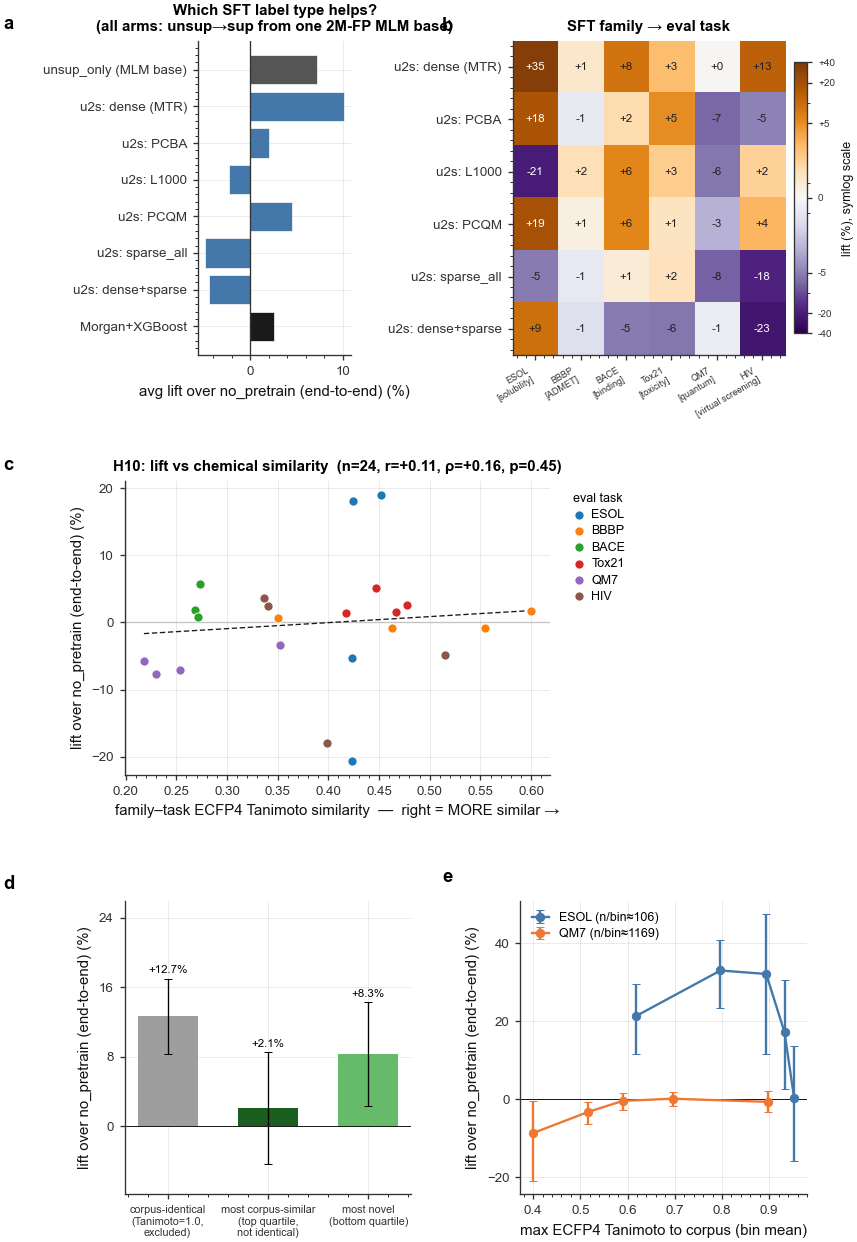

combined C1J1+I1 panel: a–c reuse the C1J1 cell's data, d–e reuse the I1 cell's data -> identical to the standalone figures by construction.


In [13]:
# ---------- C1J1 + I1 fused · one stacked 5-panel figure ----------
# Re-draws the five subfigures already built above -- (a,b,c) from the C1J1 cell and (d,e) from the
# I1 cell -- into one stacked, left-aligned figure for the paper. It deliberately REUSES the data
# those cells computed (avg, H, _norm/_vmax, MAT_ROWS, pts + X/Y/TK/tcol/a/b/r/rho/p for C1J1;
# pairs, sim/nov/se_s/se_n, mpairs/mem/se_m, binned_lift for I1; the H10 fit line is recomputed from
# X/Y because C1J1's global `a` is later reused as a loop variable) instead of recomputing, so
# this panel can never
# disagree with the standalone figures. It MUST run after both of them.
#   row 1:  a  (mean lift per SFT arm)        |  b  (SFT-family -> eval-task transfer matrix)
#   row 2:  c  (H10: lift vs chemical similarity)             [legend sits in the freed right space]
#   row 3:  d  (I1 quartile lift)             |  e  (I1 lift vs corpus similarity)
figF=plt.figure(figsize=(STYLE["col2"],10.8))
_outer=figF.add_gridspec(3,1,height_ratios=[1.05,0.98,0.98],hspace=0.42)
_r0=_outer[0].subgridspec(1,2,width_ratios=[1,1.30],wspace=0.62)
axA=figF.add_subplot(_r0[0]); axB=figF.add_subplot(_r0[1])
_r1=_outer[1].subgridspec(1,2,width_ratios=[1.75,1.0],wspace=0.04)
axC=figF.add_subplot(_r1[0])                    # legend overflows to the right, into the empty col
_r2=_outer[2].subgridspec(1,2,width_ratios=[1,1],wspace=0.38)
axD=figF.add_subplot(_r2[0]); axE=figF.add_subplot(_r2[1])

# ----- (a) mean lift per arm (C1J1 data) -----
_cols=["#555555" if a.startswith("unsup_only") else
       (PALETTE["black"] if a=="Morgan+XGBoost" else PALETTE["blue"]) for a in ARM_ORDER]
axA.barh(range(len(ARM_ORDER)),avg.values,color=_cols,edgecolor="white",lw=0.4)
axA.axvline(0,color="#333",lw=0.8)
axA.set_yticks(range(len(ARM_ORDER))); axA.set_yticklabels(ARM_ORDER); axA.invert_yaxis()
axA.set_xlabel(f"avg lift over {C1J1_FLOOR_LABEL} (%)")
axA.set_title("Which SFT label type helps?\n(all arms: unsup→sup from one 2M-FP MLM base)",pad=6)

# ----- (b) SFT-family transfer matrix (C1J1 data) -----
_im=axB.imshow(H.values,cmap="PuOr_r",norm=_norm,aspect="auto")
axB.set_xticks(range(len(CORE_TASKS)))
axB.set_xticklabels([f'{TASKS[t]["pretty"]}\n[{TASKS[t]["domain"]}]' for t in CORE_TASKS],
                    fontsize=STYLE["fs_annot"]-1.5,rotation=30,ha="right")
axB.set_yticks(range(len(MAT_ROWS))); axB.set_yticklabels(MAT_ROWS); axB.grid(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v=H.values[i,j]
        if np.isfinite(v):
            axB.text(j,i,f"{v:+.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],
                     color="white" if abs(v)>14 else "#222")
_cbt=[t for t in (-_vmax,-20,-5,0,5,20,_vmax) if abs(t)<=_vmax]
_cb=figF.colorbar(_im,ax=axB,fraction=0.046,pad=0.03,ticks=_cbt)
_cb.ax.yaxis.set_major_formatter(ticker.FixedFormatter([f"{t:+.0f}".replace("+0","0") for t in _cbt]))
_cb.set_label("lift (%), symlog scale",fontsize=STYLE["fs_legend"])
_cb.ax.tick_params(labelsize=STYLE["fs_annot"]-1)
axB.set_title("SFT family → eval task",pad=6); panel_tag(axB,"b",dx=-0.22)

# ----- (c) H10: lift vs chemical similarity (C1J1 data) -----
if len(pts)>=4:
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        _m=[k==t for k in TK]
        axC.scatter(X[_m],Y[_m],s=30,color=tcol[t],edgecolor="white",lw=0.5,zorder=3,
                    label=TASKS[t]["pretty"])
    # recompute the fit locally: the C1J1 cell's global `a` (polyfit intercept) is later
    # clobbered to a string by its `for a in ARM_ORDER` print loop, so don't lean on it here.
    _b,_a=np.polyfit(X,Y,1); _xs=np.linspace(X.min(),X.max(),50)
    axC.plot(_xs,_a+_b*_xs,color=PALETTE["black"],lw=STYLE["lw_thin"],ls=(0,(4,2)),zorder=2)
    axC.axhline(0,color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
    axC.set_xlabel("family–task ECFP4 Tanimoto similarity  —  right = MORE similar →")
    axC.set_ylabel(f"lift over {C1J1_FLOOR_LABEL} (%)")
    axC.set_title(f"H10: lift vs chemical similarity  (n={len(pts)}, "
                  f"r={r:+.2f}, ρ={rho:+.2f}, p={p:.2f})",pad=6)
    axC.legend(title="eval task",loc="upper left",bbox_to_anchor=(1.02,1.0),frameon=False,
               fontsize=STYLE["fs_legend"],title_fontsize=STYLE["fs_legend"],handletextpad=0.3)
    label_all_yticks(axC)
else:
    no_data_watermark(axC,"run scripts/compute_family_task_similarity.py")
    axC.set_xlabel("family–task Tanimoto similarity  —  right = MORE similar →")
    axC.set_ylabel(f"lift over {C1J1_FLOOR_LABEL} (%)")

# ----- (d) I1 quartile lift (non-memorized) + the excluded corpus-match group (I1 data) -----
_ylabI=f"lift over {_I1_BASE_LABEL[I1_BASE_KEY]} (%)"
if pairs:
    _barsD=[]                                                 # left -> right = MORE -> LESS similar
    if mpairs: _barsD.append(("corpus-identical\n(Tanimoto=1.0,\nexcluded)",mem,se_m,"#9e9e9e"))
    _barsD+=[("most corpus-similar\n(top quartile,\nnot identical)",sim,se_s,"#1b5e20"),
             ("most novel\n(bottom quartile)",nov,se_n,"#66bb6a")]
    _xpD=list(range(len(_barsD)))
    axD.bar(_xpD,[b[1] for b in _barsD],color=[b[3] for b in _barsD],width=0.6,
            yerr=[b[2] for b in _barsD],capsize=STYLE["cap_size"],error_kw=dict(lw=STYLE["lw_thin"]))
    for _xi,_b in zip(_xpD,_barsD):
        axD.text(_xi,_b[1]+_b[2]+0.6,f"{_b[1]:+.1f}%",ha="center",fontsize=STYLE["fs_annot"])
    axD.axhline(0,color=PALETTE["black"],lw=0.6)
    _dv=[b[1] for b in _barsD]; _de=[b[2] for b in _barsD]
    _lo,_hi=min(0,*(v-e for v,e in zip(_dv,_de))),max(0,*(v+e for v,e in zip(_dv,_de)))
    axD.set_ylim(_lo-abs(_lo)*0.35-2,_hi+abs(_hi)*0.35+3)
    axD.set_xticks(_xpD); axD.set_xticklabels([b[0] for b in _barsD],fontsize=STYLE["fs_annot"]-0.5)
else:
    axD.set_ylim(-5,15); no_data_watermark(axD,_I1_NEED); axD.set_xticks([])
axD.set_ylabel(_ylabI); label_all_yticks(axD)

# ----- (e) I1 lift vs corpus similarity (I1 data) -----
_drew=False
for t in I1_TASKS:
    _xs2,_ys2,_lo2,_hi2,_nn2=binned_lift(t)
    if not _xs2: continue
    _drew=True
    _err=np.vstack([np.array(_ys2)-np.array(_lo2),np.array(_hi2)-np.array(_ys2)])
    axE.errorbar(_xs2,_ys2,yerr=_err,color=col.get(t,PALETTE["grey"]),marker="o",lw=STYLE["lw"],
                 capsize=STYLE["cap_size"],label=f"{t} (n/bin≈{int(np.median(_nn2))})")
if _drew:
    axE.axhline(0,color=PALETTE["black"],lw=0.6); axE.legend(loc="best",fontsize=STYLE["fs_legend"])
else:
    axE.set_ylim(-5,15); no_data_watermark(axE,_I1_NEED)
axE.set_xlabel("max ECFP4 Tanimoto to corpus (bin mean)")
axE.set_ylabel(_ylabI); label_all_yticks(axE); panel_tag(axE,"e",dx=-0.235,dy=1.05)

_suptitle(figF, "Fig C1J1+I1 — supervised-label transfer (a–c) and who benefits from MLM "
              "pretraining (d–e)",fontsize=STYLE["fs_title"],y=0.995)
figF.subplots_adjust(left=0.155,right=0.945,top=0.945,bottom=0.055)
# Left-align the three left-column panels. Panel a is a horizontal bar chart whose long arm-name
# labels overhang further left than c/d's y-axis labels, so on a tight-cropped export a reads as
# flush-left while c/d sit indented. Indent a's axes so its label block lands in the same left band,
# then stack the a/c/d tags in one flush-left column at a shared figure-x.
_shift=0.085
_pa=axA.get_position(); axA.set_position([_pa.x0+_shift,_pa.y0,_pa.width-_shift,_pa.height])
for _ax,_t in [(axA,"a"),(axC,"c"),(axD,"d")]:
    figF.text(0.015,_ax.get_position().y1+0.006,_t,fontsize=STYLE["fs_panel_tag"],
              fontweight="bold",va="bottom",ha="left")
save_fig(figF,"figC1J1_I1_combined"); plt.show()
print("combined C1J1+I1 panel: a–c reuse the C1J1 cell's data, d–e reuse the I1 cell's data "
      "-> identical to the standalone figures by construction.")


## H1 · Does SMILES enumeration beat canonical repetition?

Beyond one epoch a model must re-see molecules. Enumeration re-shows each molecule under a
*different* valid SMILES string; canonical re-shows the identical string. If enumeration were
meaningful augmentation rather than noise, its curve should separate as the unique-molecule
fraction shrinks and repetition rises.

saved figH1_canonical_vs_enumerated


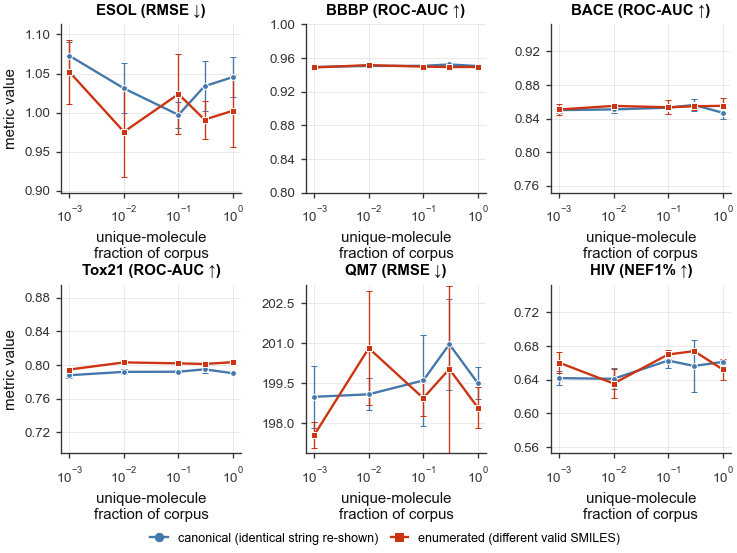

H1 scheme: pooled 5-fold scaffold CV · 3 pretraining-seed replicates (error bars = ±1 sd across seeds) · all six tasks incl. HIV
H1 enumerated minus canonical (positive = enumeration better), by unique-molecule fraction:
   frac=0.001  mean relative change +1.07%  (n=6)
   frac=0.01   mean relative change +0.94%  (n=6)
   frac=0.1    mean relative change -0.01%  (n=6)
   frac=0.3    mean relative change +1.26%  (n=6)
   frac=1.0    mean relative change +0.96%  (n=6)


In [14]:
# ---------- H1 · canonical vs enumerated SMILES (5-fold CV, 3 pretraining-seed replicates) ----------
# The round-1 wave (climb_v2) was hold-out only, had no HIV, and its encoders were never saved, so
# it could not be re-scored. The RETRAINED wave `climb_v2_h1` fixes all three: pooled 5-fold
# scaffold CV, all six tasks incl. HIV, and THREE pretraining-seed replicates per (mode, fraction)
# -- so H1 finally has an error bar (spread across seeds) instead of a single noisy hold-out draw.
H1_WAVE="climb_v2_h1"; H1_SUB="moleculenet_cv"; H1_SEEDS=[0,1,2]
H1_YPAD=0.02          # small fixed pad; the min-span below is what stops tiny gaps being oversold
H1_MIN_SPAN=0.20      # no panel may make a <0.2 difference fill its whole height
FRACS=[("frac0p001",0.001),("frac0p01",0.01),("frac0p1",0.1),("frac0p3",0.3),("fracfull",1.0)]

def _h1_seed_vals(mode,fk,task):
    """(mean, sd) of the task metric across the pretraining-seed replicates, or (nan, nan)."""
    sk=TASKS[task].get("suite_key",task); vs=[]
    for s in H1_SEEDS:
        d=load_suite(DATA_ROOT/H1_WAVE/f"scaling_{mode}_{fk}_s{s}",sub=H1_SUB)
        if d and (sk,"mean") in d: vs.append(d[(sk,"mean")])
    if not vs: return (np.nan,np.nan)
    return (float(np.mean(vs)), float(np.std(vs,ddof=1)) if len(vs)>1 else 0.0)

# Six panels in a single row overlapped titles, tick labels and axis labels. 3x2 matches A1.
ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.35*nrow)); axes=axes.ravel()
for ax,task in zip(axes,CORE_TASKS):
    drew=False; _band=[]
    for mode,c,mk in [("canonical",PALETTE["blue"],"o"),("enumerated",PALETTE["red"],"s")]:
        xs,ys,es=[],[],[]
        for fk,fv in FRACS:
            m,sd=_h1_seed_vals(mode,fk,task)
            if np.isfinite(m): xs.append(fv); ys.append(m); es.append(sd)
        if xs:
            drew=True
            ax.errorbar(xs,ys,yerr=es,color=c,marker=mk,ms=3.5,lw=STYLE["lw"],mec="white",
                        capsize=2,elinewidth=0.8)
            _band+=[y-e for y,e in zip(ys,es)]+[y+e for y,e in zip(ys,es)]
    # Enforce a floor on the visible range: auto-scaling made Tox21/BBBP span ~0.02 of ROC-AUC --
    # differences well inside the seed spread, stretched to fill the panel. A fixed pad plus a
    # minimum span means a difference this small is DRAWN as small.
    if drew:
        _lo,_hi=min(_band)-H1_YPAD,max(_band)+H1_YPAD
        if (_hi-_lo)<H1_MIN_SPAN:
            _mid=(_lo+_hi)/2; _lo,_hi=_mid-H1_MIN_SPAN/2,_mid+H1_MIN_SPAN/2
        if "AUC" in TASKS[task]["metric"] and _hi>1.0:   # AUC ceiling: keep the span, drop top to 1.0
            _lo-=_hi-1.0; _hi=1.0
        ax.set_ylim(_lo,_hi)
    ax.set_xscale("log"); ax.set_title(ttitle(task,oneline=True),pad=6)
    ax.set_xlabel("unique-molecule\nfraction of corpus")
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
    label_all_yticks(ax)
    if not drew: no_data_watermark(ax,f"no {H1_WAVE} CV data")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")
handles=[plt.Line2D([],[],color=PALETTE["blue"],marker="o",label="canonical (identical string re-shown)"),
         plt.Line2D([],[],color=PALETTE["red"], marker="s",label="enumerated (different valid SMILES)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
_h1scheme=(f"pooled 5-fold scaffold CV · {len(H1_SEEDS)} pretraining-seed replicates "
           f"(error bars = ±1 sd across seeds) · all six tasks incl. HIV")
_suptitle(fig, "Fig H1 - does SMILES enumeration beat canonical repetition? (unsup_only)",
             fontsize=STYLE["fs_title"],y=1.06)
_caption(fig, 0.5,0.995,"\n".join(_tw.wrap(f"SCHEME: {_h1scheme}",110)),ha="center",va="top",
         fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.90,bottom=0.14,hspace=0.55,wspace=0.36)
save_fig(fig,"figH1_canonical_vs_enumerated"); plt.show()

print(f"H1 scheme: {_h1scheme}")
print("H1 enumerated minus canonical (positive = enumeration better), by unique-molecule fraction:")
for fk,fv in FRACS:
    d=[]
    for t in CORE_TASKS:
        cm,_=_h1_seed_vals("canonical",fk,t); em,_=_h1_seed_vals("enumerated",fk,t)
        if np.isfinite(cm) and np.isfinite(em): d.append(lift(em,t,cm))
    if d: print(f"   frac={fv:<6} mean relative change {100*np.nanmean(d):+.2f}%  (n={len(d)})")


## Figure inventory — which figures are FINAL, and which are still moving

"Can I write this number down?" gets one answer per figure, **computed** rather than remembered.
A figure is FINAL when every summary it reads came from the current `eval_v2` and nothing it plots
is still pending. `eval_v2` gained `<metric>_train` and HIV NEF1% on 2026-07-21; re-scoring the
*same* encoder with it moves a metric by up to 0.03, so an older summary is not merely old — it is
a different protocol, and a panel that mixes the two is comparing two scorers.

In [15]:
# ---------- inventory: is each exported figure FINAL, or still moving? ----------
EVAL_BUILD = pd.Timestamp("2026-07-21")   # the eval_v2 build every final figure must be scored by

def _sums(pattern,sub="moleculenet"):
    return [Path(q) for q in glob.glob(f"figure_data/{pattern}/{sub}/suite_summary.json")]

# what each figure actually reads off disk
FIG_SOURCES={
  "A1.a": _sums("climb_v2_phase2/*"),
  "A1.b": _sums("climb_v2_phase2/*","moleculenet_cv"),
  "A2.a": _sums("climb_v2_phase2/*","moleculenet_cv"),
  "A2.b": _sums("climb_v2_phase2/*","moleculenet_cv"),
  "B1p1": ([Path(LE_SUM)] if os.path.exists(LE_SUM) else []),
  # E1's frozen line is read per head seed straight from the phase-2 summaries, so its verdict
  # depends on those too -- not only on the cached eval_ceiling.csv.
  "E1"  : [q for q in (CEIL,CEIL_SUP) if q.exists()]
          +[q for r in ("random_baseline_00","unsup_2M","unsup_8M","unsup_24M",
                        f"skip_{E1_SUP_RECIPE}_2M",f"skip_{E1_SUP_RECIPE}_8M",f"skip_{E1_SUP_RECIPE}_24M")
              for q in _sums(f"climb_v2_phase2/{r}")],
  "B2"  : _sums("climb_v2_phase2/*"),
  "C1J1": _sums("climb_v2_ablation_dedup/*")+_sums("climb_v2_phase2/unsup_2M"),
  "I1"  : _sums("climb_v2_phase2/*","moleculenet_cv"),
  "H1"  : _sums("climb_v2/scaling_*"),
}
# blockers that are MISSING work rather than stale scoring
_missing_hiv=sorted(set(DF.run)-set(DF[DF.task=="HIV"].run))
_u2s_seeds=DF[(DF.regime=="unsup2sup")&(DF.budget_label==MATCHED_BUDGET)].seed.nunique()
_missing_hiv_cv=sorted(set(DF_CV.run)-set(DF_CV[DF_CV.task=="HIV"].run))
# Scheme-aware: the hold-out half of the E1 wave landed before the CV half, so a single _e2e flag
# computed from DF would clear A1.b/A2's blocker while their e2e bar is still absent.
_e2e   =len(DF[DF.regime=="no_pretrain_e2e"])
_e2e_cv=len(DF_CV[DF_CV.regime=="no_pretrain_e2e"])
BLOCKERS={
  "A1.a": ([f"{len(_missing_hiv)} runs lack HIV NEF1%"] if _missing_hiv else [])
        +([f"unsup→sup has {_u2s_seeds} pretraining seed: its error bar is head-seed only"]
          if _u2s_seeds<2 else [])
        +([] if _e2e else ["no_pretrain_end_to_end (E1) not run"]),
  "A1.b": ([f"{len(_missing_hiv_cv)} runs lack HIV in the CV eval"] if _missing_hiv_cv else [])
        +([] if _e2e_cv else ["no_pretrain_end_to_end has no CV eval yet "
                             "(only the hold-out half of the E1 wave has landed)"]),
  "A2.a": ([f"{len(_missing_hiv_cv)} runs lack HIV in the CV eval"] if _missing_hiv_cv else [])
        +([] if _e2e_cv else ["no_pretrain_end_to_end has no CV eval yet "
                             "(only the hold-out half of the E1 wave has landed)"])
        # Derived, not asserted: this was a hardcoded string that kept claiming a gap after the
        # runs had landed. A blocker that cannot clear itself is just a stale caption.
        +([] if len(glob.glob("figure_data/climb_v2_phase2/skip_dense_96M/moleculenet_cv/suite_summary.json")
                   +glob.glob("figure_data/climb_v2_phase2/u2s_*_from48M/moleculenet_cv/suite_summary.json"))>=6
           else ["96M rung / unsup→sup 48M rung still lack a CV eval"])
        +([] if glob.glob("figure_data/climb_v2_phase2/unsup_100M/moleculenet_cv/suite_summary.json")
           else ["~100M-molecule unsupervised rung not yet scored"]),
  "A2.b": ([f"{len(_missing_hiv_cv)} runs lack HIV in the CV eval"] if _missing_hiv_cv else [])
        +([] if _e2e_cv else ["no_pretrain_end_to_end has no CV eval yet "
                             "(only the hold-out half of the E1 wave has landed)"])
        +([] if glob.glob("figure_data/climb_v2_phase2/unsup_100M/moleculenet_cv/suite_summary.json")
           else ["~100M-molecule unsupervised rung not yet scored"]),
  "B2": ([] if _have_b2 else ["corrupt_mlm_8M / corrupt_mtr_8M still training"]),
  "E1": list(_E1_PENDING and [f"sup_only ladder not fine-tuned yet: {', '.join(_E1_PENDING)}"] or []),
  # A figure is not FINAL just because its files are consistent -- a declared arm with no runs is
  # a gap too. B1p1 carries no_pretrain_e2e in its legend as NOT RUN: the 4 frozen-probe arms are
  # final at the per-task fractions, but the end-to-end arm needs the ENCODER re-fine-tuned at each
  # of the 5 fractions (a separate sweep, peer compute session ~2.5h). The blocker clears when the
  # e2e rows are appended to LE_SUM, not when a file merely appears.
  "B1p1": ([] if ("e2e" in set(_led.arm)) else
           ["no_pretrain_end_to_end label-efficiency not run yet "
            "(end-to-end arm needs the encoder re-fine-tuned at each of the 5 per-task fractions)"]),
  "C1J1": ([] if len(glob.glob(f"figure_data/{ABL}/*/moleculenet_cv/suite_summary.json"))>=10 else
           [f"ablation-wave CV is "
            f"{len(glob.glob(f'figure_data/{ABL}/*/moleculenet_cv/suite_summary.json'))}/10 runs; "
            f"the panel is still on the single hold-out (113-204 test mols)"]),
  "H1"  : ([] if H1_SUB=="moleculenet_cv"
           else ["round-1 wave has NO CV eval and no saved encoders - retraining under way"]),
  "I1"  : ([] if _I1_HAVE else ["baseline is now no_pretrain_e2e; its CV predictions land with "
                                "the E1 wave"]),
}

FIGS=[("A1.a","figA1a_best_model_headline_holdout","which model performs best (8M, single scaffold hold-out)"),
      ("A1.b","figA1b_best_model_headline_cv","which model performs best (8M, pooled 5-fold scaffold CV)"),
      ("A2.a","figA2a_scaling_tokens","scaling in training tokens"),
      ("A2.b","figA2b_scaling_unique_molecules","scaling in unique molecules seen"),
      ("B1p1","figB1p1_label_efficiency_train_test","label-efficiency + fit/generalize mechanism"),
      ("E1","figE1_H5_eval_ceiling","H5: is the sup/unsup ordering a frozen-probe artifact?"),
      ("B2","figB2_corrupted_control"+("" if _have_b2 else "_PLACEHOLDER"),"corrupted-pretraining control"),
      ("C1J1","figC1J1_sft_family_transfer","SFT family: which helps, how much, does it track chemistry"),
      ("I1","figI1_memorization_vs_representation","memorization vs representation"),
      ("H1","figH1_canonical_vs_enumerated","canonical vs enumerated SMILES")]
out=Path(STYLE["outdir"]); final=[]
print(f"{'fig':<6} {'verdict':<12} {'exported':<44} {'files':<7} status")
for fid,name,what in FIGS:
    both=(out/f"{name}.png").exists() and (out/f"{name}.pdf").exists()
    srcs=[q for q in FIG_SOURCES.get(fid,[]) if q.exists()]
    old=[q for q in srcs if pd.Timestamp(q.stat().st_mtime,unit="s")<EVAL_BUILD]
    blk=list(BLOCKERS.get(fid,[]))
    # What disqualifies a figure is MIXING two scorers, not being scored by the older one. H1
    # compares canonical vs enumerated entirely within one round-1 wave: internally consistent,
    # so it is final even though it predates the current build. A1 mixing 07-19 and 07-22
    # summaries is not.
    stale = old if (old and len(old)<len(srcs)) else []
    if stale: blk.insert(0,f"MIXED scorers: {len(stale)}/{len(srcs)} summaries predate the rest")
    elif old: what += "  [scored by the pre-2026-07-21 eval_v2, but consistently so]"
    verdict="FINAL" if (both and not blk) else ("PROVISIONAL" if both else "NOT EXPORTED")
    if verdict=="FINAL": final.append(fid)
    print(f"{fid:<6} {verdict:<12} {name:<44} {'png+pdf' if both else 'MISSING':<7} "
          f"{'; '.join(blk) if blk else what}")
    for q in sorted(stale)[:3]:
        print(f"{'':<6} {'':<12}   stale: {'/'.join(q.parts[1:3])}")

print(f"\nFINAL - safe to quote: {', '.join(final) if final else '(none)'}")
prov=[f for f,_,_ in FIGS if f not in final]
if prov: print(f"PROVISIONAL - do NOT quote effect sizes yet: {', '.join(prov)}")
stray=sorted(p.name for p in out.glob("*") if p.stem not in {n for _,n,_ in FIGS})
print("stray files in figures_out (not one of the exported set):", stray or "none")

fig    verdict      exported                                     files   status
A1.a   FINAL        figA1a_best_model_headline_holdout           png+pdf which model performs best (8M, single scaffold hold-out)
A1.b   FINAL        figA1b_best_model_headline_cv                png+pdf which model performs best (8M, pooled 5-fold scaffold CV)
A2.a   FINAL        figA2a_scaling_tokens                        png+pdf scaling in training tokens
A2.b   FINAL        figA2b_scaling_unique_molecules              png+pdf scaling in unique molecules seen
B1p1   FINAL        figB1p1_label_efficiency_train_test          png+pdf label-efficiency + fit/generalize mechanism
E1     FINAL        figE1_H5_eval_ceiling                        png+pdf H5: is the sup/unsup ordering a frozen-probe artifact?
B2     FINAL        figB2_corrupted_control                      png+pdf corrupted-pretraining control
C1J1   FINAL        figC1J1_sft_family_transfer                  png+pdf SFT family: which helps, how muc

## Head ablation — FFN vs XGBoost on frozen CLIMB embeddings

Everywhere else in this notebook the downstream head is an MLP (FFN). This asks whether **XGBoost on
the same frozen embeddings** changes what those embeddings are worth — and, in particular, whether a
tree head lets CLIMB clear the Morgan+XGBoost anchors it otherwise loses to.

Same `eval_v2` harness, same pooled 5-fold scaffold CV, same `pool=mean` / z-score standardize as
every other run and as the two Morgan+XGBoost anchors — **only `--head` changes (`mlp` → `xgb`)**.
The XGBoost-on-embeddings runs are (re)generated by `scripts/run_head_ablation.sh` and committed
under `analysis/head_ablation/`; the FFN and Morgan rows are read from the production `figure_data`
runs (the FFN CLIMB numbers here **are** the A1.b numbers). The XGB encoder was re-run locally on
MPS, which differs from the production CUDA embeddings by ≤0.01 — far below any head effect, so read
the FFN↔XGB gap as the head, not the device.


In [16]:
# ---------- Head ablation · FFN vs XGBoost on frozen CLIMB embeddings ----------
# Only --head changes (mlp -> xgb); everything else (5-fold scaffold CV, pool=mean, zscore
# standardize) is the shared eval_v2 protocol. FFN + Morgan anchors are read from the production
# figure_data runs; XGBoost-on-embeddings from the committed analysis/head_ablation/ dir (generated
# by scripts/run_head_ablation.sh, encoder re-run on MPS -> <=0.01 device offset vs the FFN rows).
from pathlib import Path as _Path
HA_TASKS = [("ESOL", "RMSE", False), ("QM7", "RMSE", False), ("BBBP", "ROC-AUC", True),
            ("BACE", "ROC-AUC", True), ("Tox21", "ROC-AUC", True), ("HIV", "ROC-AUC", True)]
def _ha(src, task, suf="_MEAN"):
    p = _Path(src) / "moleculenet_cv" / "suite_summary.json"
    return json.loads(p.read_text()).get(task + suf) if p.exists() else None
_PH = DATA_ROOT / "climb_v2_phase2"; _HA = _Path("analysis/head_ablation")
# (featurizer, head, source dir). FFN + anchors live in figure_data; the two XGB-on-embeddings runs
# are committed with the repo so this table reproduces without a private data snapshot.
HA_ROWS = [("Morgan ECFP4",       "XGBoost", _PH / "ecfp4_anchor"),
           ("Morgan+desc",        "XGBoost", _PH / "fp_desc_anchor"),
           ("CLIMB unsup_only",   "FFN",     _PH / "unsup_8M"),
           ("CLIMB unsup_only",   "XGBoost", _HA / "unsup_8M_xgb"),
           ("CLIMB dense+sparse", "FFN",     _PH / "skip_dense_plus_sparse_8M"),
           ("CLIMB dense+sparse", "XGBoost", _HA / "skip_dense_plus_sparse_8M_xgb")]
_num = {(f, h): {t: _ha(s, t) for t, _, _ in HA_TASKS} for f, h, s in HA_ROWS}
for f, h, s in HA_ROWS:
    _num[(f, h)]["HIV_nef1"] = _ha(s, "HIV", "_nef1_MEAN")

_rows = []
for f, h, s in HA_ROWS:
    r = {"featurizer": f, "head": h}
    for t, m, hb in HA_TASKS:
        v = _num[(f, h)][t]; r[f"{t}({m[:3]}{'↑' if hb else '↓'})"] = f"{v:.3f}" if isinstance(v, (int, float)) else "n.d."
    v = _num[(f, h)]["HIV_nef1"]; r["HIV(NEF↑)"] = f"{v:.3f}" if isinstance(v, (int, float)) else "n.d."
    _rows.append(r)
HA = pd.DataFrame(_rows)
print("=" * 118)
print("Head ablation — FFN vs XGBoost on FROZEN embeddings (pooled 5-fold scaffold CV mean; only the head differs)")
print("=" * 118)
print(HA.to_string(index=False))
print("\nESOL/QM7 = RMSE (lower better); BBBP/BACE/Tox21/HIV = ROC-AUC (higher better); "
      "HIV(NEF↑) = NEF1%, A1's HIV ranking metric.")

# --- did swapping FFN -> XGBoost help, on the same embeddings? (signed toward 'better') ---
def _better_delta(xgb, ffn, hb):
    if not (isinstance(xgb, (int, float)) and isinstance(ffn, (int, float))): return None
    return (xgb - ffn) if hb else (ffn - xgb)     # + => XGBoost is better than the FFN
print("\nHead effect on the CLIMB encoders (XGBoost minus FFN, + = XGBoost better):")
for enc in ("CLIMB unsup_only", "CLIMB dense+sparse"):
    parts = []
    for t, m, hb in HA_TASKS:
        d = _better_delta(_num[(enc, "XGBoost")][t], _num[(enc, "FFN")][t], hb)
        if d is not None: parts.append(f"{t} {d:+.3f}")
    print(f"   {enc:20} " + "   ".join(parts))

# --- does XGBoost-on-embeddings let CLIMB beat the best Morgan anchor per task? ---
print("\nBest per task, and whether any CLIMB+XGBoost arm is the winner:")
for t, m, hb in HA_TASKS:
    best_lbl, best_v = None, None
    for f, h, s in HA_ROWS:
        v = _num[(f, h)][t]
        if not isinstance(v, (int, float)): continue
        if best_v is None or (v > best_v if hb else v < best_v): best_lbl, best_v = f"{f} + {h}", v
    print(f"   {t:6} best = {best_lbl:34} ({best_v:.3f})")


Head ablation — FFN vs XGBoost on FROZEN embeddings (pooled 5-fold scaffold CV mean; only the head differs)
        featurizer    head ESOL(RMS↓) QM7(RMS↓) BBBP(ROC↑) BACE(ROC↑) Tox21(ROC↑) HIV(ROC↑) HIV(NEF↑)
      Morgan ECFP4 XGBoost      1.452   215.909      0.864      0.871       0.773     0.797     0.680
       Morgan+desc XGBoost      0.720   187.241      0.903      0.867       0.825     0.816     0.713
  CLIMB unsup_only     FFN      1.013   199.578      0.954      0.869       0.799     0.779     0.682
  CLIMB unsup_only XGBoost      1.310   202.284      0.949      0.858       0.784     0.768     0.646
CLIMB dense+sparse     FFN      0.928   196.002      0.942      0.818       0.830     0.782     0.675
CLIMB dense+sparse XGBoost      0.945   197.656      0.944      0.827       0.826     0.775     0.639

ESOL/QM7 = RMSE (lower better); BBBP/BACE/Tox21/HIV = ROC-AUC (higher better); HIV(NEF↑) = NEF1%, A1's HIV ranking metric.

Head effect on the CLIMB encoders (XGBoost minus FFN,

## SI · Vocabulary-size scaling for unsupervised (MLM) pretraining

Wave `climb_v2_vocab` (README §7.2). One **MLM-only** encoder per tokenizer, all at the same **2M
forward passes**, same corpus and same eval harness as every other run. Two tokenizer families —
byte-level **BPE** (the main-paper family) and **Unigram-LM** — each trained at four *reachable,
distinct* vocabulary sizes (SMILES tokenization saturates, so the nominal targets collapse onto a
handful of actual sizes: BPE `261 / 1000 / 3000 / 12000`, Unigram `261 / 700 / 876 / 3000`; the
`unigram_1200` target resolved to 876). The x-axis is the **actual, measured** vocabulary, not the
target. Because the embedding table auto-sizes to the vocabulary, parameter count rises with vocab
(≈41.0M→47.1M): vocabulary size and embedding params are **confounded by construction** — disclosed,
not removed.

One combined figure **`figSV_vocab`** stacks the same data as two sub-panels (same data, two readouts):

- **(a)** one panel per task (ESOL, QM7, BBBP, BACE, Tox21, HIV-NEF1%), downstream frozen-probe metric
  vs actual vocab (log x), BPE vs Unigram, error bars = ±1 fold std.
- **(b)** a single full-width summary: the change from the character-level (vocab-261) baseline to each
  family's largest reachable vocab, expressed in units of that task's fold std, with a shaded ±1σ band.
  Markers inside the band are within evaluation noise.

**Finding (near-null — this is the result):** across the reachable SMILES vocab range, vocabulary size
moves the downstream CV score by **less than the fold-to-fold noise on almost every task**, and BPE ≈
Unigram at matched vocab. The character-level floor (vocab 261, no merges) is already competitive. The
only >~1σ move is **ESOL, where BPE degrades with vocab while Unigram does not** — one hedged sentence,
not a headline.

These are **CV-only** (all eight runs have the pooled 5-fold scaffold CV; none were given a single
hold-out headline pass, so a CV-only panel is apples-to-apples), **single-pretraining-seed** (seed 0,
unlike the 3-seed main arms), Lipophilicity excluded (blocklist), and HIV shown as **NEF1%** (its
virtual-screening readout). Error bars are the **across-fold** spread — the same quantity as every
other CV figure in this notebook, not head-seed or pretraining-seed variance.


saved figSV_vocab


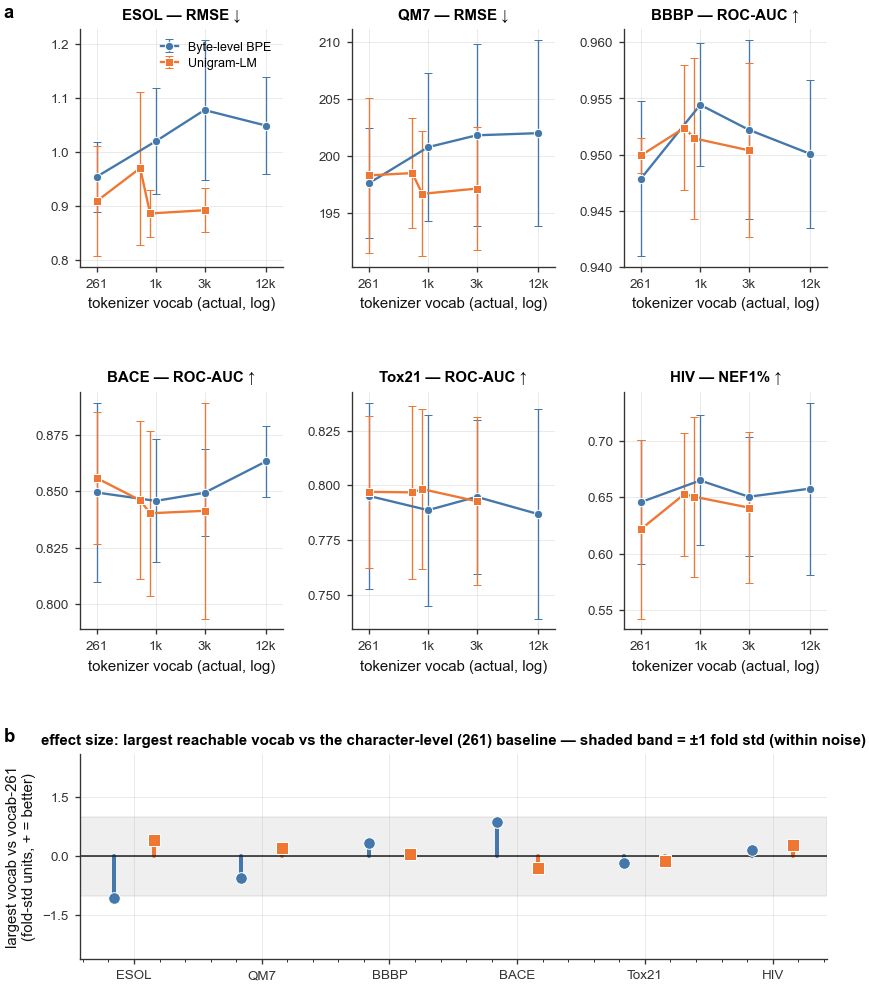


Vocabulary-size effect (largest reachable vocab vs vocab-261, in fold-std units; |.|<1 = within fold noise):
   Byte-level BPE ESOL -1.06σ   QM7 -0.54σ   BBBP +0.34σ   BACE +0.88σ   Tox21 -0.17σ   HIV +0.16σ
   Unigram-LM     ESOL +0.40σ   QM7 +0.21σ   BBBP +0.06σ   BACE -0.30σ   Tox21 -0.11σ   HIV +0.29σ
   (the only >1σ move is ESOL/BPE, which degrades as vocab grows while Unigram does not; everything else is within fold noise, and vocab-261 is already competitive.)


In [17]:
# ---------- SI · vocabulary-size scaling (wave climb_v2_vocab), on the 5-fold CV only ----------
# One MLM-only encoder per tokenizer at a matched 2M forward passes; the ONLY thing that moves is the
# tokenizer vocabulary (and, by construction, the embedding-param count that tracks it). Both panels
# read the tidy per-run CV summary the compute session shipped -- `mean`/`fold_std` are the mean and
# across-fold sd of the 3-head-seed-averaged prediction, i.e. the identical CV scheme used everywhere
# else in this notebook. x-axis is the ACTUAL (measured) vocab, not the nominal target.
_VOCAB = pd.read_csv(DATA_ROOT / "climb_v2_vocab" / "vocab_cv_summary.csv")
VOCAB_FAMILY = {                                   # BPE = main-paper family; Unigram = warm contrast
    "bpe":     dict(color=PALETTE["blue"],   marker="o", label="Byte-level BPE"),
    "unigram": dict(color=PALETTE["orange"], marker="s", label="Unigram-LM"),
}
# (task, metric-in-CSV, lower_is_better) -- HIV uses NEF1% (its virtual-screening readout), not ROC-AUC.
VOCAB_PANELS = [("ESOL", "rmse", True),  ("QM7", "rmse", True),  ("BBBP",  "roc_auc", False),
                ("BACE", "roc_auc", False), ("Tox21", "roc_auc", False), ("HIV", "nef1", False)]

def _vseries(family, task, metric):
    """(actual_vocab, mean, fold_std) sorted by vocab for one family/task/metric."""
    s = _VOCAB[(_VOCAB.family == family) & (_VOCAB.dataset == task) & (_VOCAB.metric == metric)]
    s = s.sort_values("actual_vocab")
    return s.actual_vocab.values.astype(float), s["mean"].values.astype(float), s.fold_std.values.astype(float)

def _vtitle(task, metric):
    arrow = "↓" if task in ("ESOL", "QM7") else "↑"
    pretty = {"rmse": "RMSE", "roc_auc": "ROC-AUC", "nef1": "NEF1%"}[metric]
    return f'{TASKS[task]["pretty"]} — {pretty} {arrow}'

# ----- one combined figure: (a) per-task scaling grid, (b) effect-size summary -----
# Stacked like figC1J1_I1_combined: rows 0-1 hold the six task panels (2x3), row 2 is the
# full-width effect-size summary. Both read the SAME data, so panel b can never disagree with a.
figV = plt.figure(figsize=(STYLE["col2"], 8.7))
_outer = figV.add_gridspec(3, 1, height_ratios=[1.0, 1.0, 0.86], hspace=0.55)
_g0 = _outer[0].subgridspec(1, 3, wspace=0.34); _g1 = _outer[1].subgridspec(1, 3, wspace=0.34)
_taxes = [figV.add_subplot(_g0[j]) for j in range(3)] + [figV.add_subplot(_g1[j]) for j in range(3)]
axE = figV.add_subplot(_outer[2])

# ----- (a) per-task metric vs actual vocab, BPE vs Unigram -----
for ax, (task, metric, lower) in zip(_taxes, VOCAB_PANELS):
    for fam, sty in VOCAB_FAMILY.items():
        x, y, e = _vseries(fam, task, metric)
        if not len(x): continue
        ax.errorbar(x, y, yerr=e, color=sty["color"], marker=sty["marker"], ms=STYLE["marker_size"],
                    lw=STYLE["lw"], capsize=STYLE["cap_size"], elinewidth=STYLE["lw_thin"], mec="white",
                    label=sty["label"], zorder=3)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(ticker.FixedLocator([261, 1000, 3000, 12000]))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter(["261", "1k", "3k", "12k"]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x", which="minor", bottom=False)
    ax.set_title(_vtitle(task, metric), pad=6); ax.set_xlabel("tokenizer vocab (actual, log)")
    ax.margins(x=0.10); label_all_yticks(ax)
_taxes[0].legend(loc="best", fontsize=STYLE["fs_legend"])

# ----- (b) largest-vocab change vs the vocab-261 baseline, in fold-std units -----
# One number per family/task: how far the LARGEST reachable vocab moves the metric away from the
# character-level (261) baseline, signed so + = better, divided by that task's fold std at the large
# vocab. |effect| < 1 (inside the shaded band) means "within evaluation noise".
_dodge = {"bpe": -0.16, "unigram": +0.16}
for fam, sty in VOCAB_FAMILY.items():
    for k, (task, metric, lower) in enumerate(VOCAB_PANELS):
        x, y, e = _vseries(fam, task, metric)
        if len(x) < 2: continue
        delta = (y[0] - y[-1]) if lower else (y[-1] - y[0])       # + = large vocab better than vocab-261
        denom = e[-1] if e[-1] > 0 else np.nan
        eff = delta / denom
        if not np.isfinite(eff): continue
        xp = k + _dodge[fam]
        axE.plot([xp, xp], [0, eff], color=sty["color"], lw=2.4, zorder=2, solid_capstyle="round")
        axE.plot([xp], [eff], color=sty["color"], marker=sty["marker"], ms=7, mec="white", zorder=3)
axE.axhspan(-1, 1, color="#888888", alpha=0.13, zorder=0)
axE.axhline(0, color=PALETTE["black"], lw=0.9)
axE.set_xticks(range(len(VOCAB_PANELS))); axE.set_xticklabels([p[0] for p in VOCAB_PANELS])
axE.set_ylabel("largest vocab vs vocab-261\n(fold-std units, + = better)")
axE.set_title("effect size: largest reachable vocab vs the character-level (261) baseline "
              "— shaded band = ±1 fold std (within noise)", pad=6)
axE.set_ylim(-2.6, 2.6); axE.margins(x=0.05); label_all_yticks(axE)

_suptitle(figV, "Fig SV - vocabulary size barely affects unsupervised (MLM) pretraining "
                "(frozen-probe 5-fold scaffold CV, matched 2M forward passes)",
          fontsize=STYLE["fs_title"], y=0.995)
figV.subplots_adjust(left=0.10, right=0.965, top=0.945, bottom=0.055)
# a/b block tags, flush-left above the scaling grid and the effect panel (figC1J1_I1 pattern)
for _ax, _t in [(_taxes[0], "a"), (axE, "b")]:
    figV.text(0.012, _ax.get_position().y1 + 0.008, _t, fontsize=STYLE["fs_panel_tag"],
              fontweight="bold", va="bottom", ha="left")
save_fig(figV, "figSV_vocab"); plt.show()

# ----- printed readout: the near-null result, stated in numbers -----
print("\nVocabulary-size effect (largest reachable vocab vs vocab-261, in fold-std units; "
      "|.|<1 = within fold noise):")
for fam in VOCAB_FAMILY:
    parts = []
    for task, metric, lower in VOCAB_PANELS:
        x, y, e = _vseries(fam, task, metric)
        if len(x) < 2 or not (e[-1] > 0): continue
        delta = (y[0] - y[-1]) if lower else (y[-1] - y[0])
        parts.append(f"{task} {delta/e[-1]:+.2f}σ")
    print(f"   {VOCAB_FAMILY[fam]['label']:14} " + "   ".join(parts))
print("   (the only >1σ move is ESOL/BPE, which degrades as vocab grows while Unigram does not; "
      "everything else is within fold noise, and vocab-261 is already competitive.)")


## SI · Variance decomposition of the CV score (pretraining-seed / fold / head-seed)

For the four principal 8M arms (`unsup_only`, `sup_only:dense`, `sup_only:mixed`, `unsup→sup:dense`),
the pooled 5-fold scaffold-CV metric has three nested sources of variance: the **pretraining seed**
(s0/s1/s2 — the encoder was retrained), the **scaffold fold** (which molecules are held out), and the
**head seed** (the downstream MLP init, averaged in every headline number). This decomposes the score
variance into those components **from the existing per-(seed, fold) `_cell` rows — no new compute** —
to answer two questions a reviewer raised: is averaging head seeds justified, and are the
between-regime gaps we report actually larger than pretraining-seed noise?

Reads `analysis/rigor/variance_decomposition.csv` (per arm×task SD + % components, from
`scripts/variance_decomp.py`) and `analysis/rigor/variance_decision.csv` (per task: σ_pretrain vs the
`unsup_only`−`sup_only:dense` gap → whether the difference is resolvable on a single pretraining seed).
Leif surfaces the same numbers as an SI subsection; this cell keeps them traceable to `figure_data`.

**Headline:** head-seed variance is ~0–1% (averaging head seeds is justified), fold (split) variance
dominates, and pretraining-seed variance is small on average but reaches double digits on ESOL/BACE —
and on **BACE, Tox21 and HIV the pretraining-seed SD is ≥ the between-regime gap**, i.e. those regime
differences are within seed noise and need more than one pretraining seed to claim.


In [18]:
# ---------- SI · variance decomposition (pretraining-seed / fold / head-seed), 4 principal 8M arms ----------
# Reads the tables scripts/variance_decomp.py wrote from the existing per-(seed,fold) CV `_cell` rows
# (no new compute). Printed, not plotted -- the numbers go into an SI subsection; this cell keeps them
# traceable to figure_data. Components: sd_pretrain (s0/s1/s2 encoders), sd_fold (5 scaffold folds),
# sd_head (MLP init, always averaged); pct_* are the share of total score variance.
_VD  = pd.read_csv("analysis/rigor/variance_decomposition.csv")
_VDD = pd.read_csv("analysis/rigor/variance_decision.csv")

print("=" * 104)
print("Variance decomposition of the pooled 5-fold scaffold-CV score -- 4 principal 8M arms (no new compute)")
print("=" * 104)
_disp = _VD.copy()
for c in ("mean", "sd_pretrain", "sd_fold", "sd_head"):
    _disp[c] = _disp[c].map(lambda v: f"{v:.4g}")
for c in ("pct_pretrain", "pct_fold", "pct_head", "pct_resid"):
    _disp[c] = _disp[c].map(lambda v: f"{v:.1f}")
print(_disp.to_string(index=False))

# average share of total variance per component (across the 4 arms x 6 tasks), with where each peaks
print("\nShare of total CV variance (mean over the 4 arms x 6 tasks, and the single largest cell):")
for comp, lab in (("pct_head", "head-seed"), ("pct_fold", "fold / split"), ("pct_pretrain", "pretraining-seed")):
    _i = _VD[comp].idxmax()
    print(f"   {lab:16} {_VD[comp].mean():5.1f}%   (peaks at {_VD.loc[_i, comp]:.1f}% on "
          f"{_VD.loc[_i, 'arm']} / {_VD.loc[_i, 'task']})")

# per-task decision: is the unsup_only vs sup_only:dense regime gap resolvable on ONE pretraining seed?
print("\nIs the unsup_only vs sup_only:dense regime gap larger than pretraining-seed noise?")
print("   reliable_on_one_seed = |gap| > sigma_pretrain;  False => the gap is WITHIN seed noise")
print(_VDD.to_string(index=False))
_within = _VDD.loc[~_VDD.reliable_on_one_seed, "task"].tolist()
print(f"\n   Head-seed averaging is justified (head-seed share ~0-1%); fold variance dominates; "
      f"pretraining-seed variance is small overall but reaches double digits on ESOL/BACE.")
print(f"   Regime gap WITHIN pretraining-seed noise (needs >1 seed to claim): "
      f"{', '.join(_within) if _within else '(none)'}.")


Variance decomposition of the pooled 5-fold scaffold-CV score -- 4 principal 8M arms (no new compute)
           arm  task  metric   mean sd_pretrain sd_fold sd_head pct_pretrain pct_fold pct_head pct_resid
    unsup_only  ESOL    rmse  1.048     0.01071   0.106 0.00601          0.7     68.9      0.2      30.2
    unsup_only   QM7    rmse  201.4      0.7366    5.87  0.2025          1.4     89.2      0.1       9.3
    unsup_only  BBBP roc_auc 0.9492     0.00311  0.0051 0.00104         13.6     36.4      1.5      48.6
    unsup_only  BACE roc_auc 0.8501     0.01207 0.02418 0.00222         15.5     62.3      0.5      21.6
    unsup_only Tox21 roc_auc 0.7907     0.00209 0.04064 0.00108          0.3     98.4      0.1       1.3
    unsup_only   HIV roc_auc 0.7607     0.00694 0.03681 0.00187          3.2     89.3      0.2       7.3
sup_only:dense  ESOL    rmse 0.9131      0.0041 0.07189 0.01002          0.2     55.0      1.1      43.8
sup_only:dense   QM7    rmse    197      0.3825    5.27  0

## SI · Is the CLM embedding redundant given classical features? (concat test)

A sharper test than "no CLM arm beats fp+desc": feed the **same XGBoost** the **same 5-fold scaffold
CV** on four feature sets per task — **fp+desc** (the classical baseline), **CLM** (the `unsup_8M`
masked-mean 512-d embedding), **desc+CLM**, and **fp+desc+CLM** (raw concatenation; XGBoost is
scale-invariant so no rescaling is needed). Native-unit regression targets; Tox21 NaN-masked.

If the learned embedding carried information the classical features lack, concatenating it onto fp+desc
would help. It does **not** on 5/6 tasks (ESOL, QM7, BACE, Tox21, HIV) — flat-to-slightly-worse — and
the embedding **alone** is weaker than fp+desc there too. The `desc+CLM` column gives the same null, so
the flatness is not fingerprint dilution. The one exception is **BBBP (+~0.05 AUC)**, where CV is
saturated (a random encoder already reaches ~0.94). Conclusion: the 512-d CLM embedding is
**informationally redundant given fingerprints + descriptors** — a stronger statement than "pretraining
doesn't beat the classical baseline." Reads `analysis/rigor/concat_redundancy.csv`
(`scripts/concat_redundancy.py`); Leif surfaces the same numbers as an SI subsection.


In [19]:
# ---------- SI · embedding-redundancy test: does concatenating the CLM embedding onto fp+desc help? ----------
# Same XGBoost, same 5-fold scaffold CV, four feature sets per task. Reads the table
# scripts/concat_redundancy.py wrote (native-unit regression, Tox21 NaN-masked). Headline metric per
# task: RMSE (ESOL/QM7, lower better), ROC-AUC (BBBP/BACE/Tox21), NEF1% (HIV) -- matches the paper.
_CR = pd.read_csv("analysis/rigor/concat_redundancy.csv")
_HEADLINE = {"ESOL": "rmse", "QM7": "rmse", "BBBP": "roc_auc", "BACE": "roc_auc",
             "Tox21": "roc_auc", "HIV": "nef1"}
_FSETS = ["fp+desc", "CLM", "desc+CLM", "fp+desc+CLM"]

def _val(task, feats, metric):
    r = _CR[(_CR.task == task) & (_CR.features == feats) & (_CR.metric == metric)]
    return float(r["mean"].iloc[0]) if len(r) else np.nan

print("=" * 96)
print("Embedding-redundancy test -- same XGBoost + 5-fold scaffold CV, four feature sets (headline metric)")
print("=" * 96)
_rows, _helps = [], 0
for t in CORE_TASKS:
    m = _HEADLINE[t]; lower = t in ("ESOL", "QM7")
    vals = {f: _val(t, f, m) for f in _FSETS}
    # improvement of fp+desc+CLM over fp+desc, signed so + = concat is BETTER
    delta = (vals["fp+desc"] - vals["fp+desc+CLM"]) if lower else (vals["fp+desc+CLM"] - vals["fp+desc"])
    helps = delta > 0
    _helps += int(helps)
    arrow = "↓" if lower else "↑"
    _rows.append({"task": t, "metric": f"{m}{arrow}",
                  "fp+desc": f"{vals['fp+desc']:.4g}", "CLM": f"{vals['CLM']:.4g}",
                  "desc+CLM": f"{vals['desc+CLM']:.4g}", "fp+desc+CLM": f"{vals['fp+desc+CLM']:.4g}",
                  "Δ(+CLM)": f"{delta:+.4g}", "CLM helps?": "yes" if helps else "no"})
print(pd.DataFrame(_rows).to_string(index=False))

print(f"\nAdding the CLM embedding to fp+desc improves the headline metric on {_helps}/{len(CORE_TASKS)} tasks.")
_worse_alone = [t for t in CORE_TASKS
                if (_val(t, "CLM", _HEADLINE[t]) > _val(t, "fp+desc", _HEADLINE[t])) == (t in ("ESOL", "QM7"))]
print(f"The CLM embedding ALONE is weaker than fp+desc on {len(_worse_alone)}/{len(CORE_TASKS)} tasks "
      f"({', '.join(_worse_alone)}).")
print("desc+CLM shows the same null as fp+desc+CLM, so the flatness is not fingerprint dilution. The only "
      "gain is BBBP, where CV is saturated (a random encoder already reaches ~0.94 AUC). => the 512-d CLM "
      "embedding is informationally redundant given fingerprints + descriptors.")


Embedding-redundancy test -- same XGBoost + 5-fold scaffold CV, four feature sets (headline metric)
 task   metric fp+desc    CLM desc+CLM fp+desc+CLM Δ(+CLM) CLM helps?
 ESOL    rmse↓  0.7299  1.323   0.7512      0.7572 -0.0273         no
 BBBP roc_auc↑  0.9003 0.9463   0.9494      0.9485 +0.0482        yes
 BACE roc_auc↑  0.8683 0.8471   0.8576      0.8617 -0.0066         no
Tox21 roc_auc↑  0.8178 0.7751   0.8054      0.8065 -0.0113         no
  QM7    rmse↓   187.5  204.6    190.8       190.5  -3.017         no
  HIV    nef1↑  0.7446  0.612   0.6988      0.6843 -0.0603         no

Adding the CLM embedding to fp+desc improves the headline metric on 1/6 tasks.
The CLM embedding ALONE is weaker than fp+desc on 5/6 tasks (ESOL, BACE, Tox21, QM7, HIV).
desc+CLM shows the same null as fp+desc+CLM, so the flatness is not fingerprint dilution. The only gain is BBBP, where CV is saturated (a random encoder already reaches ~0.94 AUC). => the 512-d CLM embedding is informationally redundant gi

## SI · Which corpus statistic carries the MLM benefit — and is it even chemistry?

Pretraining corpora that preserve progressively **less** structure (blue), each bit-identical to the
`unsup_8M` setup except for the corpus itself, plus one that swaps chemistry for English text (red),
all frozen-probed the same way (native 5-fold scaffold CV, 3 seeds). Bars are lift over the
random-init frozen floor.

**Experiment A — the structure ladder (blue):**

- **real** — the actual PubChem SMILES corpus.
- **shuffle tokens** — tokens permuted within each molecule: destroys **order**, keeps the per-molecule
  token **multiset** (composition).
- **bigram resample** — redrawn from the corpus **bigram** model: keeps local token **adjacency** only.
- **unigram resample** — redrawn i.i.d. from the corpus token marginal: keeps only **corpus-level
  frequencies**.

**shuffle ≈ real** and **unigram ≈ floor**, uniformly — so the benefit is **per-molecule token
composition**, not order and not corpus frequency. **Bigram is intermediate** on the tasks with real
spread (ESOL, BACE, Tox21): local adjacency carries a partial, task-dependent share.

**Experiment B — Wikipedia through the SMILES tokenizer (red):**

`wiki` is a model pretrained on **English Wikipedia — zero chemistry** — but with the *same* SMILES
BPE and length-matched to the SMILES corpus. It **beats no_pretrain on most tasks and matches real
SMILES on QM7**, so a large part of the benefit is **domain-general**, not chemistry-specific. Two
guards rule out the confounds: Wikipedia trained **96.9%** of eval-token mass ≥1× (QM7 has the lowest
coverage yet transfers fully — not an undertrained-embedding artifact), and the token marginals are
**near-maximally divergent** (JS = 0.93 of 1.0 bits; 435 chemistry-only tokens, incl. stereo `@@`/`@`,
go unfilled), so transfer is not the corpus marginal — consistent with Experiment A.

BBBP and HIV are saturated (all arms cluster within noise); HIV is scored by ROC-AUC here.


saved figSA_synthetic_statistics_ladder


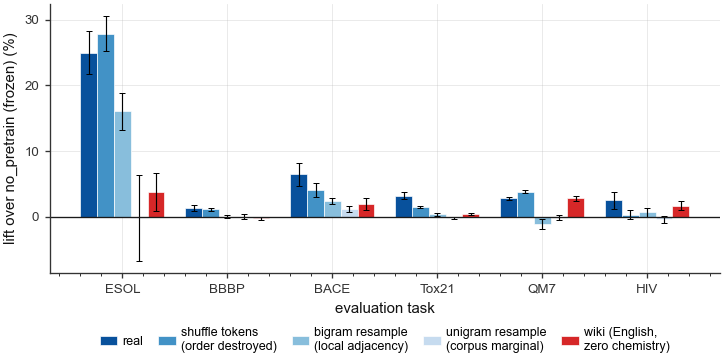


Lift over no_pretrain (frozen) (%):
   arm         ESOL   BBBP   BACE  Tox21    QM7    HIV
   real        25.0    1.3    6.5    3.2    2.9    2.5
   shuffle     27.9    1.1    4.1    1.5    3.9    0.3
   bigram      16.1    0.0    2.4    0.4   -1.1    0.7
   unigram     -0.1    0.1    1.2   -0.2   -0.1   -0.4
   wiki         3.8   -0.2    1.9    0.4    2.8    1.7

Recovery = arm lift / real lift  (% of real's pretraining benefit):
   arm         ESOL   BBBP   BACE  Tox21    QM7    HIV   mean*
   shuffle      112     86     63     47    134     12      89
   bigram        64      3     38     12    -38     26      19
   unigram       -1      4     19     -6     -4    -15       2
   wiki          15    -15     30     14     99     66      40
   * mean over non-saturated tasks (excl. BBBP/HIV, where real lift <1.5% makes the ratio unstable)


In [20]:
# ---------- SI figSA · synthetic-statistics ladder (Exp A) + Wikipedia transfer (Exp B) ----------
_EXPA_CSV="analysis/rigor/expA_ladder_summary.csv"
_EXPB_CSV="analysis/rigor/expB_wiki_summary.csv"
EXPA=pd.read_csv(_EXPA_CSV) if os.path.exists(_EXPA_CSV) else pd.DataFrame(columns=["arm","dataset","metric","mean","std"])
# Fold in Exp B's Wikipedia arm. Exp B reuses the SAME frozen floor and `real`/unsup_8M comparators
# (native _baselines) as Exp A, so lift-over-floor is directly comparable; take only the wiki_real rows.
if os.path.exists(_EXPB_CSV):
    _eb=pd.read_csv(_EXPB_CSV)
    EXPA=pd.concat([EXPA,_eb[_eb.arm=="wiki_real"]],ignore_index=True)
EXPA_FLOOR="no_pretrain (frozen)"                 # random-init frozen probe = the 0-lift reference
# Exp A rungs are a sequential BLUE ramp (most -> least corpus structure preserved). Wikipedia (Exp B --
# English text, zero chemistry, same SMILES tokenizer) is RED and sits on the far right. bigram slots in
# when present; any arm absent from the CSV is dropped.
EXPA_ARMS=[("real (unsup_only)", "real",                                  "#08519c"),
           ("shuffle_tokens",    "shuffle tokens\n(order destroyed)",     "#4292c6"),
           ("bigram_resample",   "bigram resample\n(local adjacency)",    "#88bedc"),
           ("unigram_resample",  "unigram resample\n(corpus marginal)",   "#c6dbef"),
           ("wiki_real",         "wiki (English,\nzero chemistry)",       "#d62728")]
EXPA_ARMS=[a for a in EXPA_ARMS if a[0] in set(EXPA.get("arm",[]))]        # drop arms not yet run
EXPA_TASKS=[t for t in CORE_TASKS if t in set(EXPA.get("dataset",[]))]     # Lipophilicity excluded (not in the paper's task set)

def _expa(arm,task):
    s=EXPA[(EXPA.arm==arm)&(EXPA.dataset==task)]
    return (float(s["mean"].iloc[0]),float(s["std"].iloc[0])) if len(s) else (np.nan,np.nan)
def _expa_lift(arm,task):
    """lift over the frozen no_pretrain floor (%), sign-corrected for metric direction, with the
    seed-sd of both the arm and the floor propagated in quadrature."""
    fm,fs=_expa(EXPA_FLOOR,task); am,as_=_expa(arm,task)
    if not (np.isfinite(fm) and np.isfinite(am) and fm!=0): return (np.nan,np.nan)
    hb=TASKS[task]["higher_better"]
    g=(am/fm-1.0) if hb else (1.0-am/fm)          # + = better than the random-init floor
    err=np.sqrt((as_/fm)**2+(am*fs/fm**2)**2)
    return (100*g,100*err)

if EXPA_TASKS and EXPA_ARMS:
    fig,ax=plt.subplots(figsize=(STYLE["col2"],3.3))
    x=np.arange(len(EXPA_TASKS)); n=len(EXPA_ARMS); w=0.8/n
    for i,(arm,lab,c) in enumerate(EXPA_ARMS):
        ys=[_expa_lift(arm,t)[0] for t in EXPA_TASKS]; es=[_expa_lift(arm,t)[1] for t in EXPA_TASKS]
        ax.bar(x+(i-(n-1)/2)*w,ys,width=w,color=c,edgecolor="white",lw=0.4,
               yerr=es,capsize=1.8,error_kw=dict(lw=0.7),label=lab)
    ax.axhline(0,color=PALETTE["black"],lw=0.8)   # 0 = no_pretrain (frozen)
    ax.set_xticks(x); ax.set_xticklabels([TASKS[t]["pretty"] for t in EXPA_TASKS])
    ax.set_ylabel("lift over no_pretrain (frozen) (%)")
    ax.set_xlabel("evaluation task")
    label_all_yticks(ax)
    ax.legend(loc="upper center",bbox_to_anchor=(0.5,-0.16),ncol=n,fontsize=STYLE["fs_legend"],
              frameon=False,columnspacing=1.2,handletextpad=0.4)
    _suptitle(fig,"Fig SA - where the MLM benefit lives: per-molecule composition (blue) + domain-general transfer (Wikipedia, red)",
              fontsize=STYLE["fs_title"],y=1.02)
    _note=("frozen probe (5-fold scaffold CV, 3 seeds), native units, lift over the random-init frozen "
           "floor (0). BLUE = Exp A structure ladder, each corpus bit-cloned from unsup_8M: shuffle keeps "
           "the per-molecule token multiset but drops order; bigram keeps local adjacency; unigram keeps "
           "only the corpus marginal. shuffle≈real and unigram≈floor => the benefit is per-molecule "
           "composition; bigram is intermediate on tasks with real spread (ESOL/BACE/Tox21). RED = Exp B: "
           "a model pretrained on English Wikipedia (zero chemistry) through the SAME SMILES tokenizer, "
           "length-matched; it beats the floor on most tasks and matches real on QM7 => much of the "
           "benefit is domain-general. Guards: Wikipedia covers 96.9% of eval-token mass >=1x (QM7 lowest "
           "yet transfers fully) and its token marginal is near-maximally divergent (JS=0.93 bits), so "
           "transfer is neither an undertrained-embedding artifact nor the marginal. BBBP/HIV saturate. "
           "HIV = ROC-AUC.")
    _caption(fig,0.5,-0.30,"\n".join(_tw.wrap(_note,120)),ha="center",va="top",
             fontsize=STYLE["fs_annot"],color="#555")
    fig.subplots_adjust(bottom=0.20)
    save_fig(fig,"figSA_synthetic_statistics_ladder"); plt.show()
else:
    print("ExpA ladder: analysis/rigor/expA_ladder_summary.csv not found or empty.")

# quantify the ladder as two tables: lift over the floor, and each arm's recovery of real's benefit
if EXPA_TASKS and EXPA_ARMS:
    _lab={"real (unsup_only)":"real","shuffle_tokens":"shuffle","bigram_resample":"bigram",
          "unigram_resample":"unigram","wiki_real":"wiki"}
    _rl={t:_expa_lift("real (unsup_only)",t)[0] for t in EXPA_TASKS}
    _SAT={"BBBP","HIV"}                        # real lift <1.5% here => the recovery ratio is unstable
    _inf=[t for t in EXPA_TASKS if t not in _SAT]
    _hdr="   "+"arm".ljust(9)+"".join(f"{TASKS[t]['pretty']:>7}" for t in EXPA_TASKS)
    print("\nLift over no_pretrain (frozen) (%):"); print(_hdr)
    for arm,lab,_ in EXPA_ARMS:
        print("   "+_lab[arm].ljust(9)+"".join(f"{_expa_lift(arm,t)[0]:7.1f}" for t in EXPA_TASKS))
    print("\nRecovery = arm lift / real lift  (% of real's pretraining benefit):")
    print(_hdr+"   mean*")
    for arm,lab,_ in EXPA_ARMS:
        if arm=="real (unsup_only)": continue
        rec={t:(_expa_lift(arm,t)[0]/_rl[t]*100 if abs(_rl[t])>1e-9 else np.nan) for t in EXPA_TASKS}
        print("   "+_lab[arm].ljust(9)+"".join(f"{rec[t]:7.0f}" for t in EXPA_TASKS)
              +f"   {np.nanmean([rec[t] for t in _inf]):5.0f}")
    print("   * mean over non-saturated tasks (excl. BBBP/HIV, where real lift <1.5% makes the ratio unstable)")
